# 01 – Plasma Lithium (Litemia) vs. CSF Protein Change

Pearson correlations between plasma lithium change and all CSF protein change scores. Generates bubble plots.

**Input:** `data/input/Lithemia_Lithium_forPearson.xlsx`, `data/input/Separated_Lithium/Placebo_Group_Visit_Differences.csv`

**Corresponds to:** Figure 1B–1I, Supplementary Table 2

---

> **Running locally:** All paths are relative to the `notebooks/` folder.
> Input data files go in `data/input/`, outputs are written to `data/output/`.

In [2]:

# Google Drive 마운트


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import pandas as pd

In [3]:
import pandas as pd

# 파일 경로 설정
file_path = '../data/input/Lithemia_Lithium_forPearson.xlsx'

# 엑셀 파일 로드
df = pd.read_excel(file_path)

# 데이터 확인
print(df.head())

   Patient ID  NPTX2_ELISA_diff_visit_0_vs_1  NPTXR_ELISA_diff_visit_0_vs_1  \
0        1013                      -0.405680                      -0.565152   
1        1021                      -0.178194                      -1.068350   
2        1036                      -0.181694                      -0.022009   
3        1041                       0.083613                       0.167062   
4        1105                      -0.273435                      -0.286011   

   NPTX2/NPTXR_ELISA_diff_visit_0_vs_1  Ab_ELISA_diff_visit_0_vs_1  \
0                             0.011892                   -0.333883   
1                             0.086914                   -0.541077   
2                            -0.013740                   -0.046160   
3                            -0.005715                   -0.146260   
4                             0.001551                   -0.315854   

   Tau_ELISA_diff_visit_0_vs_1  pTau_ELISA_diff_visit_0_vs_1  \
0                    -0.558837          

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr


In [8]:
# 'Patient ID' 칼럼 분리
patient_ids = df['Patient ID']
df = df.drop(columns=['Patient ID'])

KeyError: 'Patient ID'

상관관계 결과가 /content/drive/MyDrive/Litemia_Correlation_Results.xlsx에 저장되었습니다.
시각화 결과가 /content/drive/MyDrive/Litemia_Correlation_Bubble_Heatmap.pdf에 저장되었습니다.


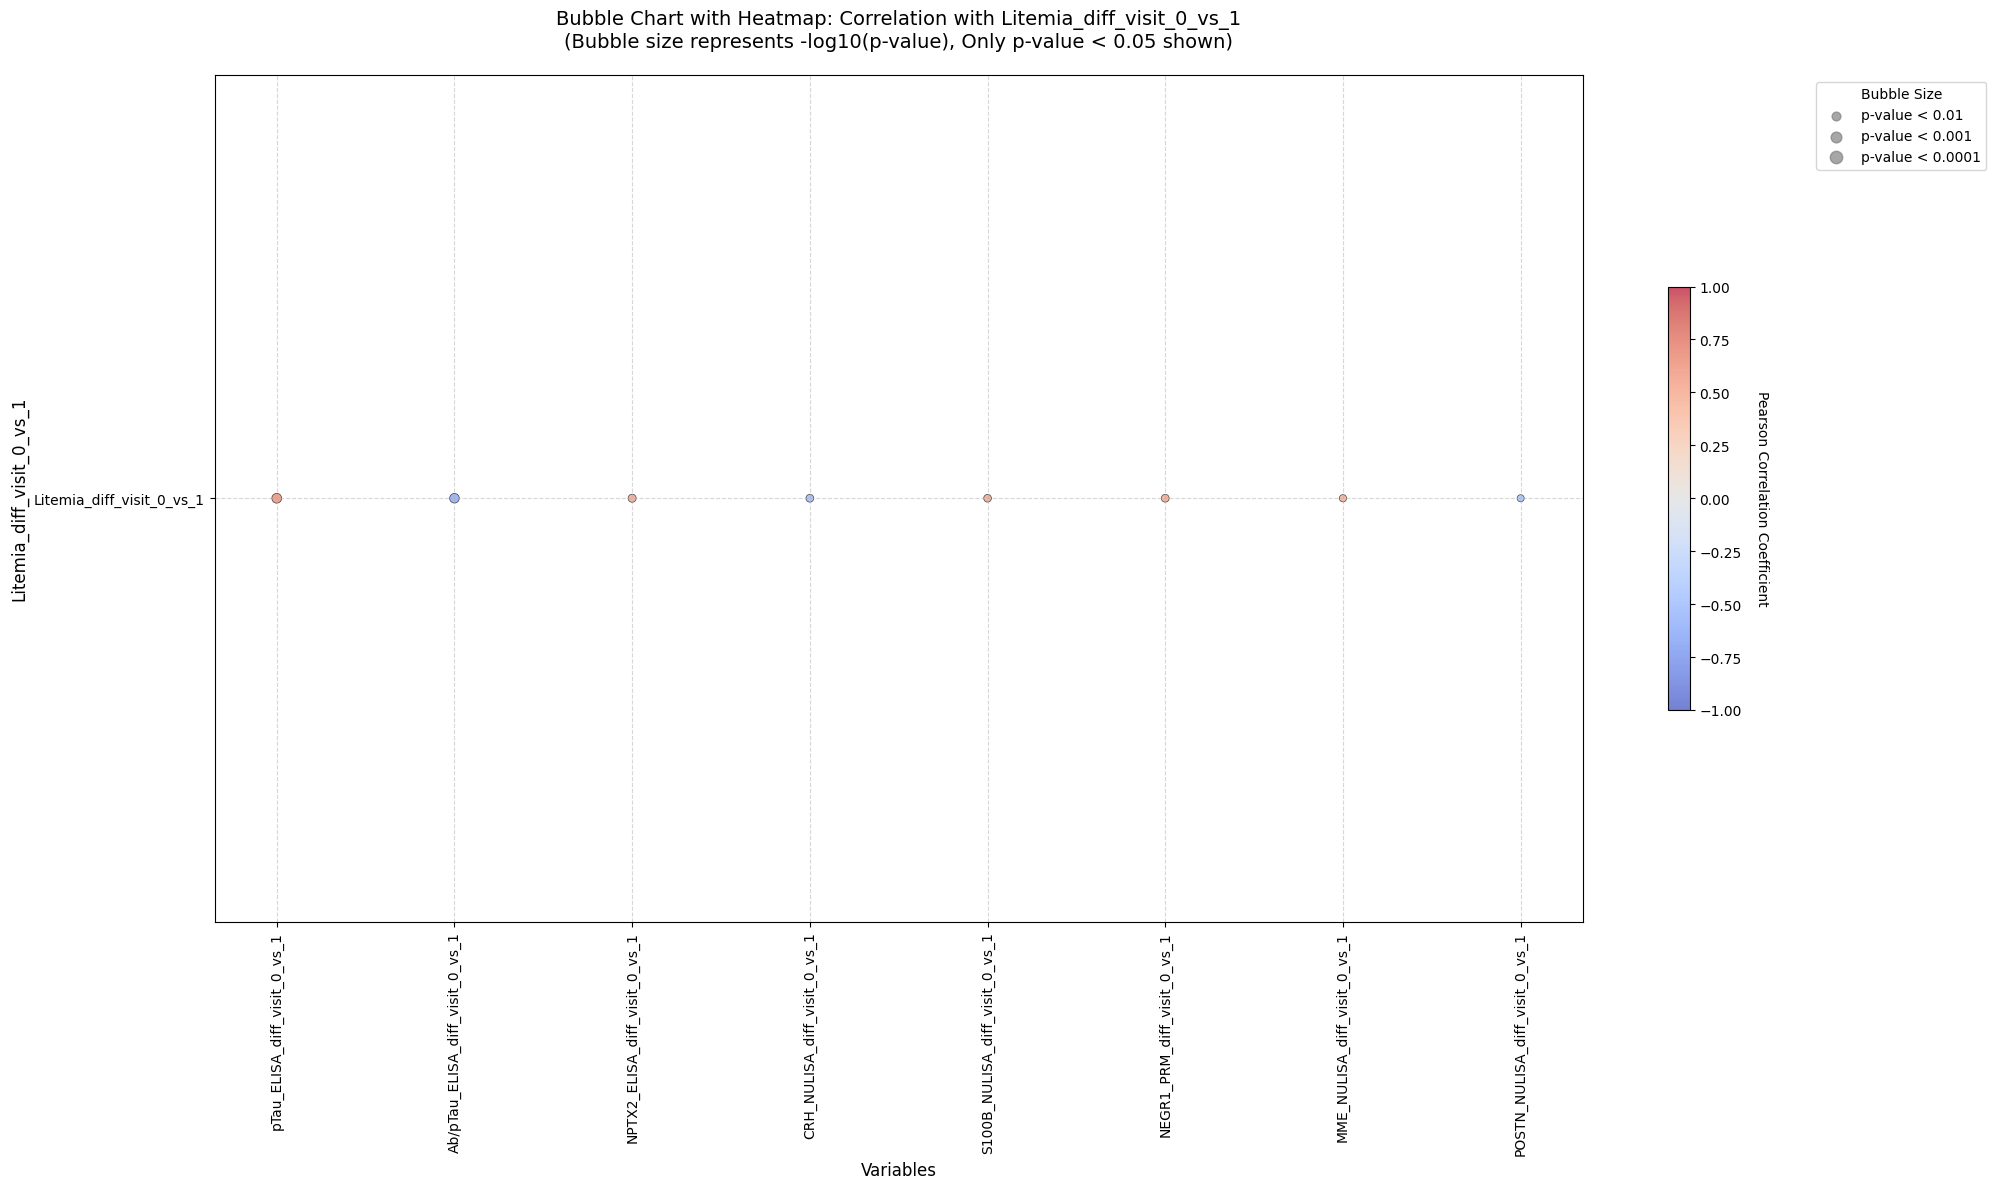


Top 20 Significant Correlations:
                            Variable  Correlation   P-value
5       pTau_ELISA_diff_visit_0_vs_1     0.639727  0.003181
6    Ab/pTau_ELISA_diff_visit_0_vs_1    -0.630418  0.003809
0      NPTX2_ELISA_diff_visit_0_vs_1     0.527873  0.020179
29      CRH_NULISA_diff_visit_0_vs_1    -0.522085  0.026250
93    S100B_NULISA_diff_visit_0_vs_1     0.516517  0.028189
123      NEGR1_PRM_diff_visit_0_vs_1     0.511491  0.025193
70      MME_NULISA_diff_visit_0_vs_1     0.483455  0.042093
86    POSTN_NULISA_diff_visit_0_vs_1    -0.469416  0.049370


In [11]:
# 'Litemia_diff_visit_0_vs_1'과 다른 모든 칼럼 간의 상관관계 계산
target_col = 'Litemia_diff_visit_0_vs_1'
other_cols = [col for col in df.columns if col != target_col]

corr_results = []
for col in other_cols:
    # 결측값 제거
    valid_idx = df[[target_col, col]].notna().all(axis=1)
    if sum(valid_idx) > 2:  # 최소 3개의 유효한 데이터 포인트 필요
        r, p = pearsonr(df.loc[valid_idx, target_col], df.loc[valid_idx, col])
        corr_results.append({
            'Variable': col,
            'Correlation': r,
            'P-value': p,
            'Absolute_Correlation': abs(r)
        })

# 결과를 DataFrame으로 변환
corr_df = pd.DataFrame(corr_results)

# 결과를 엑셀 파일로 저장
output_excel_path = '../data/output/Litemia_Correlation_Results.xlsx'
corr_df.to_excel(output_excel_path, index=False)
print(f"상관관계 결과가 {output_excel_path}에 저장되었습니다.")

# 시각화를 위한 데이터 준비
plot_df = corr_df.copy()
plot_df['-log10(p-value)'] = -np.log10(plot_df['P-value'])
plot_df['Bubble_Size'] = plot_df['-log10(p-value)'] * 20  # 버블 크기 조정

# 유의미한 결과만 필터링 (p-value < 0.05)
significant_df = plot_df[plot_df['P-value'] < 0.05].sort_values('Absolute_Correlation', ascending=False)

# 그래프 스타일 설정 (seaborn 스타일 대신 matplotlib 기본 스타일 사용)
plt.style.use('default')
plt.rcParams['figure.figsize'] = (20, 12)
plt.rcParams['font.size'] = 10

# 그림 생성
fig, ax = plt.subplots()

# 히트맵 색상 (상관계수 값)
heatmap = ax.scatter(
    x=significant_df['Variable'],
    y=[target_col]*len(significant_df),
    c=significant_df['Correlation'],
    s=significant_df['Bubble_Size'],
    cmap='coolwarm',
    vmin=-1,
    vmax=1,
    alpha=0.7,
    edgecolors='black',
    linewidth=0.5
)

# 컬러바 추가
cbar = plt.colorbar(heatmap, ax=ax, shrink=0.5)
cbar.set_label('Pearson Correlation Coefficient', rotation=270, labelpad=20)

# 축 레이블 및 제목
ax.set_xlabel('Variables', fontsize=12)
ax.set_ylabel(target_col, fontsize=12)
ax.set_title(f'Bubble Chart with Heatmap: Correlation with {target_col}\n(Bubble size represents -log10(p-value), Only p-value < 0.05 shown)',
             fontsize=14, pad=20)

# x축 레이블 회전
plt.xticks(rotation=90)

# 그리드 추가
ax.grid(True, linestyle='--', alpha=0.5)

# 범례 추가 (버블 크기 설명)
for pvalue, size in zip([0.01, 0.001, 0.0001], [30, 60, 90]):
    plt.scatter([], [], s=-np.log10(pvalue)*20, c='gray', alpha=0.7,
                label=f'p-value < {pvalue}')
plt.legend(title='Bubble Size', loc='upper right', bbox_to_anchor=(1.3, 1))

# 레이아웃 조정
plt.tight_layout()

# PDF로 저장
output_pdf_path = '../data/output/Litemia_Correlation_Bubble_Heatmap.pdf'
plt.savefig(output_pdf_path, bbox_inches='tight', dpi=300)
print(f"시각화 결과가 {output_pdf_path}에 저장되었습니다.")

plt.show()

# 상위 20개 유의미한 상관관계 결과 출력
print("\nTop 20 Significant Correlations:")
print(significant_df[['Variable', 'Correlation', 'P-value']].head(20))

In [ ]:
# ELISA 데이터만 분리
elisa_columns = [col for col in df.columns if '_ELISA' in col]
elisa_df = df[elisa_columns]

# 데이터 확인
print(elisa_df.head())

   NPTX2_ELISA  NPTXR_ELISA  NPTX2/NPTXR_ELISA  Ab_ELISA  Tau_ELISA  \
0      2346.01       30.323           0.077367   283.730    130.495   
1      1217.76       19.505           0.062433   635.980     92.930   
2      1169.19       18.737           0.062400   284.910    158.475   
3       969.06       15.700           0.061724   362.015     40.225   
4      1560.14       22.251           0.070116   748.505     86.355   

   pTau_ELISA  Ab/pTau_ELISA  
0      85.860       3.304566  
1      44.450      14.307762  
2     121.950       2.336285  
3      32.540      11.125230  
4      50.105      14.938729  


In [ ]:
# 결측값 확인
print(elisa_df.isnull().sum())

# 결측값 제거 (또는 대체)
elisa_df_cleaned = elisa_df.dropna()  # 결측값이 있는 행 제거

# 결측값 제거 후 데이터 확인
print(elisa_df_cleaned.head())

NPTX2_ELISA           3
NPTXR_ELISA           3
NPTX2/NPTXR_ELISA     3
Ab_ELISA             19
Tau_ELISA            19
pTau_ELISA           19
Ab/pTau_ELISA        19
dtype: int64
   NPTX2_ELISA  NPTXR_ELISA  NPTX2/NPTXR_ELISA  Ab_ELISA  Tau_ELISA  \
0      2346.01       30.323           0.077367   283.730    130.495   
1      1217.76       19.505           0.062433   635.980     92.930   
2      1169.19       18.737           0.062400   284.910    158.475   
3       969.06       15.700           0.061724   362.015     40.225   
4      1560.14       22.251           0.070116   748.505     86.355   

   pTau_ELISA  Ab/pTau_ELISA  
0      85.860       3.304566  
1      44.450      14.307762  
2     121.950       2.336285  
3      32.540      11.125230  
4      50.105      14.938729  


In [ ]:
from scipy.stats import pearsonr
import numpy as np

# 상관관계 및 p-value 계산 함수
def calculate_correlation(df):
    corr_matrix = df.corr(method='pearson')
    p_matrix = np.zeros_like(corr_matrix)
    for i in range(len(df.columns)):
        for j in range(len(df.columns)):
            if i != j:
                _, p_matrix[i, j] = pearsonr(df.iloc[:, i], df.iloc[:, j])
    return corr_matrix, p_matrix

# ELISA 데이터에 대해 상관관계 및 p-value 계산
elisa_corr, elisa_p = calculate_correlation(elisa_df_cleaned)

# 결과 확인
print("ELISA 상관관계 행렬:")
print(elisa_corr)
print("\nELISA p-value 행렬:")
print(elisa_p)

ELISA 상관관계 행렬:
                   NPTX2_ELISA  NPTXR_ELISA  NPTX2/NPTXR_ELISA  Ab_ELISA  \
NPTX2_ELISA           1.000000     0.818030           0.418011 -0.138945   
NPTXR_ELISA           0.818030     1.000000          -0.139662 -0.189624   
NPTX2/NPTXR_ELISA     0.418011    -0.139662           1.000000 -0.001559   
Ab_ELISA             -0.138945    -0.189624          -0.001559  1.000000   
Tau_ELISA             0.416288     0.424242          -0.001676 -0.314873   
pTau_ELISA            0.358136     0.437984          -0.059965 -0.460467   
Ab/pTau_ELISA        -0.313785    -0.355345          -0.013712  0.549368   

                   Tau_ELISA  pTau_ELISA  Ab/pTau_ELISA  
NPTX2_ELISA         0.416288    0.358136      -0.313785  
NPTXR_ELISA         0.424242    0.437984      -0.355345  
NPTX2/NPTXR_ELISA  -0.001676   -0.059965      -0.013712  
Ab_ELISA           -0.314873   -0.460467       0.549368  
Tau_ELISA           1.000000    0.778449      -0.573767  
pTau_ELISA          0.778449

Overall Correlation and p-value Table:
           Variable 1         Variable 2  Correlation       P-value
0         NPTX2_ELISA        NPTX2_ELISA     1.000000  0.000000e+00
1         NPTX2_ELISA        NPTXR_ELISA     0.818030  7.022230e-22
2         NPTX2_ELISA  NPTX2/NPTXR_ELISA     0.418011  6.208743e-05
3         NPTX2_ELISA           Ab_ELISA    -0.138945  2.020012e-01
4         NPTX2_ELISA          Tau_ELISA     0.416288  6.704243e-05
5         NPTX2_ELISA         pTau_ELISA     0.358136  7.100762e-04
6         NPTX2_ELISA      Ab/pTau_ELISA    -0.313785  3.260625e-03
7         NPTXR_ELISA        NPTX2_ELISA     0.818030  7.022230e-22
8         NPTXR_ELISA        NPTXR_ELISA     1.000000  0.000000e+00
9         NPTXR_ELISA  NPTX2/NPTXR_ELISA    -0.139662  1.996609e-01
10        NPTXR_ELISA           Ab_ELISA    -0.189624  8.034844e-02
11        NPTXR_ELISA          Tau_ELISA     0.424242  4.687017e-05
12        NPTXR_ELISA         pTau_ELISA     0.437984  2.471575e-05
13       

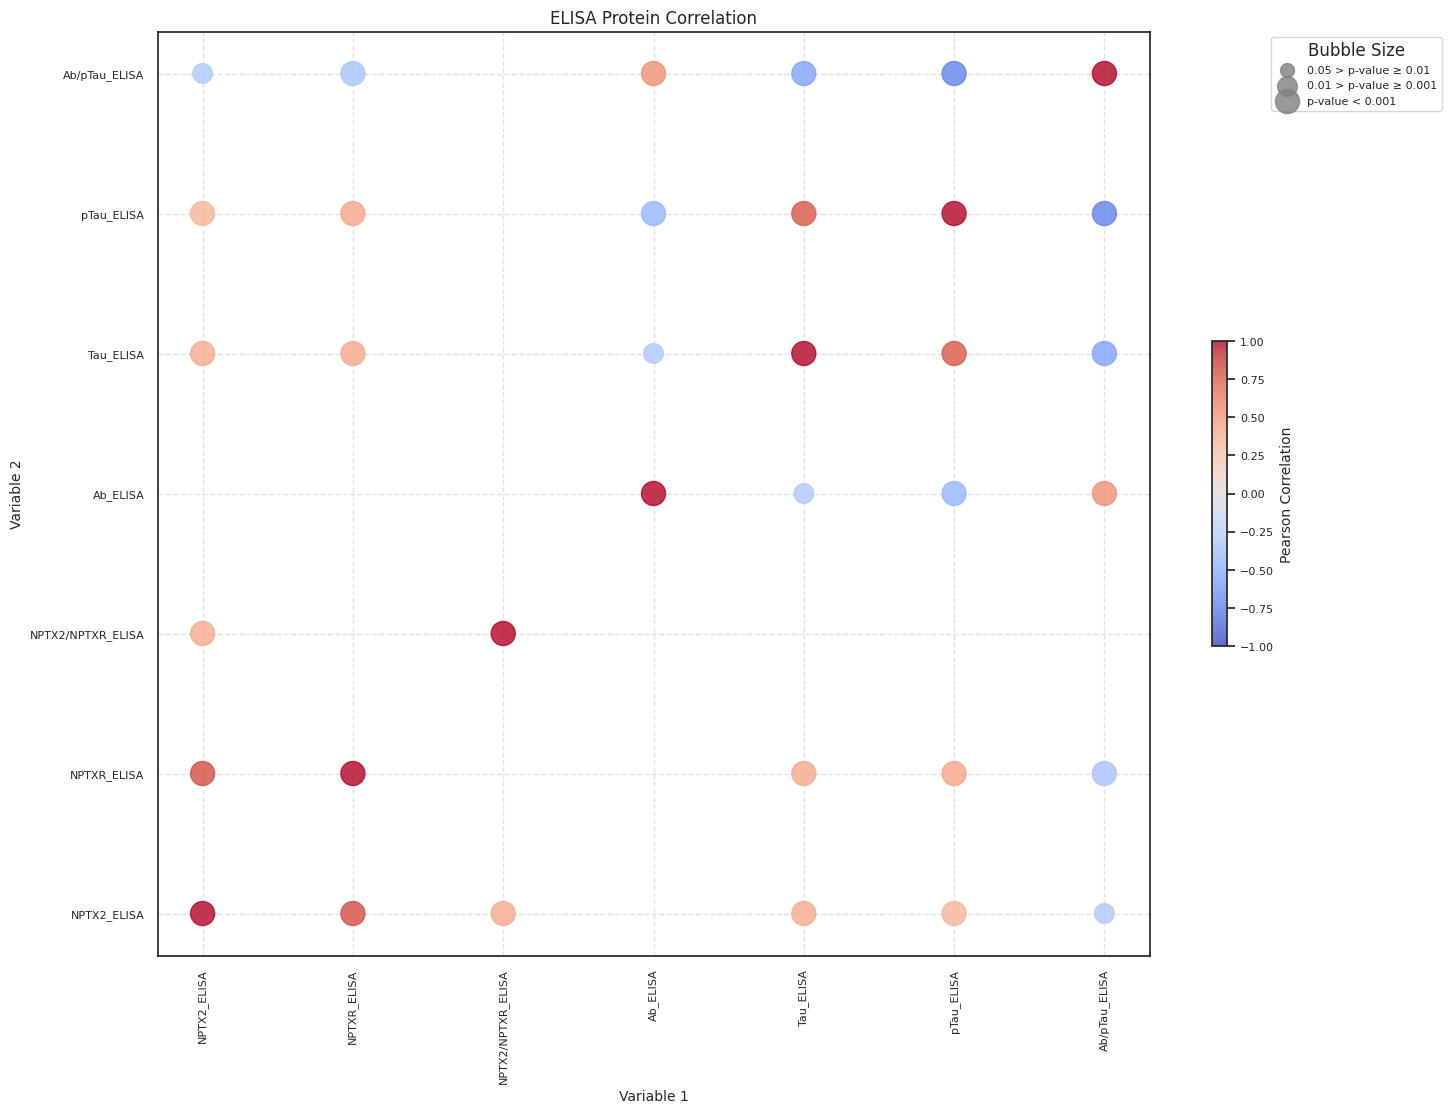

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 시각화 함수 정의
def plot_bubble_correlation(corr_matrix, pvalue_matrix, title):
    # 상관계수와 p-value를 하나의 데이터프레임으로 병합
    corr_df = corr_matrix.stack().reset_index()
    corr_df.columns = ['Variable 1', 'Variable 2', 'Correlation']

    pvalue_df = pd.DataFrame(pvalue_matrix, index=corr_matrix.index, columns=corr_matrix.columns)  # p-value 행렬을 DataFrame으로 변환
    pvalue_df = pvalue_df.stack().reset_index()
    pvalue_df.columns = ['Variable 1', 'Variable 2', 'P-value']

    merged_df = pd.merge(corr_df, pvalue_df, on=['Variable 1', 'Variable 2'])

    # p-value에 따라 원의 크기 설정 (3단계로 나눔)
    def get_bubble_size(p_value):
        if p_value < 0.001:
            return 300  # 가장 큰 원
        elif 0.001 <= p_value < 0.01:
            return 200  # 중간 원
        elif 0.01 <= p_value < 0.05:
            return 100  # 가장 작은 원
        else:
            return 0  # 0.05 이상인 경우 표시하지 않음

    # 원의 크기 계산
    merged_df['Bubble Size'] = merged_df['P-value'].apply(get_bubble_size)

    # 그림 크기 설정
    plt.figure(figsize=(16, 12))  # 그림 크기를 16x12로 늘림

    # 폰트 설정 (Arial과 비슷한 sans-serif 폰트 사용)
    plt.rcParams['font.family'] = 'sans-serif'
    plt.rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans', 'Helvetica', 'Lucida Grande', 'Verdana']
    plt.rcParams['font.size'] = 10  # 기본 폰트 크기 줄임
    plt.rcParams['axes.titlesize'] = 12  # 제목 폰트 크기 줄임
    plt.rcParams['axes.labelsize'] = 10  # 축 레이블 폰트 크기 줄임
    plt.rcParams['xtick.labelsize'] = 8  # x축 틱 폰트 크기 줄임
    plt.rcParams['ytick.labelsize'] = 8  # y축 틱 폰트 크기 줄임

    # Bubble Chart 그리기
    scatter = plt.scatter(
        x=merged_df['Variable 1'],  # x 좌표 (변수 1)
        y=merged_df['Variable 2'],  # y 좌표 (변수 2)
        s=merged_df['Bubble Size'],  # 원의 크기 (p-value에 따라 3단계로 설정)
        c=merged_df['Correlation'],  # 원의 색상 (상관계수)
        cmap='coolwarm',  # 색상 맵: -1(파란색) ~ 1(빨간색)
        vmin=-1,
        vmax=1,
        alpha=0.8  # 투명도
    )

    # 색상 바 추가 (크기 축소)
    cbar = plt.colorbar(scatter, shrink=0.33)  # 크기 축소
    cbar.set_label('Pearson Correlation', fontsize=10)  # 색상바 레이블 폰트 크기 줄임

    # 축 레이블 및 제목 설정
    plt.xlabel('Variable 1', fontsize=10)
    plt.ylabel('Variable 2', fontsize=10)
    plt.title(title, fontsize=12)

    # x축과 y축의 라벨 회전
    plt.xticks(rotation=90)
    plt.yticks(rotation=0)

    # 그리드 추가
    plt.grid(True, linestyle='--', alpha=0.6)

    # 범례 추가 (원의 크기 설명)
    for pvalue_range, size in zip(
        ['0.05 > p-value ≥ 0.01', '0.01 > p-value ≥ 0.001', 'p-value < 0.001'],  # 범례 설명 수정
        [100, 200, 300]  # 원의 크기
    ):
        plt.scatter([], [], s=size, c='gray', alpha=0.8, label=pvalue_range)  # 범례 설명 적용
    plt.legend(title='Bubble Size', loc='upper right', bbox_to_anchor=(1.3, 1), fontsize=8)  # 범례 폰트 크기 줄임

    # Pearson 상관계수와 p-value 테이블 출력
    print(f"Overall Correlation and p-value Table:")
    print(merged_df[['Variable 1', 'Variable 2', 'Correlation', 'P-value']].dropna(), "\n")

    # Excel로 테이블 저장
    merged_df[['Variable 1', 'Variable 2', 'Correlation', 'P-value']].dropna().to_excel(
        f"../data/output/{title}_correlation_table.xlsx", index=False)

    # PDF로 저장
    plt.savefig(f'{title}_bubble_chart.pdf', format='pdf', bbox_inches='tight')
    plt.show()

# ELISA 데이터 시각화
plot_bubble_correlation(elisa_corr, elisa_p, title='ELISA Protein Correlation')

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# NULISA 데이터만 분리
nulisa_columns = [col for col in df.columns if '_NULISA' in col]
nulisa_df = df[nulisa_columns]

# 결측값 제거
nulisa_df_cleaned = nulisa_df.dropna()

# 상관관계 및 p-value 계산 함수
def calculate_correlation(df):
    corr_matrix = df.corr(method='pearson')
    p_matrix = np.zeros_like(corr_matrix)
    for i in range(len(df.columns)):
        for j in range(len(df.columns)):
            if i != j:
                _, p_matrix[i, j] = pearsonr(df.iloc[:, i], df.iloc[:, j])
    return corr_matrix, p_matrix

# NULISA 데이터에 대해 상관관계 및 p-value 계산
nulisa_corr, nulisa_p = calculate_correlation(nulisa_df_cleaned)

# 시각화 함수 정의
def plot_bubble_correlation(corr_matrix, pvalue_matrix, title):
    # 상관계수와 p-value를 하나의 데이터프레임으로 병합
    corr_df = corr_matrix.stack().reset_index()
    corr_df.columns = ['Variable 1', 'Variable 2', 'Correlation']

    pvalue_df = pd.DataFrame(pvalue_matrix, index=corr_matrix.index, columns=corr_matrix.columns)  # p-value 행렬을 DataFrame으로 변환
    pvalue_df = pvalue_df.stack().reset_index()
    pvalue_df.columns = ['Variable 1', 'Variable 2', 'P-value']

    merged_df = pd.merge(corr_df, pvalue_df, on=['Variable 1', 'Variable 2'])

    # p-value에 따라 원의 크기 설정 (3단계로 나눔)
    def get_bubble_size(p_value):
        if p_value < 0.001:
            return 80  # 가장 큰 원
        elif 0.001 <= p_value < 0.01:
            return 40  # 중간 원
        elif 0.01 <= p_value < 0.05:
            return 20  # 가장 작은 원
        else:
            return 0  # 0.05 이상인 경우 표시하지 않음

    # 원의 크기 계산
    merged_df['Bubble Size'] = merged_df['P-value'].apply(get_bubble_size)

    # 그림 크기 설정 (크게 조정)
    plt.figure(figsize=(24, 18))  # 그림 크기를 24x18로 늘림

    # 폰트 설정 (Arial과 비슷한 sans-serif 폰트 사용)
    plt.rcParams['font.family'] = 'sans-serif'
    plt.rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans', 'Helvetica', 'Lucida Grande', 'Verdana']
    plt.rcParams['font.size'] = 10  # 기본 폰트 크기 줄임
    plt.rcParams['axes.titlesize'] = 12  # 제목 폰트 크기 줄임
    plt.rcParams['axes.labelsize'] = 10  # 축 레이블 폰트 크기 줄임
    plt.rcParams['xtick.labelsize'] = 8  # x축 틱 폰트 크기 줄임
    plt.rcParams['ytick.labelsize'] = 8  # y축 틱 폰트 크기 줄임

    # Bubble Chart 그리기
    scatter = plt.scatter(
        x=merged_df['Variable 1'],  # x 좌표 (변수 1)
        y=merged_df['Variable 2'],  # y 좌표 (변수 2)
        s=merged_df['Bubble Size'],  # 원의 크기 (p-value에 따라 3단계로 설정)
        c=merged_df['Correlation'],  # 원의 색상 (상관계수)
        cmap='coolwarm',  # 색상 맵: -1(파란색) ~ 1(빨간색)
        vmin=-1,
        vmax=1,
        alpha=0.8  # 투명도
    )

    # 색상 바 추가 (크기 축소)
    cbar = plt.colorbar(scatter, shrink=0.33)  # 크기 축소
    cbar.set_label('Pearson Correlation', fontsize=10)  # 색상바 레이블 폰트 크기 줄임

    # 축 레이블 및 제목 설정
    plt.xlabel('Variable 1', fontsize=10)
    plt.ylabel('Variable 2', fontsize=10)
    plt.title(title, fontsize=12)

    # x축과 y축의 라벨 회전
    plt.xticks(rotation=90)
    plt.yticks(rotation=0)

    # 그리드 추가
    plt.grid(True, linestyle='--', alpha=0.6)

    # 범례 추가 (원의 크기 설명)
    for pvalue_range, size in zip(
        ['0.05 > p-value ≥ 0.01', '0.01 > p-value ≥ 0.001', 'p-value < 0.001'],  # 범례 설명 수정
        [20, 40, 80]  # 원의 크기
    ):
        plt.scatter([], [], s=size, c='gray', alpha=0.8, label=pvalue_range)  # 범례 설명 적용
    plt.legend(title='Bubble Size', loc='upper right', bbox_to_anchor=(1.3, 1), fontsize=8)  # 범례 폰트 크기 줄임

    # Pearson 상관계수와 p-value 테이블 출력
    print(f"Overall Correlation and p-value Table:")
    print(merged_df[['Variable 1', 'Variable 2', 'Correlation', 'P-value']].dropna(), "\n")

    # Excel로 테이블 저장
    merged_df[['Variable 1', 'Variable 2', 'Correlation', 'P-value']].dropna().to_excel(
        f"../data/output/{title}_correlation_table.xlsx", index=False)

    # PDF로 저장
    plt.savefig(f'{title}_bubble_chart.pdf', format='pdf', bbox_inches='tight')
    plt.show()

# NULISA 데이터 시각화
plot_bubble_correlation(nulisa_corr, nulisa_p, title='NULISA Protein Correlation')

Output hidden; open in https://colab.research.google.com to view.

Overall Correlation and p-value Table:
      Variable 1     Variable 2  Correlation       P-value
0    GFRA3_PRM      GFRA3_PRM       1.000000  0.000000e+00
1    GFRA3_PRM       GPC1_PRM       0.537785  3.302235e-09
2    GFRA3_PRM      NEGR1_PRM       0.450958  1.381333e-06
3    GFRA3_PRM    RTN4RL2_PRM       0.311858  1.201571e-03
4    GFRA3_PRM      GRIA4_PRM       0.483465  1.749317e-07
..           ...            ...          ...           ...
319  TREM2_PRM      SCRN1_PRM       0.342441  3.492673e-04
320  TREM2_PRM       C1QA_PRM       0.616445  2.547270e-12
321  TREM2_PRM      CNTFR_PRM       0.661615  1.551192e-14
322  TREM2_PRM        VGF_PRM       0.444369  2.047397e-06
323  TREM2_PRM      TREM2_PRM       1.000000  0.000000e+00

[324 rows x 4 columns] 



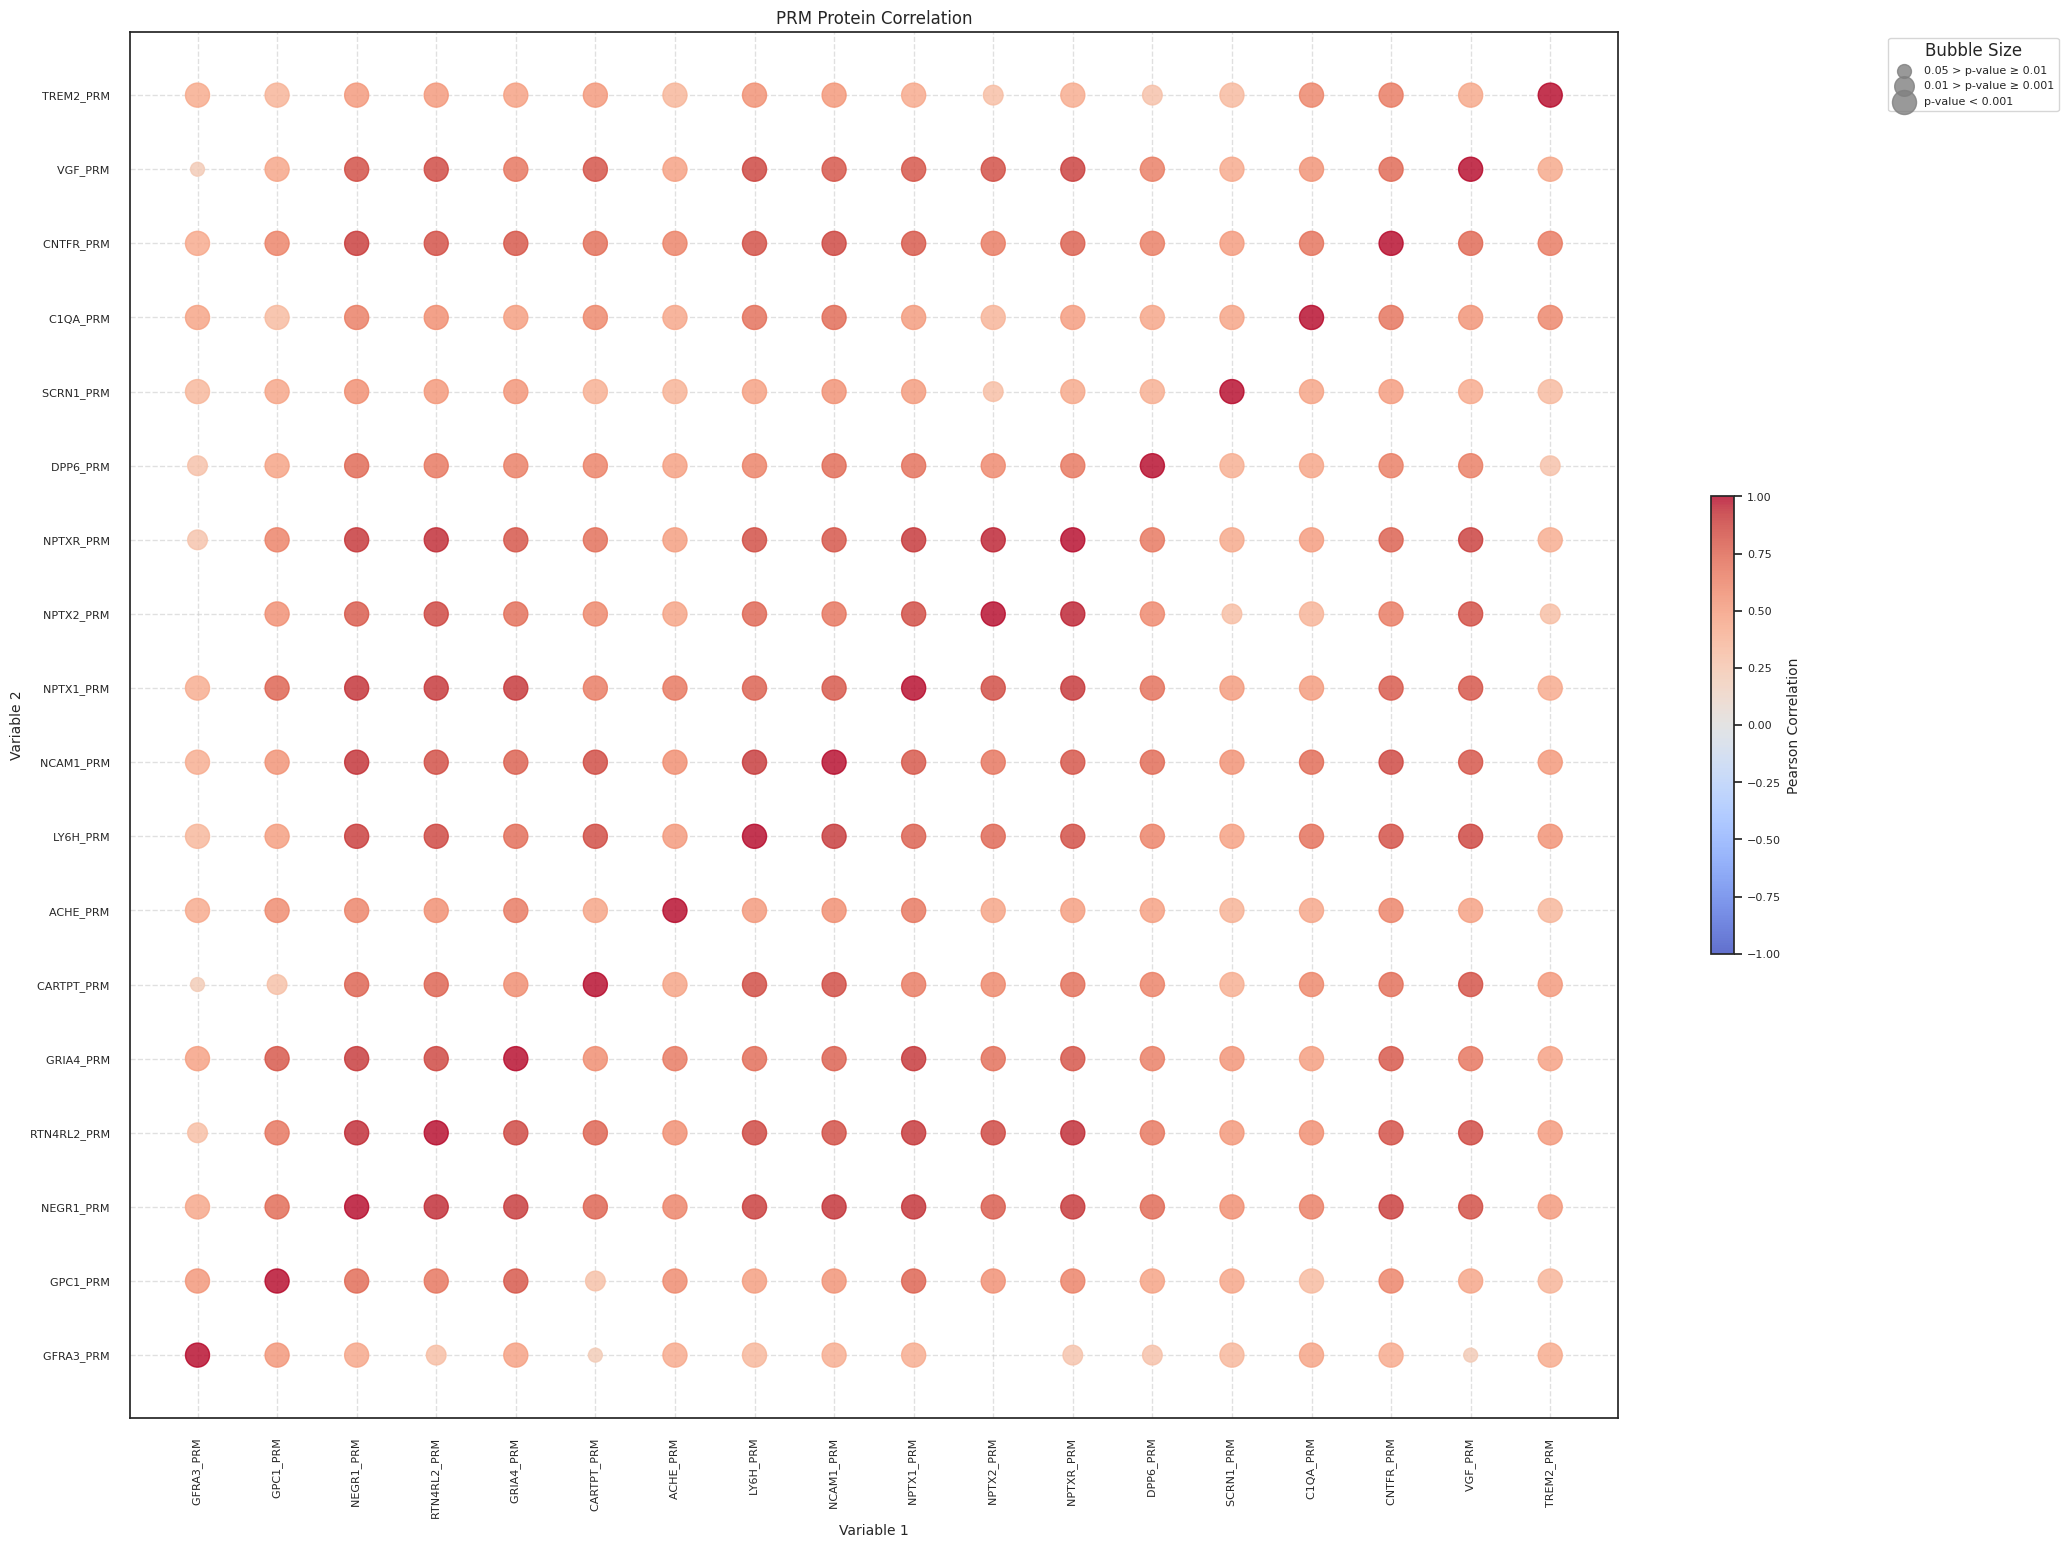

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# PRM 데이터만 분리
prm_columns = [col for col in df.columns if '_PRM' in col]
prm_df = df[prm_columns]

# 결측값 제거
prm_df_cleaned = prm_df.dropna()

# 상관관계 및 p-value 계산 함수
def calculate_correlation(df):
    corr_matrix = df.corr(method='pearson')
    p_matrix = np.zeros_like(corr_matrix)
    for i in range(len(df.columns)):
        for j in range(len(df.columns)):
            if i != j:
                _, p_matrix[i, j] = pearsonr(df.iloc[:, i], df.iloc[:, j])
    return corr_matrix, p_matrix

# PRM 데이터에 대해 상관관계 및 p-value 계산
prm_corr, prm_p = calculate_correlation(prm_df_cleaned)

# 시각화 함수 정의
def plot_bubble_correlation(corr_matrix, pvalue_matrix, title):
    # 상관계수와 p-value를 하나의 데이터프레임으로 병합
    corr_df = corr_matrix.stack().reset_index()
    corr_df.columns = ['Variable 1', 'Variable 2', 'Correlation']

    pvalue_df = pd.DataFrame(pvalue_matrix, index=corr_matrix.index, columns=corr_matrix.columns)  # p-value 행렬을 DataFrame으로 변환
    pvalue_df = pvalue_df.stack().reset_index()
    pvalue_df.columns = ['Variable 1', 'Variable 2', 'P-value']

    merged_df = pd.merge(corr_df, pvalue_df, on=['Variable 1', 'Variable 2'])

    # p-value에 따라 원의 크기 설정 (3단계로 나눔)
    def get_bubble_size(p_value):
        if p_value < 0.001:
            return 300  # 가장 큰 원
        elif 0.001 <= p_value < 0.01:
            return 200  # 중간 원
        elif 0.01 <= p_value < 0.05:
            return 100  # 가장 작은 원
        else:
            return 0  # 0.05 이상인 경우 표시하지 않음

    # 원의 크기 계산
    merged_df['Bubble Size'] = merged_df['P-value'].apply(get_bubble_size)

    # 그림 크기 설정 (크게 조정)
    plt.figure(figsize=(24, 18))  # 그림 크기를 24x18로 늘림

    # 폰트 설정 (Arial과 비슷한 sans-serif 폰트 사용)
    plt.rcParams['font.family'] = 'sans-serif'
    plt.rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans', 'Helvetica', 'Lucida Grande', 'Verdana']
    plt.rcParams['font.size'] = 10  # 기본 폰트 크기 줄임
    plt.rcParams['axes.titlesize'] = 12  # 제목 폰트 크기 줄임
    plt.rcParams['axes.labelsize'] = 10  # 축 레이블 폰트 크기 줄임
    plt.rcParams['xtick.labelsize'] = 8  # x축 틱 폰트 크기 줄임
    plt.rcParams['ytick.labelsize'] = 8  # y축 틱 폰트 크기 줄임

    # Bubble Chart 그리기
    scatter = plt.scatter(
        x=merged_df['Variable 1'],  # x 좌표 (변수 1)
        y=merged_df['Variable 2'],  # y 좌표 (변수 2)
        s=merged_df['Bubble Size'],  # 원의 크기 (p-value에 따라 3단계로 설정)
        c=merged_df['Correlation'],  # 원의 색상 (상관계수)
        cmap='coolwarm',  # 색상 맵: -1(파란색) ~ 1(빨간색)
        vmin=-1,
        vmax=1,
        alpha=0.8  # 투명도
    )

    # 색상 바 추가 (크기 축소)
    cbar = plt.colorbar(scatter, shrink=0.33)  # 크기 축소
    cbar.set_label('Pearson Correlation', fontsize=10)  # 색상바 레이블 폰트 크기 줄임

    # 축 레이블 및 제목 설정
    plt.xlabel('Variable 1', fontsize=10)
    plt.ylabel('Variable 2', fontsize=10)
    plt.title(title, fontsize=12)

    # x축과 y축의 라벨 회전
    plt.xticks(rotation=90)
    plt.yticks(rotation=0)

    # 그리드 추가
    plt.grid(True, linestyle='--', alpha=0.6)

    # 범례 추가 (원의 크기 설명)
    for pvalue_range, size in zip(
        ['0.05 > p-value ≥ 0.01', '0.01 > p-value ≥ 0.001', 'p-value < 0.001'],  # 범례 설명 수정
        [100, 200, 300]  # 원의 크기
    ):
        plt.scatter([], [], s=size, c='gray', alpha=0.8, label=pvalue_range)  # 범례 설명 적용
    plt.legend(title='Bubble Size', loc='upper right', bbox_to_anchor=(1.3, 1), fontsize=8)  # 범례 폰트 크기 줄임

    # Pearson 상관계수와 p-value 테이블 출력
    print(f"Overall Correlation and p-value Table:")
    print(merged_df[['Variable 1', 'Variable 2', 'Correlation', 'P-value']].dropna(), "\n")

    # Excel로 테이블 저장
    merged_df[['Variable 1', 'Variable 2', 'Correlation', 'P-value']].dropna().to_excel(
        f"../data/output/{title}_correlation_table.xlsx", index=False)

    # PDF로 저장
    plt.savefig(f'{title}_bubble_chart.pdf', format='pdf', bbox_inches='tight')
    plt.show()

# PRM 데이터 시각화
plot_bubble_correlation(prm_corr, prm_p, title='PRM Protein Correlation')

Overall Correlation and p-value Table:
           Variable 1         Variable 2  Correlation       P-value
0         NPTX2_ELISA        NPTX2_ELISA     1.000000  0.000000e+00
1         NPTX2_ELISA        NPTXR_ELISA     0.785453  3.827083e-11
2         NPTX2_ELISA  NPTX2/NPTXR_ELISA     0.456507  1.108979e-03
3         NPTX2_ELISA           Ab_ELISA    -0.235833  1.065964e-01
4         NPTX2_ELISA          Tau_ELISA     0.469795  7.546697e-04
5         NPTX2_ELISA         pTau_ELISA     0.428693  2.365378e-03
6         NPTX2_ELISA      Ab/pTau_ELISA    -0.479669  5.611795e-04
7         NPTXR_ELISA        NPTX2_ELISA     0.785453  3.827083e-11
8         NPTXR_ELISA        NPTXR_ELISA     1.000000  0.000000e+00
9         NPTXR_ELISA  NPTX2/NPTXR_ELISA    -0.146491  3.204478e-01
10        NPTXR_ELISA           Ab_ELISA    -0.301849  3.706425e-02
11        NPTXR_ELISA          Tau_ELISA     0.483842  4.938175e-04
12        NPTXR_ELISA         pTau_ELISA     0.519885  1.524430e-04
13       

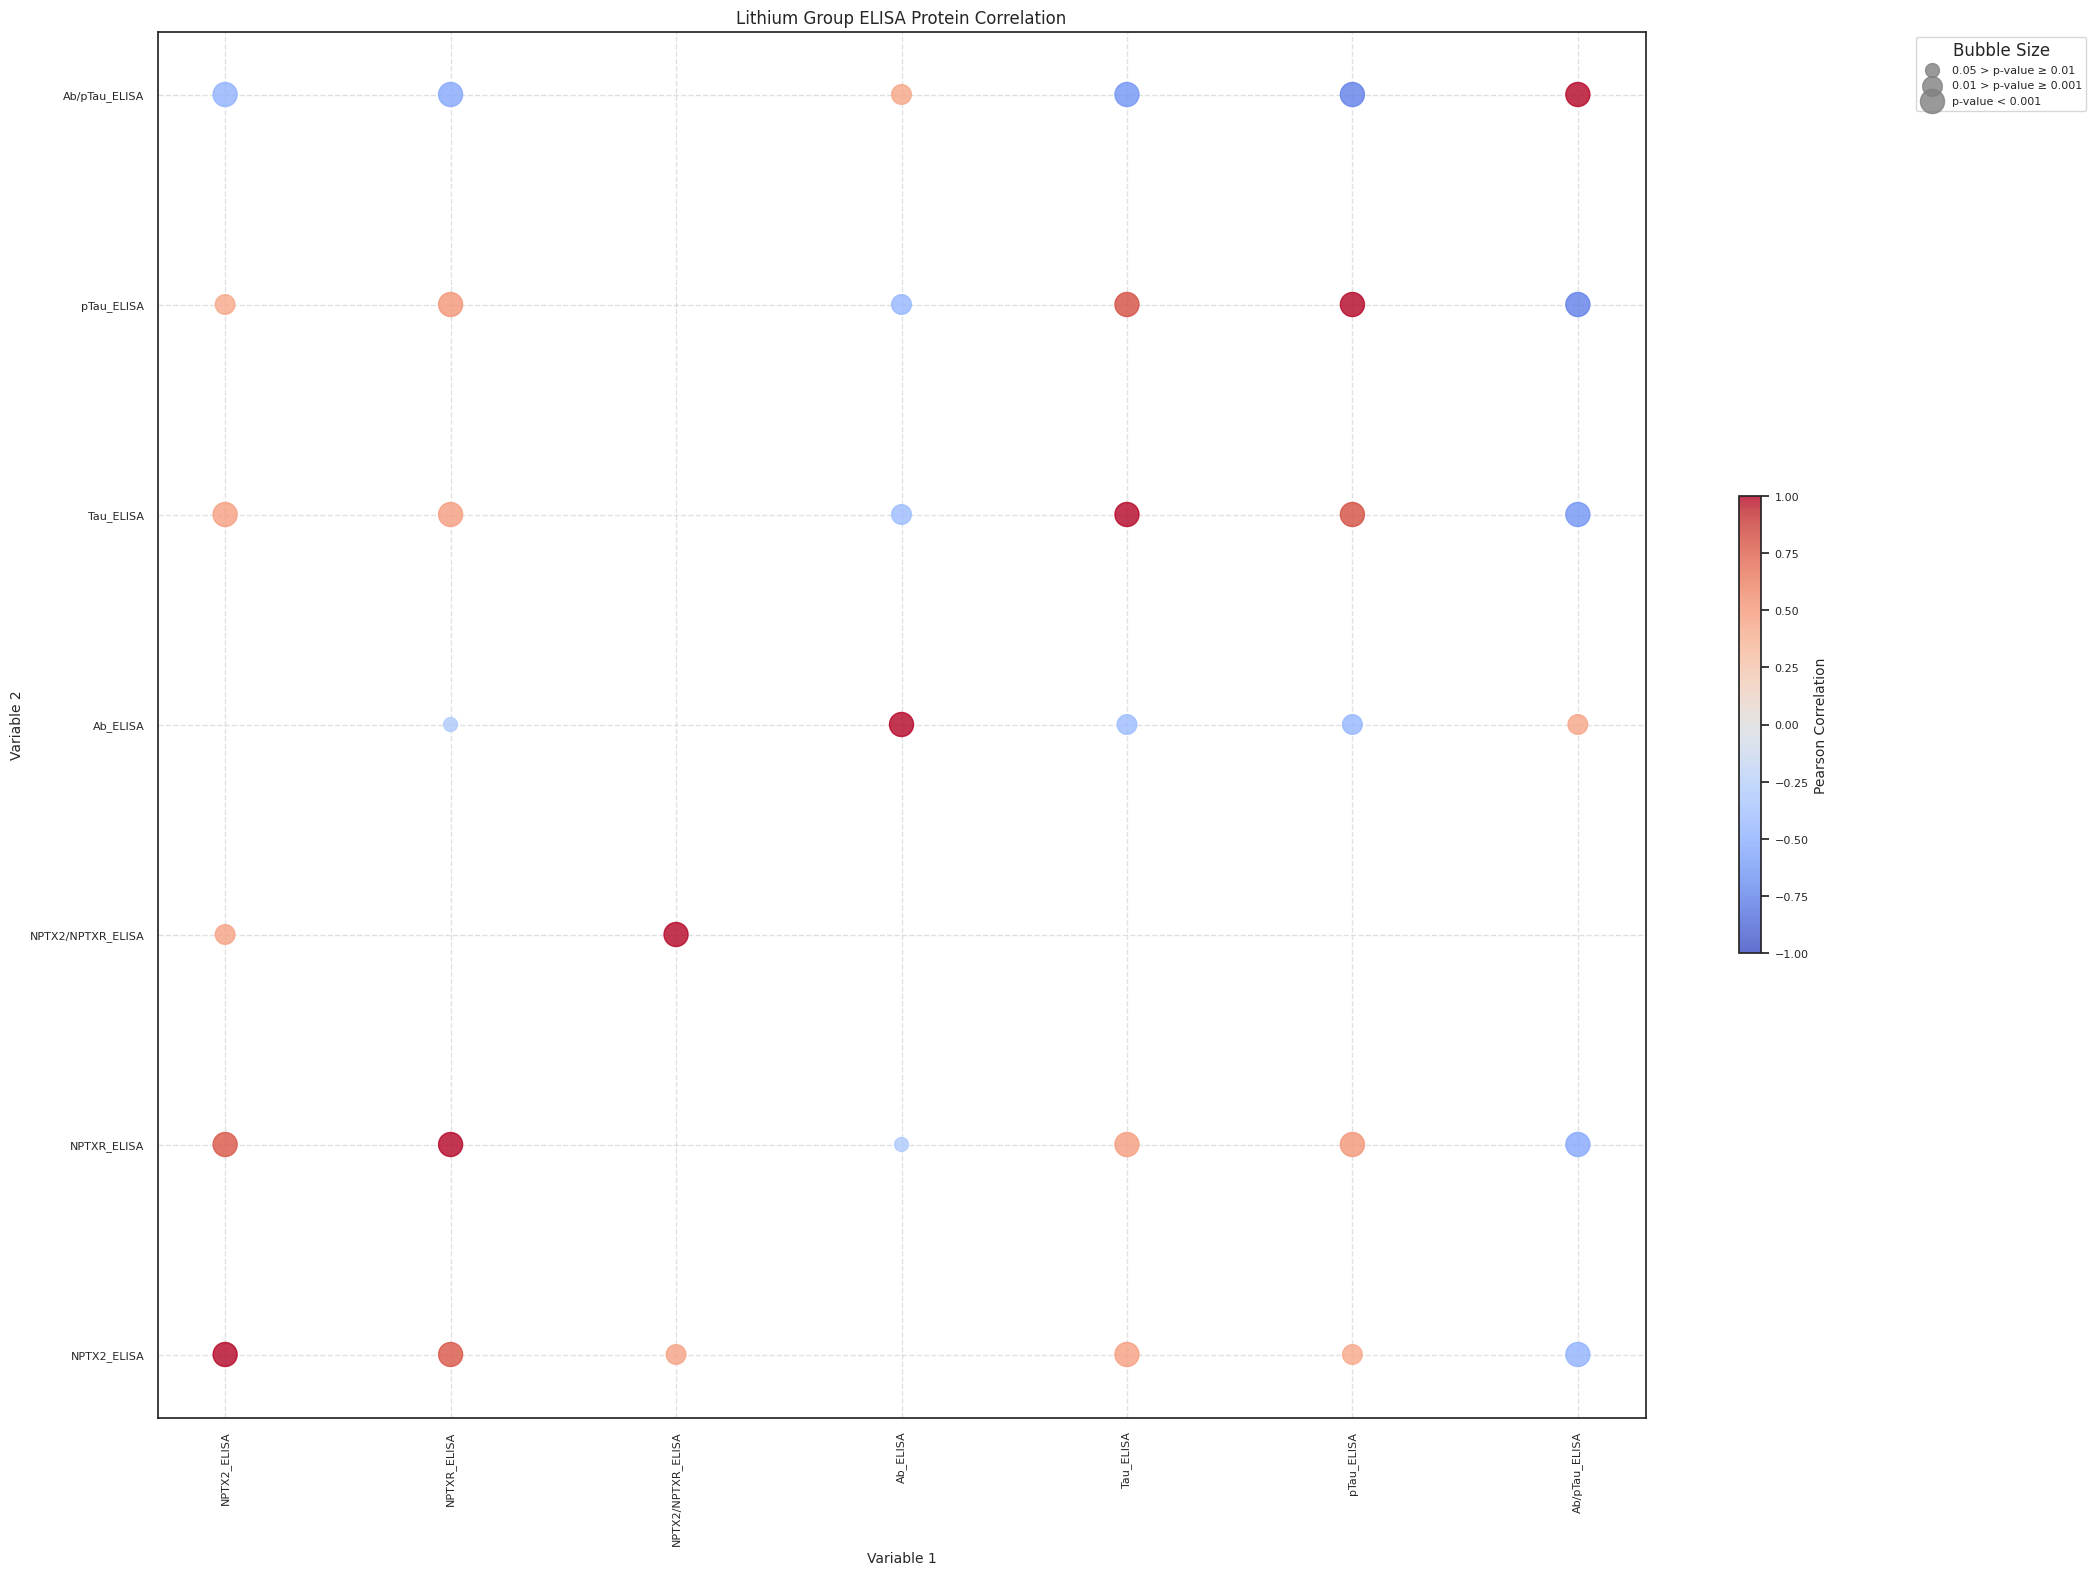

Overall Correlation and p-value Table:
           Variable 1         Variable 2  Correlation       P-value
0         NPTX2_ELISA        NPTX2_ELISA     1.000000  0.000000e+00
1         NPTX2_ELISA        NPTXR_ELISA     0.900297  1.443077e-14
2         NPTX2_ELISA  NPTX2/NPTXR_ELISA     0.066144  6.931762e-01
3         NPTX2_ELISA           Ab_ELISA     0.037412  8.235388e-01
4         NPTX2_ELISA          Tau_ELISA     0.274781  9.499950e-02
5         NPTX2_ELISA         pTau_ELISA     0.174276  2.953501e-01
6         NPTX2_ELISA      Ab/pTau_ELISA    -0.072544  6.651435e-01
7         NPTXR_ELISA        NPTX2_ELISA     0.900297  1.443077e-14
8         NPTXR_ELISA        NPTXR_ELISA     1.000000  0.000000e+00
9         NPTXR_ELISA  NPTX2/NPTXR_ELISA    -0.342926  3.505649e-02
10        NPTXR_ELISA           Ab_ELISA    -0.039677  8.130387e-01
11        NPTXR_ELISA          Tau_ELISA     0.281929  8.637222e-02
12        NPTXR_ELISA         pTau_ELISA     0.256864  1.195239e-01
13       

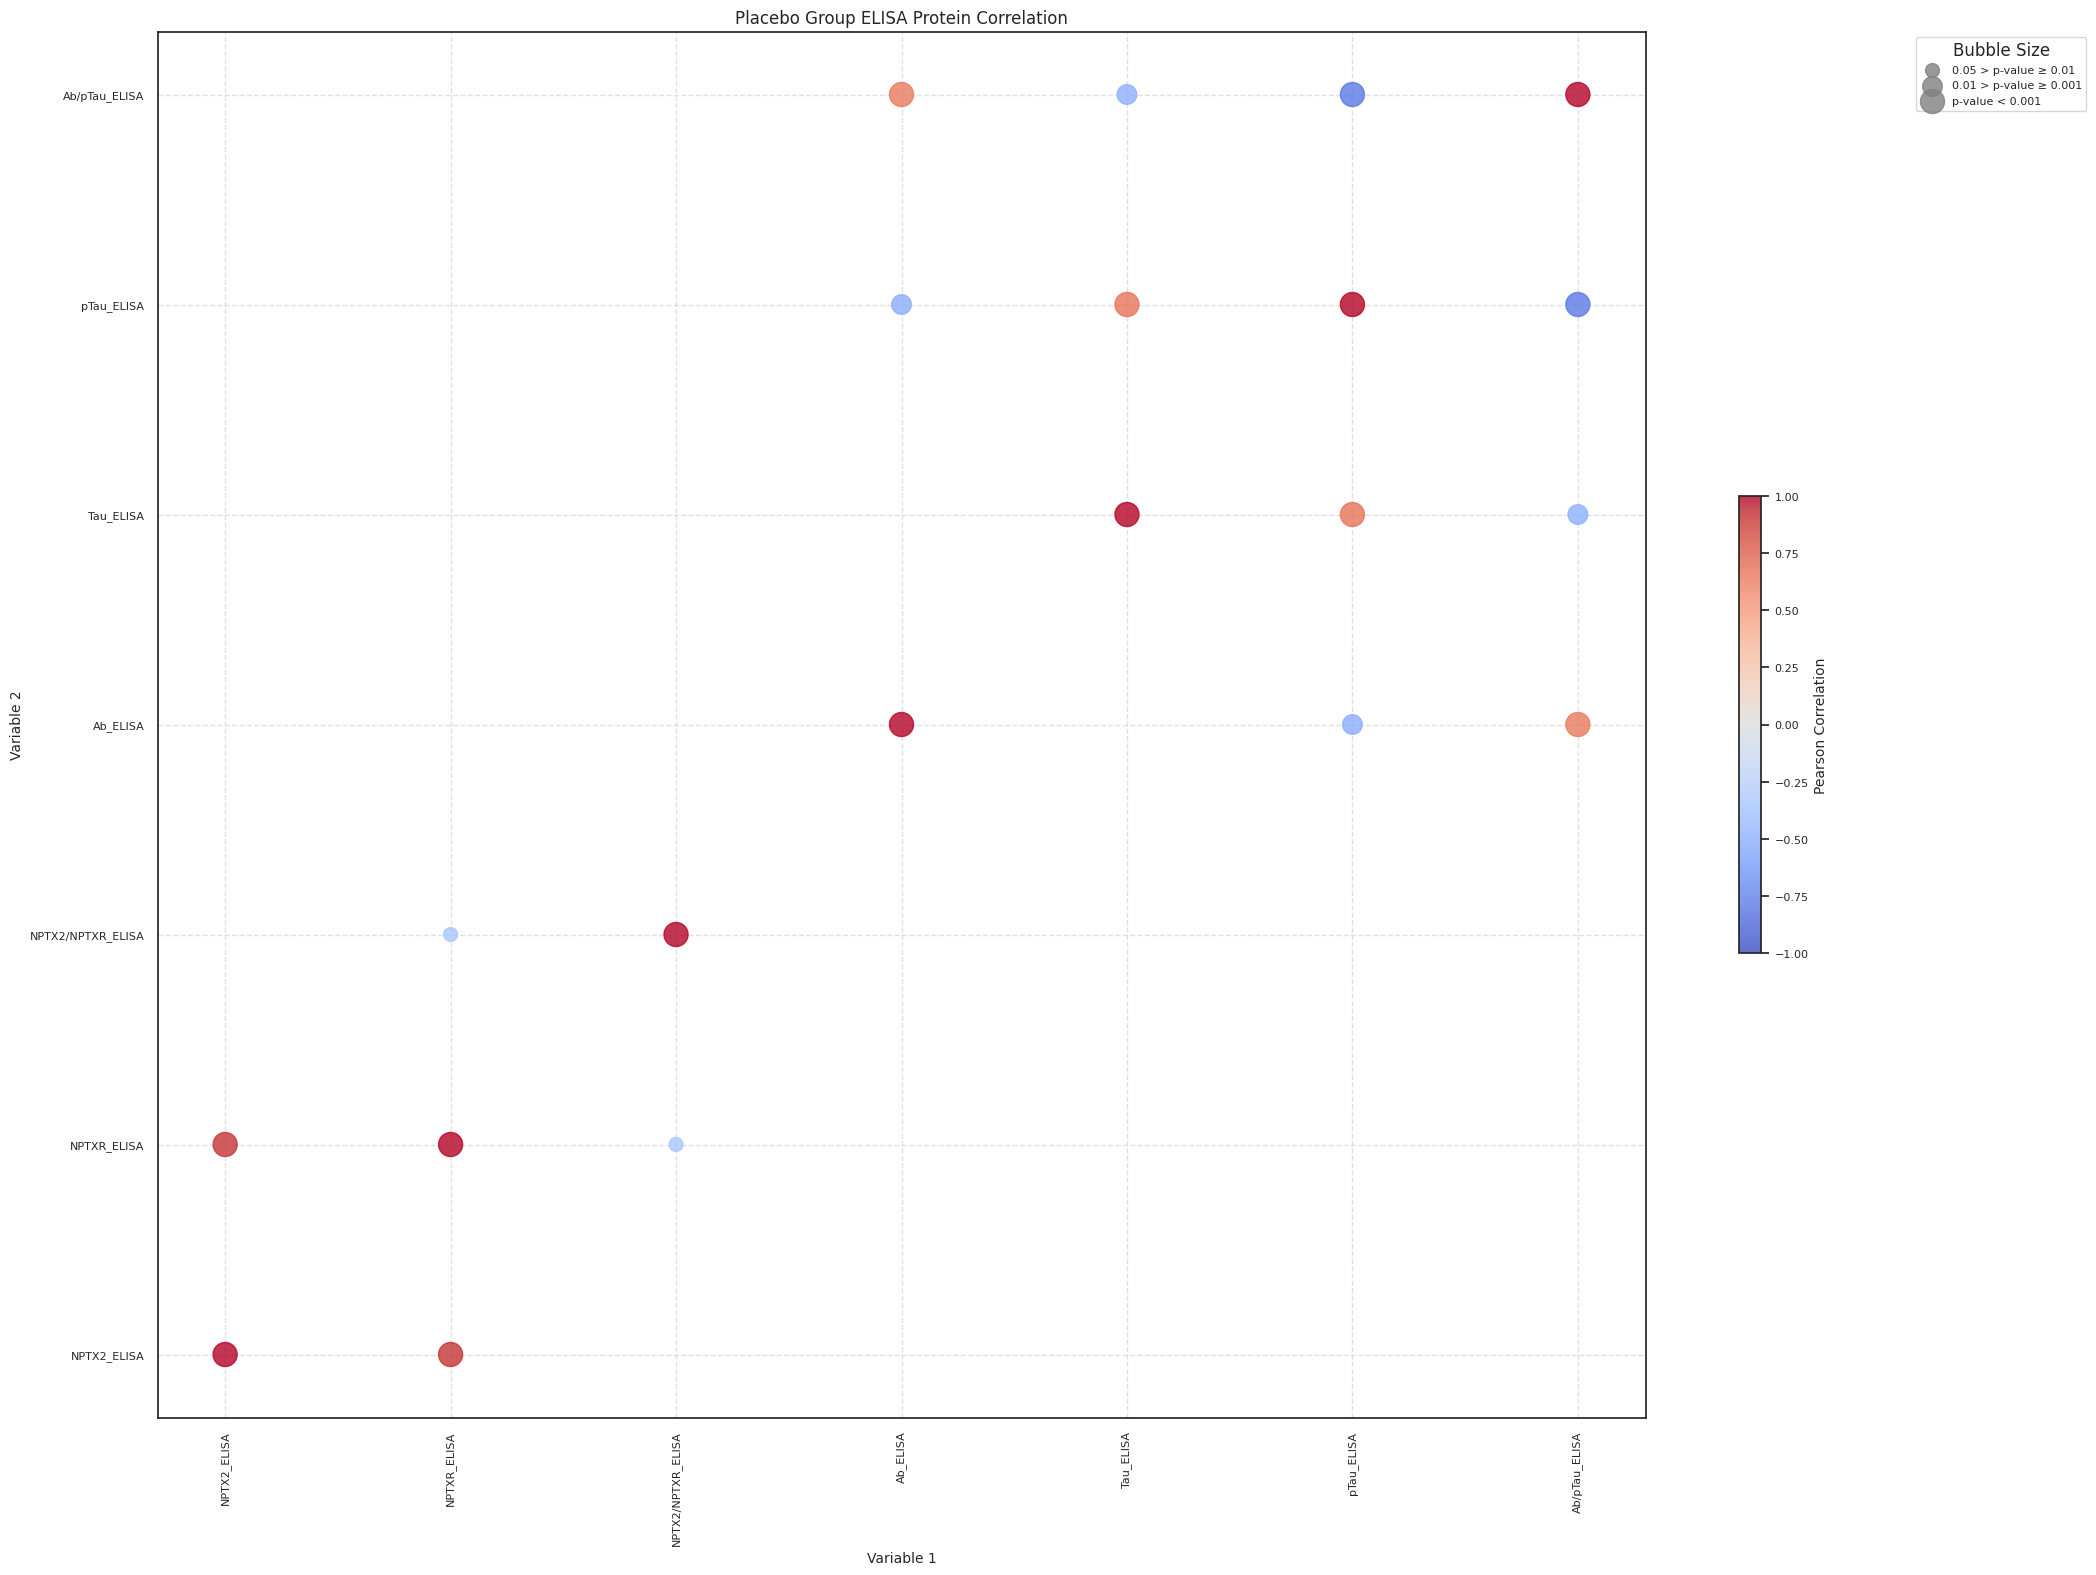

In [ ]:
# 그룹 정보 추출 (Lithium과 Placebo로 시작하는 그룹)
# 결측값을 무시하고 필터링
lithium_group = df[df['Group'].notna() & df['Group'].str.startswith('Lithium')]  # Lithium으로 시작하는 그룹
placebo_group = df[df['Group'].notna() & df['Group'].str.startswith('Placebo')]  # Placebo로 시작하는 그룹

# ELISA 데이터만 분리
elisa_columns = [col for col in df.columns if '_ELISA' in col]

# Lithium 그룹의 ELISA 데이터
lithium_elisa = lithium_group[elisa_columns].dropna()

# Placebo 그룹의 ELISA 데이터
placebo_elisa = placebo_group[elisa_columns].dropna()

# 상관관계 및 p-value 계산 함수
def calculate_correlation(df):
    corr_matrix = df.corr(method='pearson')
    p_matrix = np.zeros_like(corr_matrix)
    for i in range(len(df.columns)):
        for j in range(len(df.columns)):
            if i != j:
                _, p_matrix[i, j] = pearsonr(df.iloc[:, i], df.iloc[:, j])
    return corr_matrix, p_matrix

# Lithium 그룹에 대해 상관관계 및 p-value 계산
lithium_corr, lithium_p = calculate_correlation(lithium_elisa)

# Placebo 그룹에 대해 상관관계 및 p-value 계산
placebo_corr, placebo_p = calculate_correlation(placebo_elisa)

# 시각화 함수 정의
def plot_bubble_correlation(corr_matrix, pvalue_matrix, title):
    # 상관계수와 p-value를 하나의 데이터프레임으로 병합
    corr_df = corr_matrix.stack().reset_index()
    corr_df.columns = ['Variable 1', 'Variable 2', 'Correlation']

    pvalue_df = pd.DataFrame(pvalue_matrix, index=corr_matrix.index, columns=corr_matrix.columns)  # p-value 행렬을 DataFrame으로 변환
    pvalue_df = pvalue_df.stack().reset_index()
    pvalue_df.columns = ['Variable 1', 'Variable 2', 'P-value']

    merged_df = pd.merge(corr_df, pvalue_df, on=['Variable 1', 'Variable 2'])

    # p-value에 따라 원의 크기 설정 (3단계로 나눔)
    def get_bubble_size(p_value):
        if p_value < 0.001:
            return 300  # 가장 큰 원
        elif 0.001 <= p_value < 0.01:
            return 200  # 중간 원
        elif 0.01 <= p_value < 0.05:
            return 100  # 가장 작은 원
        else:
            return 0  # 0.05 이상인 경우 표시하지 않음

    # 원의 크기 계산
    merged_df['Bubble Size'] = merged_df['P-value'].apply(get_bubble_size)

    # 그림 크기 설정 (크게 조정)
    plt.figure(figsize=(24, 18))  # 그림 크기를 24x18로 늘림

    # 폰트 설정 (Arial과 비슷한 sans-serif 폰트 사용)
    plt.rcParams['font.family'] = 'sans-serif'
    plt.rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans', 'Helvetica', 'Lucida Grande', 'Verdana']
    plt.rcParams['font.size'] = 10  # 기본 폰트 크기 줄임
    plt.rcParams['axes.titlesize'] = 12  # 제목 폰트 크기 줄임
    plt.rcParams['axes.labelsize'] = 10  # 축 레이블 폰트 크기 줄임
    plt.rcParams['xtick.labelsize'] = 8  # x축 틱 폰트 크기 줄임
    plt.rcParams['ytick.labelsize'] = 8  # y축 틱 폰트 크기 줄임

    # Bubble Chart 그리기
    scatter = plt.scatter(
        x=merged_df['Variable 1'],  # x 좌표 (변수 1)
        y=merged_df['Variable 2'],  # y 좌표 (변수 2)
        s=merged_df['Bubble Size'],  # 원의 크기 (p-value에 따라 3단계로 설정)
        c=merged_df['Correlation'],  # 원의 색상 (상관계수)
        cmap='coolwarm',  # 색상 맵: -1(파란색) ~ 1(빨간색)
        vmin=-1,
        vmax=1,
        alpha=0.8  # 투명도
    )

    # 색상 바 추가 (크기 축소)
    cbar = plt.colorbar(scatter, shrink=0.33)  # 크기 축소
    cbar.set_label('Pearson Correlation', fontsize=10)  # 색상바 레이블 폰트 크기 줄임

    # 축 레이블 및 제목 설정
    plt.xlabel('Variable 1', fontsize=10)
    plt.ylabel('Variable 2', fontsize=10)
    plt.title(title, fontsize=12)

    # x축과 y축의 라벨 회전
    plt.xticks(rotation=90)
    plt.yticks(rotation=0)

    # 그리드 추가
    plt.grid(True, linestyle='--', alpha=0.6)

    # 범례 추가 (원의 크기 설명)
    for pvalue_range, size in zip(
        ['0.05 > p-value ≥ 0.01', '0.01 > p-value ≥ 0.001', 'p-value < 0.001'],  # 범례 설명 수정
        [100, 200, 300]  # 원의 크기
    ):
        plt.scatter([], [], s=size, c='gray', alpha=0.8, label=pvalue_range)  # 범례 설명 적용
    plt.legend(title='Bubble Size', loc='upper right', bbox_to_anchor=(1.3, 1), fontsize=8)  # 범례 폰트 크기 줄임

    # Pearson 상관계수와 p-value 테이블 출력
    print(f"Overall Correlation and p-value Table:")
    print(merged_df[['Variable 1', 'Variable 2', 'Correlation', 'P-value']].dropna(), "\n")

    # Excel로 테이블 저장
    merged_df[['Variable 1', 'Variable 2', 'Correlation', 'P-value']].dropna().to_excel(
        f"../data/output/{title}_correlation_table.xlsx", index=False)

    # PDF로 저장
    plt.savefig(f'{title}_bubble_chart.pdf', format='pdf', bbox_inches='tight')
    plt.show()

# Lithium 그룹 시각화
plot_bubble_correlation(lithium_corr, lithium_p, title='Lithium Group ELISA Protein Correlation')

# Placebo 그룹 시각화
plot_bubble_correlation(placebo_corr, placebo_p, title='Placebo Group ELISA Protein Correlation')

In [ ]:
# 그룹 정보 추출 (Lithium과 Placebo로 시작하는 그룹)
# 결측값을 무시하고 필터링
lithium_group = df[df['Group'].notna() & df['Group'].str.startswith('Lithium')]  # Lithium으로 시작하는 그룹
placebo_group = df[df['Group'].notna() & df['Group'].str.startswith('Placebo')]  # Placebo로 시작하는 그룹

# NULISA 데이터만 분리
nulisa_columns = [col for col in df.columns if '_NULISA' in col]

# Lithium 그룹의 NULISA 데이터
lithium_nulisa = lithium_group[nulisa_columns].dropna()

# Placebo 그룹의 NULISA 데이터
placebo_nulisa = placebo_group[nulisa_columns].dropna()

# 상관관계 및 p-value 계산 함수
def calculate_correlation(df):
    corr_matrix = df.corr(method='pearson')
    p_matrix = np.zeros_like(corr_matrix)
    for i in range(len(df.columns)):
        for j in range(len(df.columns)):
            if i != j:
                _, p_matrix[i, j] = pearsonr(df.iloc[:, i], df.iloc[:, j])
    return corr_matrix, p_matrix

# Lithium 그룹에 대해 상관관계 및 p-value 계산
lithium_corr, lithium_p = calculate_correlation(lithium_nulisa)

# Placebo 그룹에 대해 상관관계 및 p-value 계산
placebo_corr, placebo_p = calculate_correlation(placebo_nulisa)

# 시각화 함수 정의
def plot_bubble_correlation(corr_matrix, pvalue_matrix, title):
    # 상관계수와 p-value를 하나의 데이터프레임으로 병합
    corr_df = corr_matrix.stack().reset_index()
    corr_df.columns = ['Variable 1', 'Variable 2', 'Correlation']

    pvalue_df = pd.DataFrame(pvalue_matrix, index=corr_matrix.index, columns=corr_matrix.columns)  # p-value 행렬을 DataFrame으로 변환
    pvalue_df = pvalue_df.stack().reset_index()
    pvalue_df.columns = ['Variable 1', 'Variable 2', 'P-value']

    merged_df = pd.merge(corr_df, pvalue_df, on=['Variable 1', 'Variable 2'])

    # p-value에 따라 원의 크기 설정 (3단계로 나눔)
    def get_bubble_size(p_value):
        if p_value < 0.001:
            return 80  # 가장 큰 원
        elif 0.001 <= p_value < 0.01:
            return 40  # 중간 원
        elif 0.01 <= p_value < 0.05:
            return 20  # 가장 작은 원
        else:
            return 0  # 0.05 이상인 경우 표시하지 않음

    # 원의 크기 계산
    merged_df['Bubble Size'] = merged_df['P-value'].apply(get_bubble_size)

    # 그림 크기 설정 (크게 조정)
    plt.figure(figsize=(24, 18))  # 그림 크기를 24x18로 늘림

    # 폰트 설정 (Arial과 비슷한 sans-serif 폰트 사용)
    plt.rcParams['font.family'] = 'sans-serif'
    plt.rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans', 'Helvetica', 'Lucida Grande', 'Verdana']
    plt.rcParams['font.size'] = 10  # 기본 폰트 크기 줄임
    plt.rcParams['axes.titlesize'] = 12  # 제목 폰트 크기 줄임
    plt.rcParams['axes.labelsize'] = 10  # 축 레이블 폰트 크기 줄임
    plt.rcParams['xtick.labelsize'] = 8  # x축 틱 폰트 크기 줄임
    plt.rcParams['ytick.labelsize'] = 8  # y축 틱 폰트 크기 줄임

    # Bubble Chart 그리기
    scatter = plt.scatter(
        x=merged_df['Variable 1'],  # x 좌표 (변수 1)
        y=merged_df['Variable 2'],  # y 좌표 (변수 2)
        s=merged_df['Bubble Size'],  # 원의 크기 (p-value에 따라 3단계로 설정)
        c=merged_df['Correlation'],  # 원의 색상 (상관계수)
        cmap='coolwarm',  # 색상 맵: -1(파란색) ~ 1(빨간색)
        vmin=-1,
        vmax=1,
        alpha=0.8  # 투명도
    )

    # 색상 바 추가 (크기 축소)
    cbar = plt.colorbar(scatter, shrink=0.33)  # 크기 축소
    cbar.set_label('Pearson Correlation', fontsize=10)  # 색상바 레이블 폰트 크기 줄임

    # 축 레이블 및 제목 설정
    plt.xlabel('Variable 1', fontsize=10)
    plt.ylabel('Variable 2', fontsize=10)
    plt.title(title, fontsize=12)

    # x축과 y축의 라벨 회전
    plt.xticks(rotation=90)
    plt.yticks(rotation=0)

    # 그리드 추가
    plt.grid(True, linestyle='--', alpha=0.6)

    # 범례 추가 (원의 크기 설명)
    for pvalue_range, size in zip(
        ['0.05 > p-value ≥ 0.01', '0.01 > p-value ≥ 0.001', 'p-value < 0.001'],  # 범례 설명 수정
        [20, 40, 80]  # 원의 크기
    ):
        plt.scatter([], [], s=size, c='gray', alpha=0.8, label=pvalue_range)  # 범례 설명 적용
    plt.legend(title='Bubble Size', loc='upper right', bbox_to_anchor=(1.3, 1), fontsize=8)  # 범례 폰트 크기 줄임

    # Pearson 상관계수와 p-value 테이블 출력
    print(f"Overall Correlation and p-value Table:")
    print(merged_df[['Variable 1', 'Variable 2', 'Correlation', 'P-value']].dropna(), "\n")

    # Excel로 테이블 저장
    merged_df[['Variable 1', 'Variable 2', 'Correlation', 'P-value']].dropna().to_excel(
        f"../data/output/{title}_correlation_table.xlsx", index=False)

    # PDF로 저장
    plt.savefig(f'{title}_bubble_chart.pdf', format='pdf', bbox_inches='tight')
    plt.show()

# Lithium 그룹 시각화
plot_bubble_correlation(lithium_corr, lithium_p, title='Lithium Group NULISA Protein Correlation')

# Placebo 그룹 시각화
plot_bubble_correlation(placebo_corr, placebo_p, title='Placebo Group NULISA Protein Correlation')

Output hidden; open in https://colab.research.google.com to view.

Overall Correlation and p-value Table:
      Variable 1     Variable 2  Correlation       P-value
0    GFRA3_PRM      GFRA3_PRM       1.000000  0.000000e+00
1    GFRA3_PRM       GPC1_PRM       0.694036  1.532475e-09
2    GFRA3_PRM      NEGR1_PRM       0.511113  4.134446e-05
3    GFRA3_PRM    RTN4RL2_PRM       0.398293  1.958247e-03
4    GFRA3_PRM      GRIA4_PRM       0.598862  6.839114e-07
..           ...            ...          ...           ...
319  TREM2_PRM      SCRN1_PRM       0.431254  7.256069e-04
320  TREM2_PRM       C1QA_PRM       0.584617  1.445618e-06
321  TREM2_PRM      CNTFR_PRM       0.726585  1.072635e-10
322  TREM2_PRM        VGF_PRM       0.481152  1.316538e-04
323  TREM2_PRM      TREM2_PRM       1.000000  0.000000e+00

[324 rows x 4 columns] 



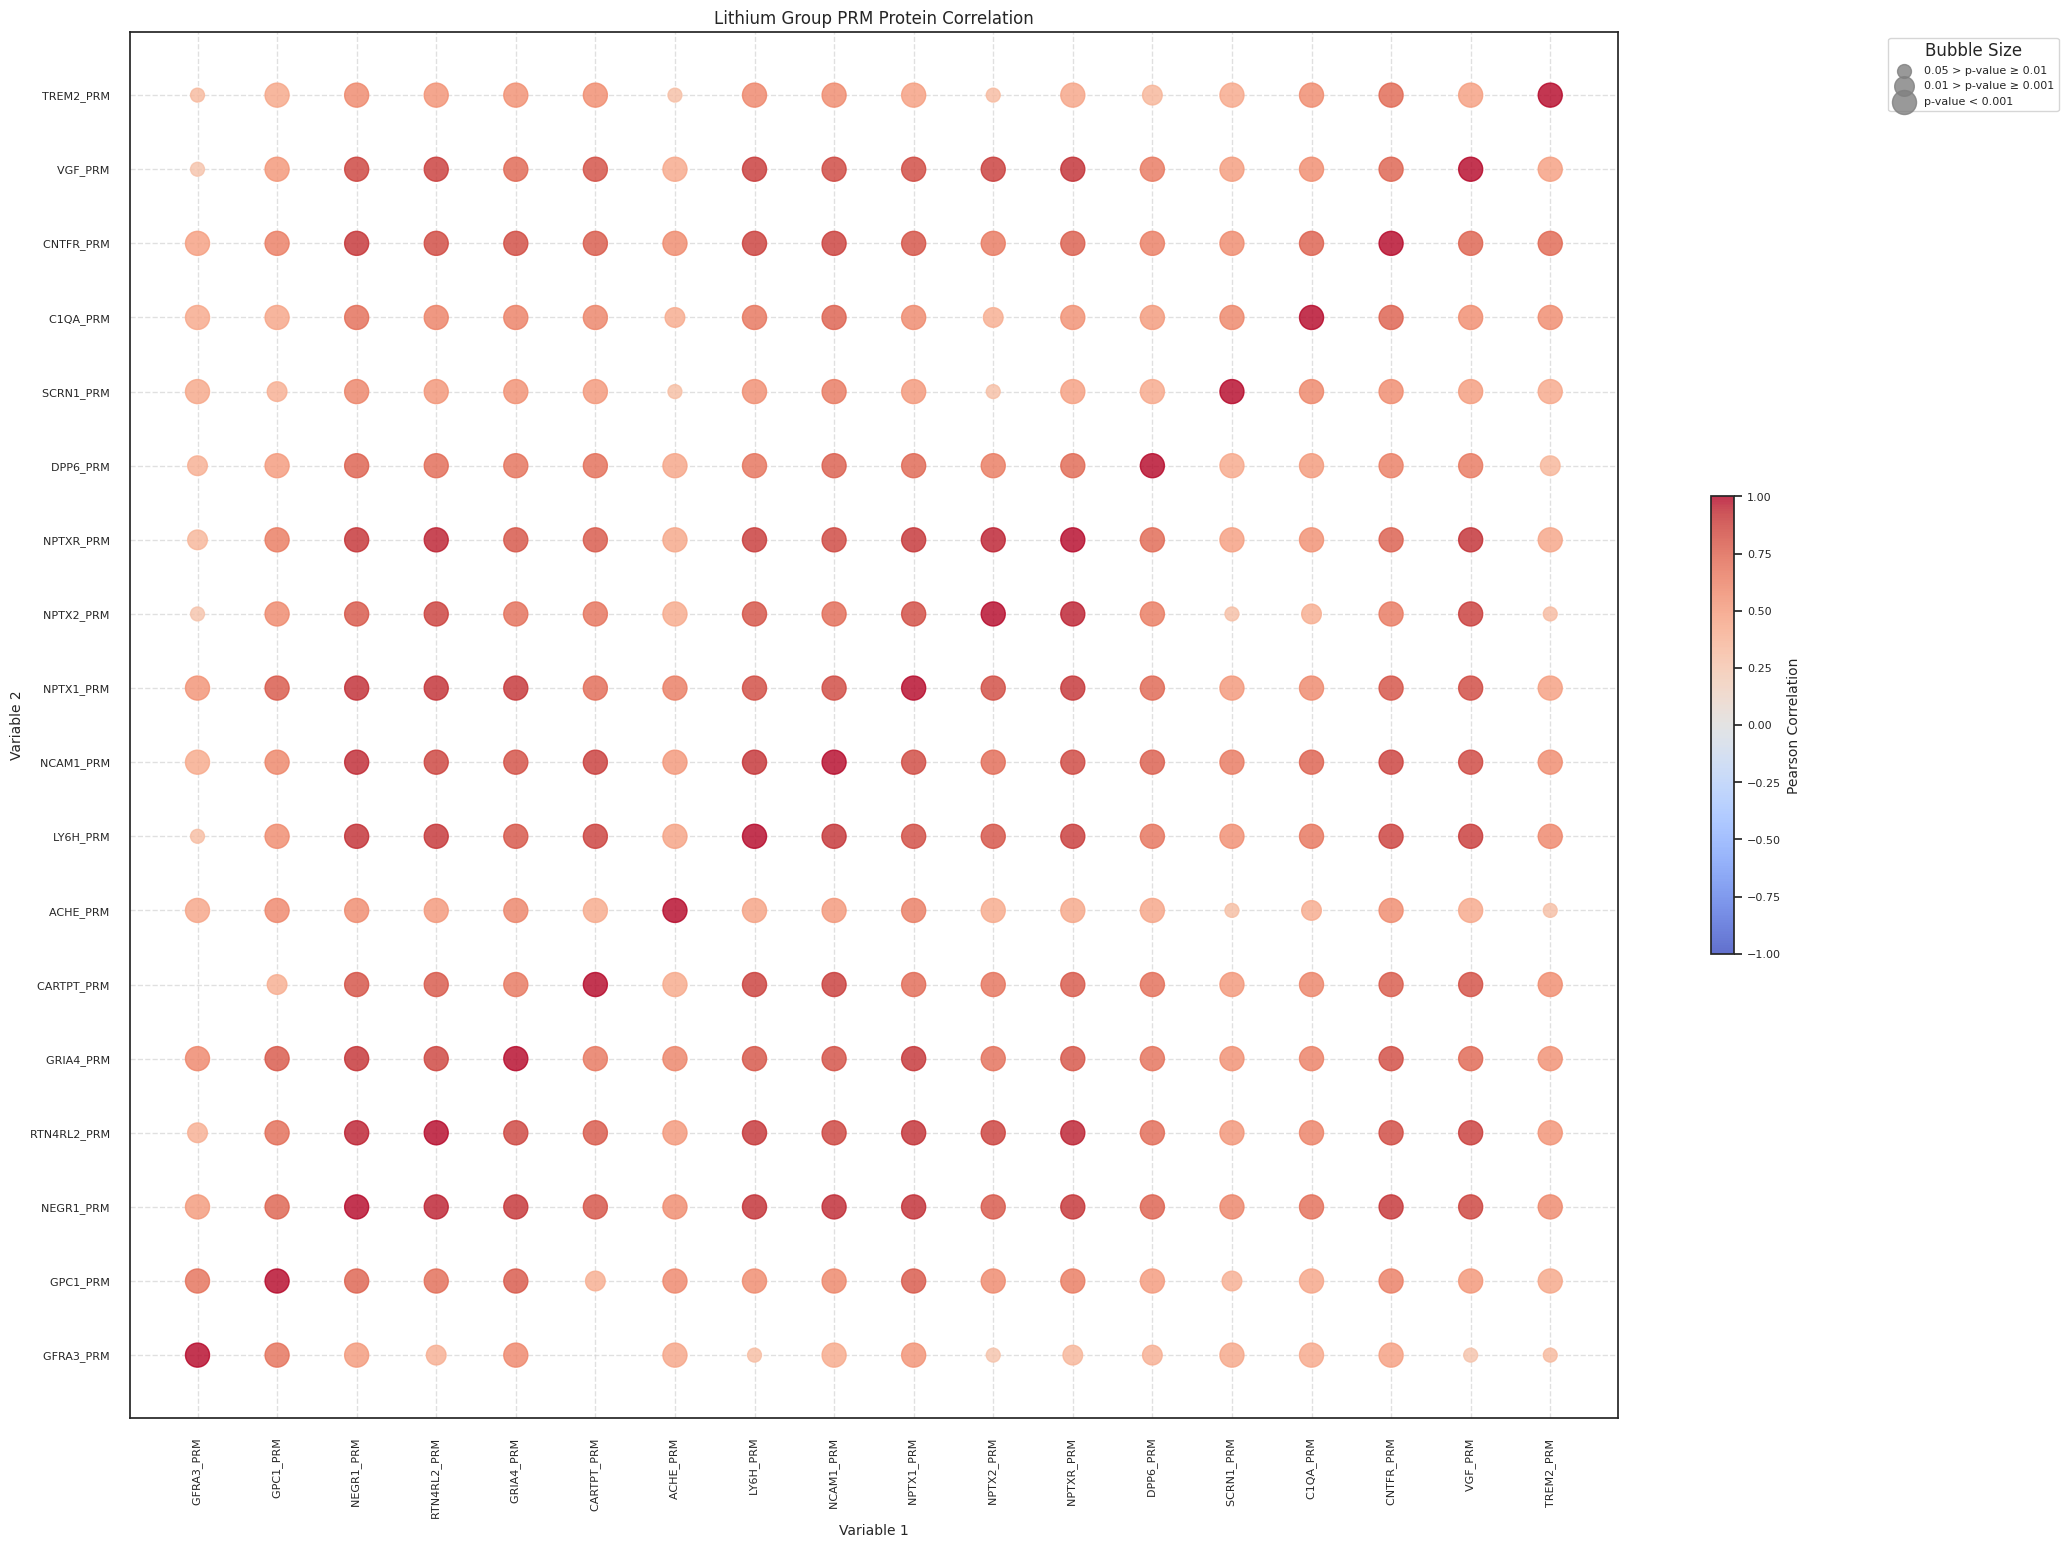

Overall Correlation and p-value Table:
      Variable 1     Variable 2  Correlation       P-value
0    GFRA3_PRM      GFRA3_PRM       1.000000  0.000000e+00
1    GFRA3_PRM       GPC1_PRM       0.286939  5.896253e-02
2    GFRA3_PRM      NEGR1_PRM       0.499100  5.633507e-04
3    GFRA3_PRM    RTN4RL2_PRM       0.342168  2.299882e-02
4    GFRA3_PRM      GRIA4_PRM       0.404896  6.404917e-03
..           ...            ...          ...           ...
319  TREM2_PRM      SCRN1_PRM       0.253277  9.714475e-02
320  TREM2_PRM       C1QA_PRM       0.668699  7.008832e-07
321  TREM2_PRM      CNTFR_PRM       0.620770  6.939626e-06
322  TREM2_PRM        VGF_PRM       0.379148  1.114453e-02
323  TREM2_PRM      TREM2_PRM       1.000000  0.000000e+00

[324 rows x 4 columns] 



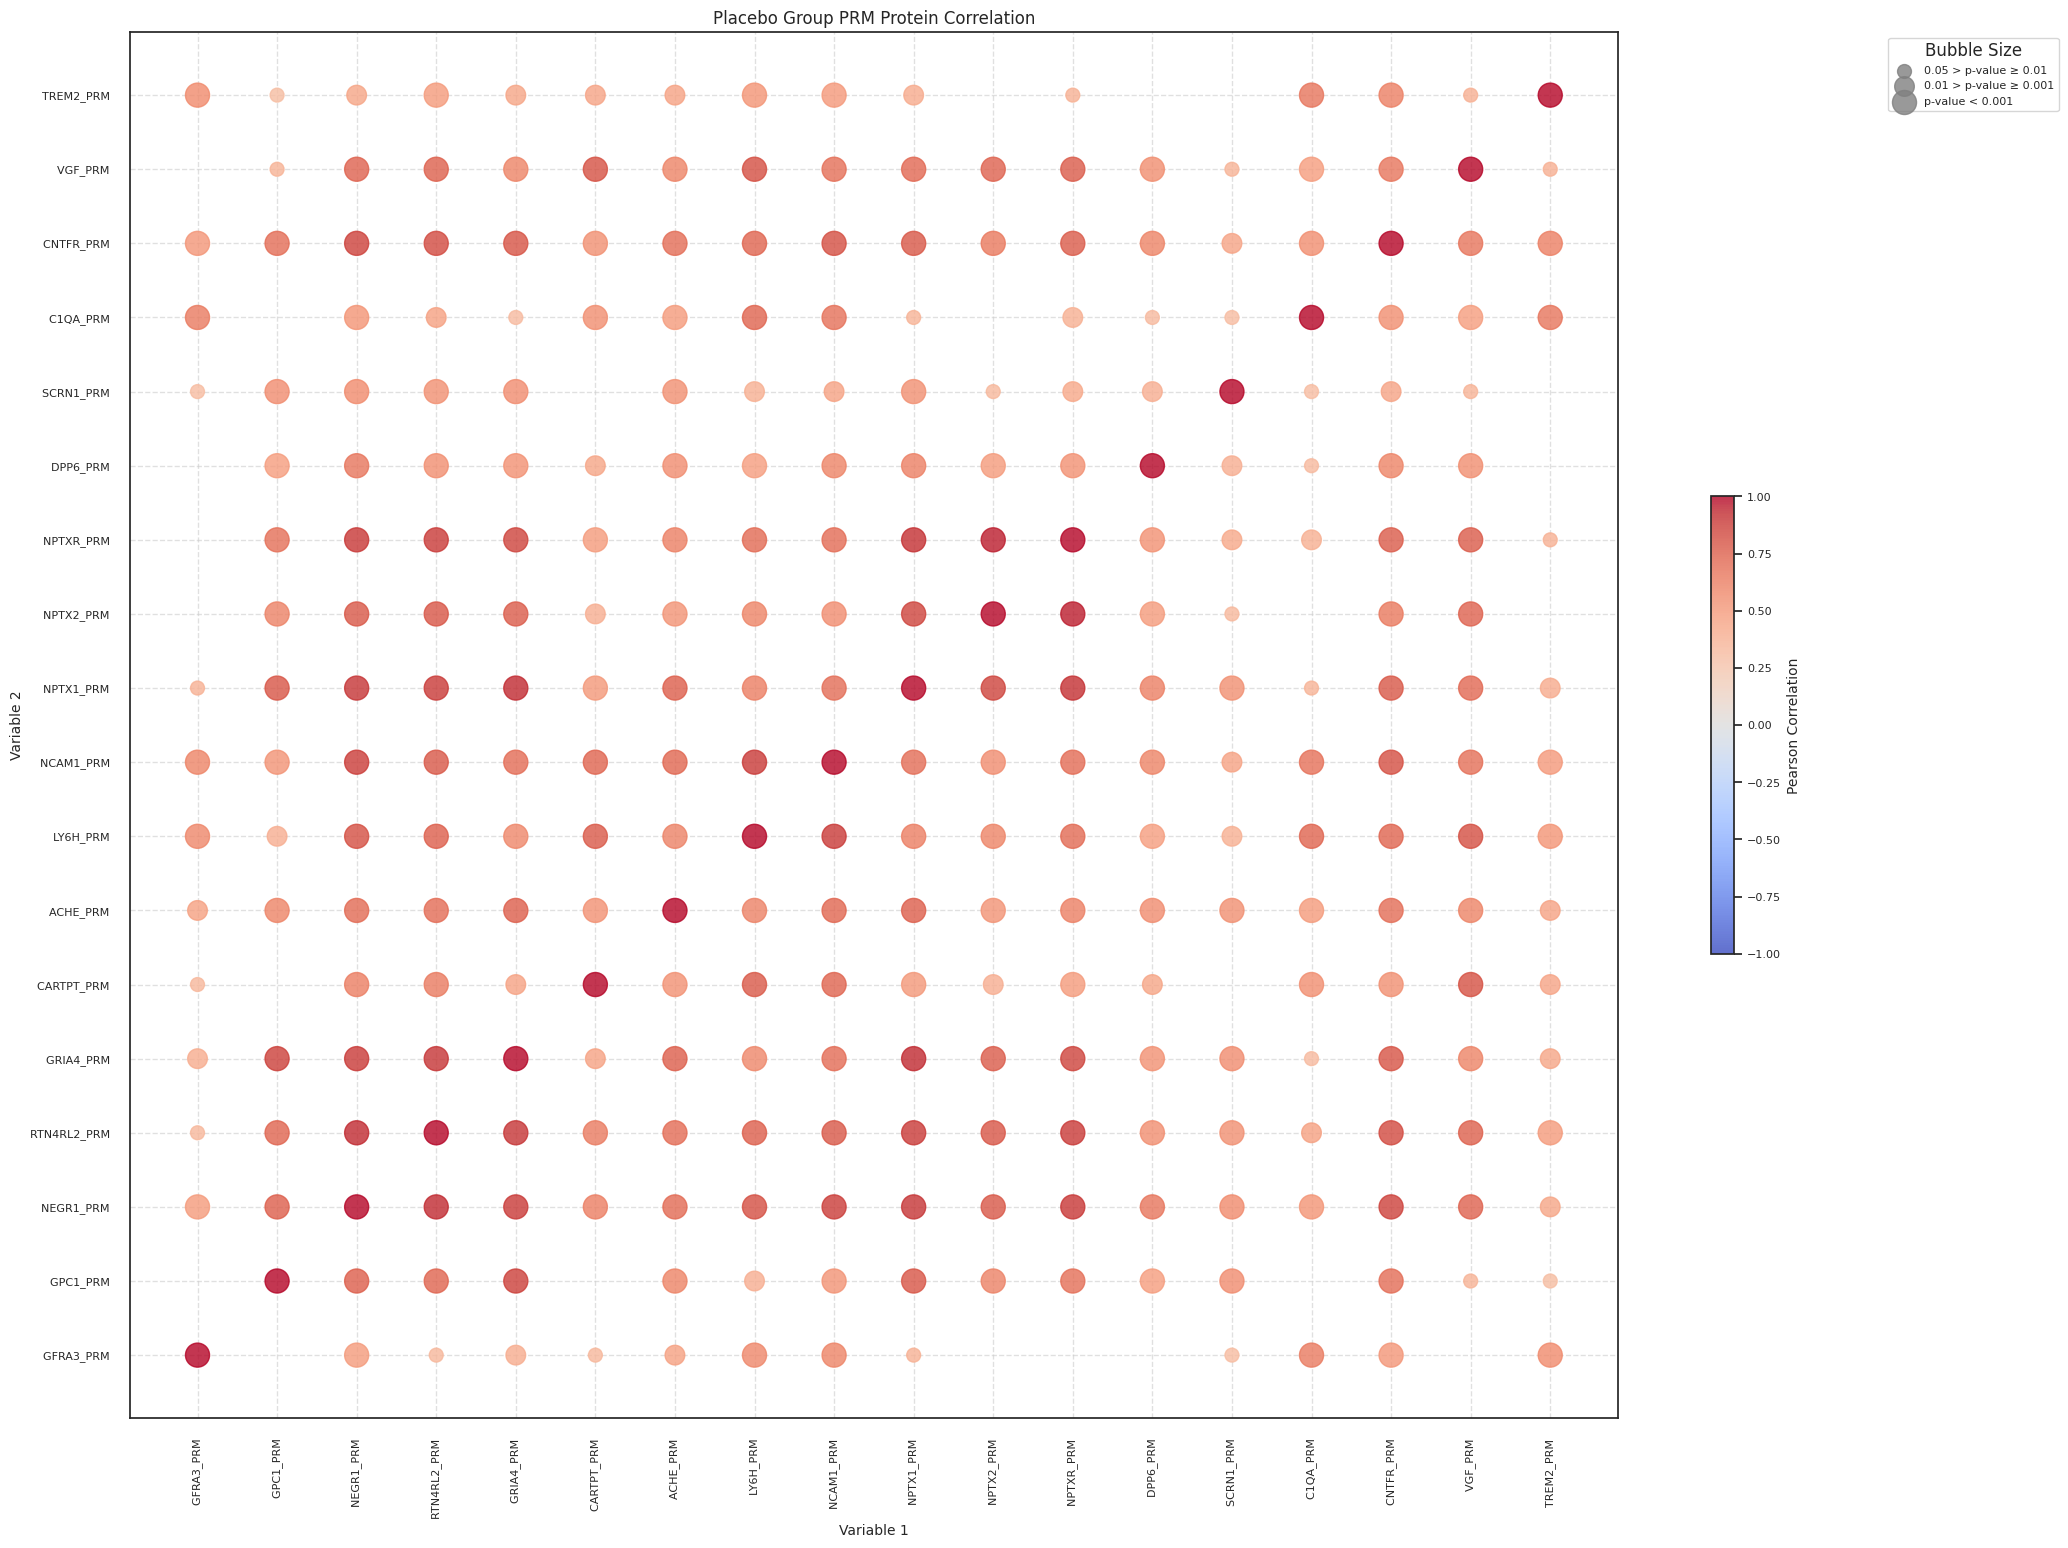

In [ ]:
# 그룹 정보 추출 (Lithium과 Placebo로 시작하는 그룹)
# 결측값을 무시하고 필터링
lithium_group = df[df['Group'].notna() & df['Group'].str.startswith('Lithium')]  # Lithium으로 시작하는 그룹
placebo_group = df[df['Group'].notna() & df['Group'].str.startswith('Placebo')]  # Placebo로 시작하는 그룹

# PRM 데이터만 분리
prm_columns = [col for col in df.columns if '_PRM' in col]

# Lithium 그룹의 PRM 데이터
lithium_prm = lithium_group[prm_columns].dropna()

# Placebo 그룹의 PRM 데이터
placebo_prm = placebo_group[prm_columns].dropna()

# 상관관계 및 p-value 계산 함수
def calculate_correlation(df):
    corr_matrix = df.corr(method='pearson')
    p_matrix = np.zeros_like(corr_matrix)
    for i in range(len(df.columns)):
        for j in range(len(df.columns)):
            if i != j:
                _, p_matrix[i, j] = pearsonr(df.iloc[:, i], df.iloc[:, j])
    return corr_matrix, p_matrix

# Lithium 그룹에 대해 상관관계 및 p-value 계산
lithium_corr, lithium_p = calculate_correlation(lithium_prm)

# Placebo 그룹에 대해 상관관계 및 p-value 계산
placebo_corr, placebo_p = calculate_correlation(placebo_prm)

# 시각화 함수 정의
def plot_bubble_correlation(corr_matrix, pvalue_matrix, title):
    # 상관계수와 p-value를 하나의 데이터프레임으로 병합
    corr_df = corr_matrix.stack().reset_index()
    corr_df.columns = ['Variable 1', 'Variable 2', 'Correlation']

    pvalue_df = pd.DataFrame(pvalue_matrix, index=corr_matrix.index, columns=corr_matrix.columns)  # p-value 행렬을 DataFrame으로 변환
    pvalue_df = pvalue_df.stack().reset_index()
    pvalue_df.columns = ['Variable 1', 'Variable 2', 'P-value']

    merged_df = pd.merge(corr_df, pvalue_df, on=['Variable 1', 'Variable 2'])

    # p-value에 따라 원의 크기 설정 (3단계로 나눔)
    def get_bubble_size(p_value):
        if p_value < 0.001:
            return 300  # 가장 큰 원
        elif 0.001 <= p_value < 0.01:
            return 200  # 중간 원
        elif 0.01 <= p_value < 0.05:
            return 100  # 가장 작은 원
        else:
            return 0  # 0.05 이상인 경우 표시하지 않음

    # 원의 크기 계산
    merged_df['Bubble Size'] = merged_df['P-value'].apply(get_bubble_size)

    # 그림 크기 설정 (크게 조정)
    plt.figure(figsize=(24, 18))  # 그림 크기를 24x18로 늘림

    # 폰트 설정 (Arial과 비슷한 sans-serif 폰트 사용)
    plt.rcParams['font.family'] = 'sans-serif'
    plt.rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans', 'Helvetica', 'Lucida Grande', 'Verdana']
    plt.rcParams['font.size'] = 10  # 기본 폰트 크기 줄임
    plt.rcParams['axes.titlesize'] = 12  # 제목 폰트 크기 줄임
    plt.rcParams['axes.labelsize'] = 10  # 축 레이블 폰트 크기 줄임
    plt.rcParams['xtick.labelsize'] = 8  # x축 틱 폰트 크기 줄임
    plt.rcParams['ytick.labelsize'] = 8  # y축 틱 폰트 크기 줄임

    # Bubble Chart 그리기
    scatter = plt.scatter(
        x=merged_df['Variable 1'],  # x 좌표 (변수 1)
        y=merged_df['Variable 2'],  # y 좌표 (변수 2)
        s=merged_df['Bubble Size'],  # 원의 크기 (p-value에 따라 3단계로 설정)
        c=merged_df['Correlation'],  # 원의 색상 (상관계수)
        cmap='coolwarm',  # 색상 맵: -1(파란색) ~ 1(빨간색)
        vmin=-1,
        vmax=1,
        alpha=0.8  # 투명도
    )

    # 색상 바 추가 (크기 축소)
    cbar = plt.colorbar(scatter, shrink=0.33)  # 크기 축소
    cbar.set_label('Pearson Correlation', fontsize=10)  # 색상바 레이블 폰트 크기 줄임

    # 축 레이블 및 제목 설정
    plt.xlabel('Variable 1', fontsize=10)
    plt.ylabel('Variable 2', fontsize=10)
    plt.title(title, fontsize=12)

    # x축과 y축의 라벨 회전
    plt.xticks(rotation=90)
    plt.yticks(rotation=0)

    # 그리드 추가
    plt.grid(True, linestyle='--', alpha=0.6)

    # 범례 추가 (원의 크기 설명)
    for pvalue_range, size in zip(
        ['0.05 > p-value ≥ 0.01', '0.01 > p-value ≥ 0.001', 'p-value < 0.001'],  # 범례 설명 수정
        [100, 200, 300]  # 원의 크기
    ):
        plt.scatter([], [], s=size, c='gray', alpha=0.8, label=pvalue_range)  # 범례 설명 적용
    plt.legend(title='Bubble Size', loc='upper right', bbox_to_anchor=(1.3, 1), fontsize=8)  # 범례 폰트 크기 줄임

    # Pearson 상관계수와 p-value 테이블 출력
    print(f"Overall Correlation and p-value Table:")
    print(merged_df[['Variable 1', 'Variable 2', 'Correlation', 'P-value']].dropna(), "\n")

    # Excel로 테이블 저장
    merged_df[['Variable 1', 'Variable 2', 'Correlation', 'P-value']].dropna().to_excel(
        f"../data/output/{title}_correlation_table.xlsx", index=False)

    # PDF로 저장
    plt.savefig(f'{title}_bubble_chart.pdf', format='pdf', bbox_inches='tight')
    plt.show()

# Lithium 그룹 시각화
plot_bubble_correlation(lithium_corr, lithium_p, title='Lithium Group PRM Protein Correlation')

# Placebo 그룹 시각화
plot_bubble_correlation(placebo_corr, placebo_p, title='Placebo Group PRM Protein Correlation')

In [ ]:
# 그룹 정보 추출 (Lithium과 Placebo로 시작하는 그룹)
# 결측값을 무시하고 필터링
lithium_group = df[df['Group'].notna() & df['Group'].str.startswith('Lithium')]  # Lithium으로 시작하는 그룹
placebo_group = df[df['Group'].notna() & df['Group'].str.startswith('Placebo')]  # Placebo로 시작하는 그룹

# ELISA, NULISA, PRM 데이터 컬럼 분리
elisa_columns = [col for col in df.columns if '_ELISA' in col]
nulisa_columns = [col for col in df.columns if '_NULISA' in col]
prm_columns = [col for col in df.columns if '_PRM' in col]

# Lithium 그룹의 데이터
lithium_elisa = lithium_group[elisa_columns].dropna()
lithium_nulisa = lithium_group[nulisa_columns].dropna()
lithium_prm = lithium_group[prm_columns].dropna()

# Placebo 그룹의 데이터
placebo_elisa = placebo_group[elisa_columns].dropna()
placebo_nulisa = placebo_group[nulisa_columns].dropna()
placebo_prm = placebo_group[prm_columns].dropna()

# 상관관계 계산 함수 (두 데이터프레임 간의 상관관계 계산)
def calculate_cross_correlation(df1, df2):
    # 두 데이터프레임의 공통 행만 선택
    common_index = df1.index.intersection(df2.index)
    df1_common = df1.loc[common_index]
    df2_common = df2.loc[common_index]

    corr_matrix = np.zeros((len(df1_common.columns), len(df2_common.columns)))
    p_matrix = np.zeros((len(df1_common.columns), len(df2_common.columns)))

    for i in range(len(df1_common.columns)):
        for j in range(len(df2_common.columns)):
            corr, p_value = pearsonr(df1_common.iloc[:, i], df2_common.iloc[:, j])
            corr_matrix[i, j] = corr
            p_matrix[i, j] = p_value

    return corr_matrix, p_matrix, df1_common.columns, df2_common.columns

# 시각화 함수 정의 (기존의 Bubble Chart 방식)
def plot_bubble_correlation(corr_matrix, p_matrix, x_labels, y_labels, title):
    # 상관계수와 p-value를 하나의 데이터프레임으로 병합
    corr_df = pd.DataFrame(corr_matrix, index=x_labels, columns=y_labels)
    p_df = pd.DataFrame(p_matrix, index=x_labels, columns=y_labels)

    # 상관계수와 p-value를 하나의 데이터프레임으로 병합
    corr_df = corr_df.stack().reset_index()
    corr_df.columns = ['Variable 1', 'Variable 2', 'Correlation']

    p_df = p_df.stack().reset_index()
    p_df.columns = ['Variable 1', 'Variable 2', 'P-value']

    merged_df = pd.merge(corr_df, p_df, on=['Variable 1', 'Variable 2'])

    # p-value에 따라 원의 크기 설정 (3단계로 나눔)
    def get_bubble_size(p_value):
        if p_value < 0.001:
            return 80  # 가장 큰 원
        elif 0.001 <= p_value < 0.01:
            return 40  # 중간 원
        elif 0.01 <= p_value < 0.05:
            return 20  # 가장 작은 원
        else:
            return 0  # 0.05 이상인 경우 표시하지 않음

    # 원의 크기 계산
    merged_df['Bubble Size'] = merged_df['P-value'].apply(get_bubble_size)

    # 그림 크기 설정 (크게 조정)
    plt.figure(figsize=(24, 18))  # 그림 크기를 24x18로 늘림

    # 폰트 설정 (Arial과 비슷한 sans-serif 폰트 사용)
    plt.rcParams['font.family'] = 'sans-serif'
    plt.rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans', 'Helvetica', 'Lucida Grande', 'Verdana']
    plt.rcParams['font.size'] = 10  # 기본 폰트 크기 줄임
    plt.rcParams['axes.titlesize'] = 12  # 제목 폰트 크기 줄임
    plt.rcParams['axes.labelsize'] = 10  # 축 레이블 폰트 크기 줄임
    plt.rcParams['xtick.labelsize'] = 8  # x축 틱 폰트 크기 줄임
    plt.rcParams['ytick.labelsize'] = 8  # y축 틱 폰트 크기 줄임

    # Bubble Chart 그리기
    scatter = plt.scatter(
        x=merged_df['Variable 1'],  # x 좌표 (변수 1)
        y=merged_df['Variable 2'],  # y 좌표 (변수 2)
        s=merged_df['Bubble Size'],  # 원의 크기 (p-value에 따라 3단계로 설정)
        c=merged_df['Correlation'],  # 원의 색상 (상관계수)
        cmap='coolwarm',  # 색상 맵: -1(파란색) ~ 1(빨간색)
        vmin=-1,
        vmax=1,
        alpha=0.8  # 투명도
    )

    # 색상 바 추가 (크기 축소)
    cbar = plt.colorbar(scatter, shrink=0.33)  # 크기 축소
    cbar.set_label('Pearson Correlation', fontsize=10)  # 색상바 레이블 폰트 크기 줄임

    # 축 레이블 및 제목 설정
    plt.xlabel('Variable 1', fontsize=10)
    plt.ylabel('Variable 2', fontsize=10)
    plt.title(title, fontsize=12)

    # x축과 y축의 라벨 회전
    plt.xticks(rotation=90)
    plt.yticks(rotation=0)

    # 그리드 추가
    plt.grid(True, linestyle='--', alpha=0.6)

    # 범례 추가 (원의 크기 설명)
    for pvalue_range, size in zip(
        ['0.05 > p-value ≥ 0.01', '0.01 > p-value ≥ 0.001', 'p-value < 0.001'],  # 범례 설명 수정
        [20, 40, 80]  # 원의 크기
    ):
        plt.scatter([], [], s=size, c='gray', alpha=0.8, label=pvalue_range)  # 범례 설명 적용
    plt.legend(title='Bubble Size', loc='upper right', bbox_to_anchor=(1.3, 1), fontsize=8)  # 범례 폰트 크기 줄임

    # Pearson 상관계수와 p-value 테이블 출력
    print(f"Overall Correlation and p-value Table:")
    print(merged_df[['Variable 1', 'Variable 2', 'Correlation', 'P-value']].dropna(), "\n")

    # Excel로 테이블 저장
    merged_df[['Variable 1', 'Variable 2', 'Correlation', 'P-value']].dropna().to_excel(
        f"../data/output/{title}_correlation_table.xlsx", index=False)

    # PDF로 저장
    plt.savefig(f'{title}_bubble_chart.pdf', format='pdf', bbox_inches='tight')
    plt.show()

# Lithium 그룹: ELISA vs NULISA
elisa_nulisa_corr, elisa_nulisa_p, elisa_labels, nulisa_labels = calculate_cross_correlation(lithium_elisa, lithium_nulisa)
plot_bubble_correlation(elisa_nulisa_corr, elisa_nulisa_p, elisa_labels, nulisa_labels, title='Lithium Group ELISA vs NULISA Correlation')

# Lithium 그룹: ELISA vs PRM
elisa_prm_corr, elisa_prm_p, elisa_labels, prm_labels = calculate_cross_correlation(lithium_elisa, lithium_prm)
plot_bubble_correlation(elisa_prm_corr, elisa_prm_p, elisa_labels, prm_labels, title='Lithium Group ELISA vs PRM Correlation')

# Lithium 그룹: NULISA vs PRM
nulisa_prm_corr, nulisa_prm_p, nulisa_labels, prm_labels = calculate_cross_correlation(lithium_nulisa, lithium_prm)
plot_bubble_correlation(nulisa_prm_corr, nulisa_prm_p, nulisa_labels, prm_labels, title='Lithium Group NULISA vs PRM Correlation')

# Placebo 그룹: ELISA vs NULISA
elisa_nulisa_corr, elisa_nulisa_p, elisa_labels, nulisa_labels = calculate_cross_correlation(placebo_elisa, placebo_nulisa)
plot_bubble_correlation(elisa_nulisa_corr, elisa_nulisa_p, elisa_labels, nulisa_labels, title='Placebo Group ELISA vs NULISA Correlation')

# Placebo 그룹: ELISA vs PRM
elisa_prm_corr, elisa_prm_p, elisa_labels, prm_labels = calculate_cross_correlation(placebo_elisa, placebo_prm)
plot_bubble_correlation(elisa_prm_corr, elisa_prm_p, elisa_labels, prm_labels, title='Placebo Group ELISA vs PRM Correlation')

# Placebo 그룹: NULISA vs PRM
nulisa_prm_corr, nulisa_prm_p, nulisa_labels, prm_labels = calculate_cross_correlation(placebo_nulisa, placebo_prm)
plot_bubble_correlation(nulisa_prm_corr, nulisa_prm_p, nulisa_labels, prm_labels, title='Placebo Group NULISA vs PRM Correlation')

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import pearsonr
import matplotlib.pyplot as plt

# 환자 정보 컬럼 정의
patient_info_columns = ['Sex', 'CDR', 'CDR_SB', 'ADAS', 'SLN', 'TMTA', 'TMTB', 'Number of APOE Ɛ4']

# ELISA, NULISA, PRM 데이터 컬럼 분리
elisa_columns = [col for col in df.columns if '_ELISA' in col]
nulisa_columns = [col for col in df.columns if '_NULISA' in col]
prm_columns = [col for col in df.columns if '_PRM' in col]

# 그룹 정의
groups = {
    'Placebo_base': df[df['Group'] == 'Placebo_base'],
    'Placebo_1y': df[df['Group'] == 'Placebo_1y'],
    'Placebo_3y': df[df['Group'] == 'Placebo_3y'],
    'Lithium_base': df[df['Group'] == 'Lithium_base'],
    'Lithium_1y': df[df['Group'] == 'Lithium_1y'],
    'Lithium_3y': df[df['Group'] == 'Lithium_3y']
}

# 상관관계 계산 함수 (두 데이터프레임 간의 상관관계 계산)
def calculate_cross_correlation(df1, df2):
    # 두 데이터프레임의 공통 행만 선택
    common_index = df1.index.intersection(df2.index)
    df1_common = df1.loc[common_index]
    df2_common = df2.loc[common_index]

    # Ensure all columns are numeric
    df1_common = df1_common.apply(pd.to_numeric, errors='coerce')
    df2_common = df2_common.apply(pd.to_numeric, errors='coerce')

    corr_matrix = np.zeros((len(df1_common.columns), len(df2_common.columns)))
    p_matrix = np.zeros((len(df1_common.columns), len(df2_common.columns)))

    for i in range(len(df1_common.columns)):
        for j in range(len(df2_common.columns)):
            # Drop NA values for the current pair of columns
            valid_indices = df1_common.iloc[:, i].notna() & df2_common.iloc[:, j].notna()
            if valid_indices.sum() > 1:  # Ensure there are enough valid pairs
                corr, p_value = pearsonr(df1_common.iloc[:, i][valid_indices], df2_common.iloc[:, j][valid_indices])
                corr_matrix[i, j] = corr
                p_matrix[i, j] = p_value
            else:
                corr_matrix[i, j] = np.nan
                p_matrix[i, j] = np.nan

    return corr_matrix, p_matrix, df1_common.columns, df2_common.columns

# 시각화 함수 정의 (기존의 Bubble Chart 방식)
def plot_bubble_correlation(corr_matrix, p_matrix, x_labels, y_labels, title):
    # 상관계수와 p-value를 하나의 데이터프레임으로 병합
    corr_df = pd.DataFrame(corr_matrix, index=x_labels, columns=y_labels)
    p_df = pd.DataFrame(p_matrix, index=x_labels, columns=y_labels)

    # 상관계수와 p-value를 하나의 데이터프레임으로 병합
    corr_df = corr_df.stack().reset_index()
    corr_df.columns = ['Variable 1', 'Variable 2', 'Correlation']

    p_df = p_df.stack().reset_index()
    p_df.columns = ['Variable 1', 'Variable 2', 'P-value']

    merged_df = pd.merge(corr_df, p_df, on=['Variable 1', 'Variable 2'])

    # p-value에 따라 원의 크기 설정 (3단계로 나눔)
    def get_bubble_size(p_value):
        if p_value < 0.001:
            return 80  # 가장 큰 원
        elif 0.001 <= p_value < 0.01:
            return 40  # 중간 원
        elif 0.01 <= p_value < 0.05:
            return 20  # 가장 작은 원
        else:
            return 0  # 0.05 이상인 경우 표시하지 않음

    # 원의 크기 계산
    merged_df['Bubble Size'] = merged_df['P-value'].apply(get_bubble_size)

    # 그림 크기 설정 (크게 조정)
    plt.figure(figsize=(24, 18))  # 그림 크기를 24x18로 늘림

    # 폰트 설정 (Arial과 비슷한 sans-serif 폰트 사용)
    plt.rcParams['font.family'] = 'sans-serif'
    plt.rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans', 'Helvetica', 'Lucida Grande', 'Verdana']
    plt.rcParams['font.size'] = 10  # 기본 폰트 크기 줄임
    plt.rcParams['axes.titlesize'] = 12  # 제목 폰트 크기 줄임
    plt.rcParams['axes.labelsize'] = 10  # 축 레이블 폰트 크기 줄임
    plt.rcParams['xtick.labelsize'] = 8  # x축 틱 폰트 크기 줄임
    plt.rcParams['ytick.labelsize'] = 8  # y축 틱 폰트 크기 줄임

    # Bubble Chart 그리기
    scatter = plt.scatter(
        x=merged_df['Variable 1'],  # x 좌표 (변수 1)
        y=merged_df['Variable 2'],  # y 좌표 (변수 2)
        s=merged_df['Bubble Size'],  # 원의 크기 (p-value에 따라 3단계로 설정)
        c=merged_df['Correlation'],  # 원의 색상 (상관계수)
        cmap='coolwarm',  # 색상 맵: -1(파란색) ~ 1(빨간색)
        vmin=-1,
        vmax=1,
        alpha=0.8  # 투명도
    )

    # 색상 바 추가 (크기 축소)
    cbar = plt.colorbar(scatter, shrink=0.33)  # 크기 축소
    cbar.set_label('Pearson Correlation', fontsize=10)  # 색상바 레이블 폰트 크기 줄임

    # 축 레이블 및 제목 설정
    plt.xlabel('Variable 1', fontsize=10)
    plt.ylabel('Variable 2', fontsize=10)
    plt.title(title, fontsize=12)

    # x축과 y축의 라벨 회전
    plt.xticks(rotation=90)
    plt.yticks(rotation=0)

    # 그리드 추가
    plt.grid(True, linestyle='--', alpha=0.6)

    # 범례 추가 (원의 크기 설명)
    for pvalue_range, size in zip(
        ['0.05 > p-value ≥ 0.01', '0.01 > p-value ≥ 0.001', 'p-value < 0.001'],  # 범례 설명 수정
        [20, 40, 80]  # 원의 크기
    ):
        plt.scatter([], [], s=size, c='gray', alpha=0.8, label=pvalue_range)  # 범례 설명 적용
    plt.legend(title='Bubble Size', loc='upper right', bbox_to_anchor=(1.3, 1), fontsize=8)  # 범례 폰트 크기 줄임

    # Pearson 상관계수와 p-value 테이블 출력
    print(f"Overall Correlation and p-value Table:")
    print(merged_df[['Variable 1', 'Variable 2', 'Correlation', 'P-value']].dropna(), "\n")

    # Excel로 테이블 저장
    merged_df[['Variable 1', 'Variable 2', 'Correlation', 'P-value']].dropna().to_excel(
        f"../data/output/{title}_correlation_table.xlsx", index=False)

    # PDF로 저장
    plt.savefig(f'{title}_bubble_chart.pdf', format='pdf', bbox_inches='tight')
    plt.show()

# 각 그룹별로 분석 수행
for group_name, group_data in groups.items():
    print(f"Analyzing group: {group_name}")

    # 데이터 정제
    group_elisa = group_data[elisa_columns].dropna()
    group_nulisa = group_data[nulisa_columns].dropna()
    group_prm = group_data[prm_columns].dropna()
    group_patient_info = group_data[patient_info_columns].dropna()

    # 1. 단일 방법 내 상관관계 분석
    # ELISA
    elisa_corr, elisa_p, elisa_labels, _ = calculate_cross_correlation(group_elisa, group_elisa)
    plot_bubble_correlation(elisa_corr, elisa_p, elisa_labels, elisa_labels, title=f'{group_name} ELISA Protein Correlation')

    # NULISA
    nulisa_corr, nulisa_p, nulisa_labels, _ = calculate_cross_correlation(group_nulisa, group_nulisa)
    plot_bubble_correlation(nulisa_corr, nulisa_p, nulisa_labels, nulisa_labels, title=f'{group_name} NULISA Protein Correlation')

    # PRM
    prm_corr, prm_p, prm_labels, _ = calculate_cross_correlation(group_prm, group_prm)
    plot_bubble_correlation(prm_corr, prm_p, prm_labels, prm_labels, title=f'{group_name} PRM Protein Correlation')

    # 2. 다른 방법 간 상관관계 분석
    # ELISA vs NULISA
    elisa_nulisa_corr, elisa_nulisa_p, elisa_labels, nulisa_labels = calculate_cross_correlation(group_elisa, group_nulisa)
    plot_bubble_correlation(elisa_nulisa_corr, elisa_nulisa_p, elisa_labels, nulisa_labels, title=f'{group_name} ELISA vs NULISA Correlation')

    # ELISA vs PRM
    elisa_prm_corr, elisa_prm_p, elisa_labels, prm_labels = calculate_cross_correlation(group_elisa, group_prm)
    plot_bubble_correlation(elisa_prm_corr, elisa_prm_p, elisa_labels, prm_labels, title=f'{group_name} ELISA vs PRM Correlation')

    # NULISA vs PRM
    nulisa_prm_corr, nulisa_prm_p, nulisa_labels, prm_labels = calculate_cross_correlation(group_nulisa, group_prm)
    plot_bubble_correlation(nulisa_prm_corr, nulisa_prm_p, nulisa_labels, prm_labels, title=f'{group_name} NULISA vs PRM Correlation')

    # 3. 단백질 정량값과 환자 정보 간 상관관계 분석
    # ELISA vs 환자 정보
    elisa_patient_corr, elisa_patient_p, elisa_labels, patient_labels = calculate_cross_correlation(group_elisa, group_patient_info)
    plot_bubble_correlation(elisa_patient_corr, elisa_patient_p, elisa_labels, patient_labels, title=f'{group_name} ELISA vs Patient Info Correlation')

    # NULISA vs 환자 정보
    nulisa_patient_corr, nulisa_patient_p, nulisa_labels, patient_labels = calculate_cross_correlation(group_nulisa, group_patient_info)
    plot_bubble_correlation(nulisa_patient_corr, nulisa_patient_p, nulisa_labels, patient_labels, title=f'{group_name} NULISA vs Patient Info Correlation')

    # PRM vs 환자 정보
    prm_patient_corr, prm_patient_p, prm_labels, patient_labels = calculate_cross_correlation(group_prm, group_patient_info)
    plot_bubble_correlation(prm_patient_corr, prm_patient_p, prm_labels, patient_labels, title=f'{group_name} PRM vs Patient Info Correlation')

Output hidden; open in https://colab.research.google.com to view.

Analyzing group: Lithium_1y
Overall Correlation and p-value Table:
          Variable 1 Variable 2  Correlation   P-value
0        NPTX2_ELISA    Litemia     0.315117  0.188815
1        NPTXR_ELISA    Litemia     0.323250  0.177037
2  NPTX2/NPTXR_ELISA    Litemia     0.133440  0.586021
3           Ab_ELISA    Litemia     0.021511  0.930346
4          Tau_ELISA    Litemia     0.314544  0.189664
5         pTau_ELISA    Litemia     0.434184  0.063249
6      Ab/pTau_ELISA    Litemia    -0.407284  0.083497 



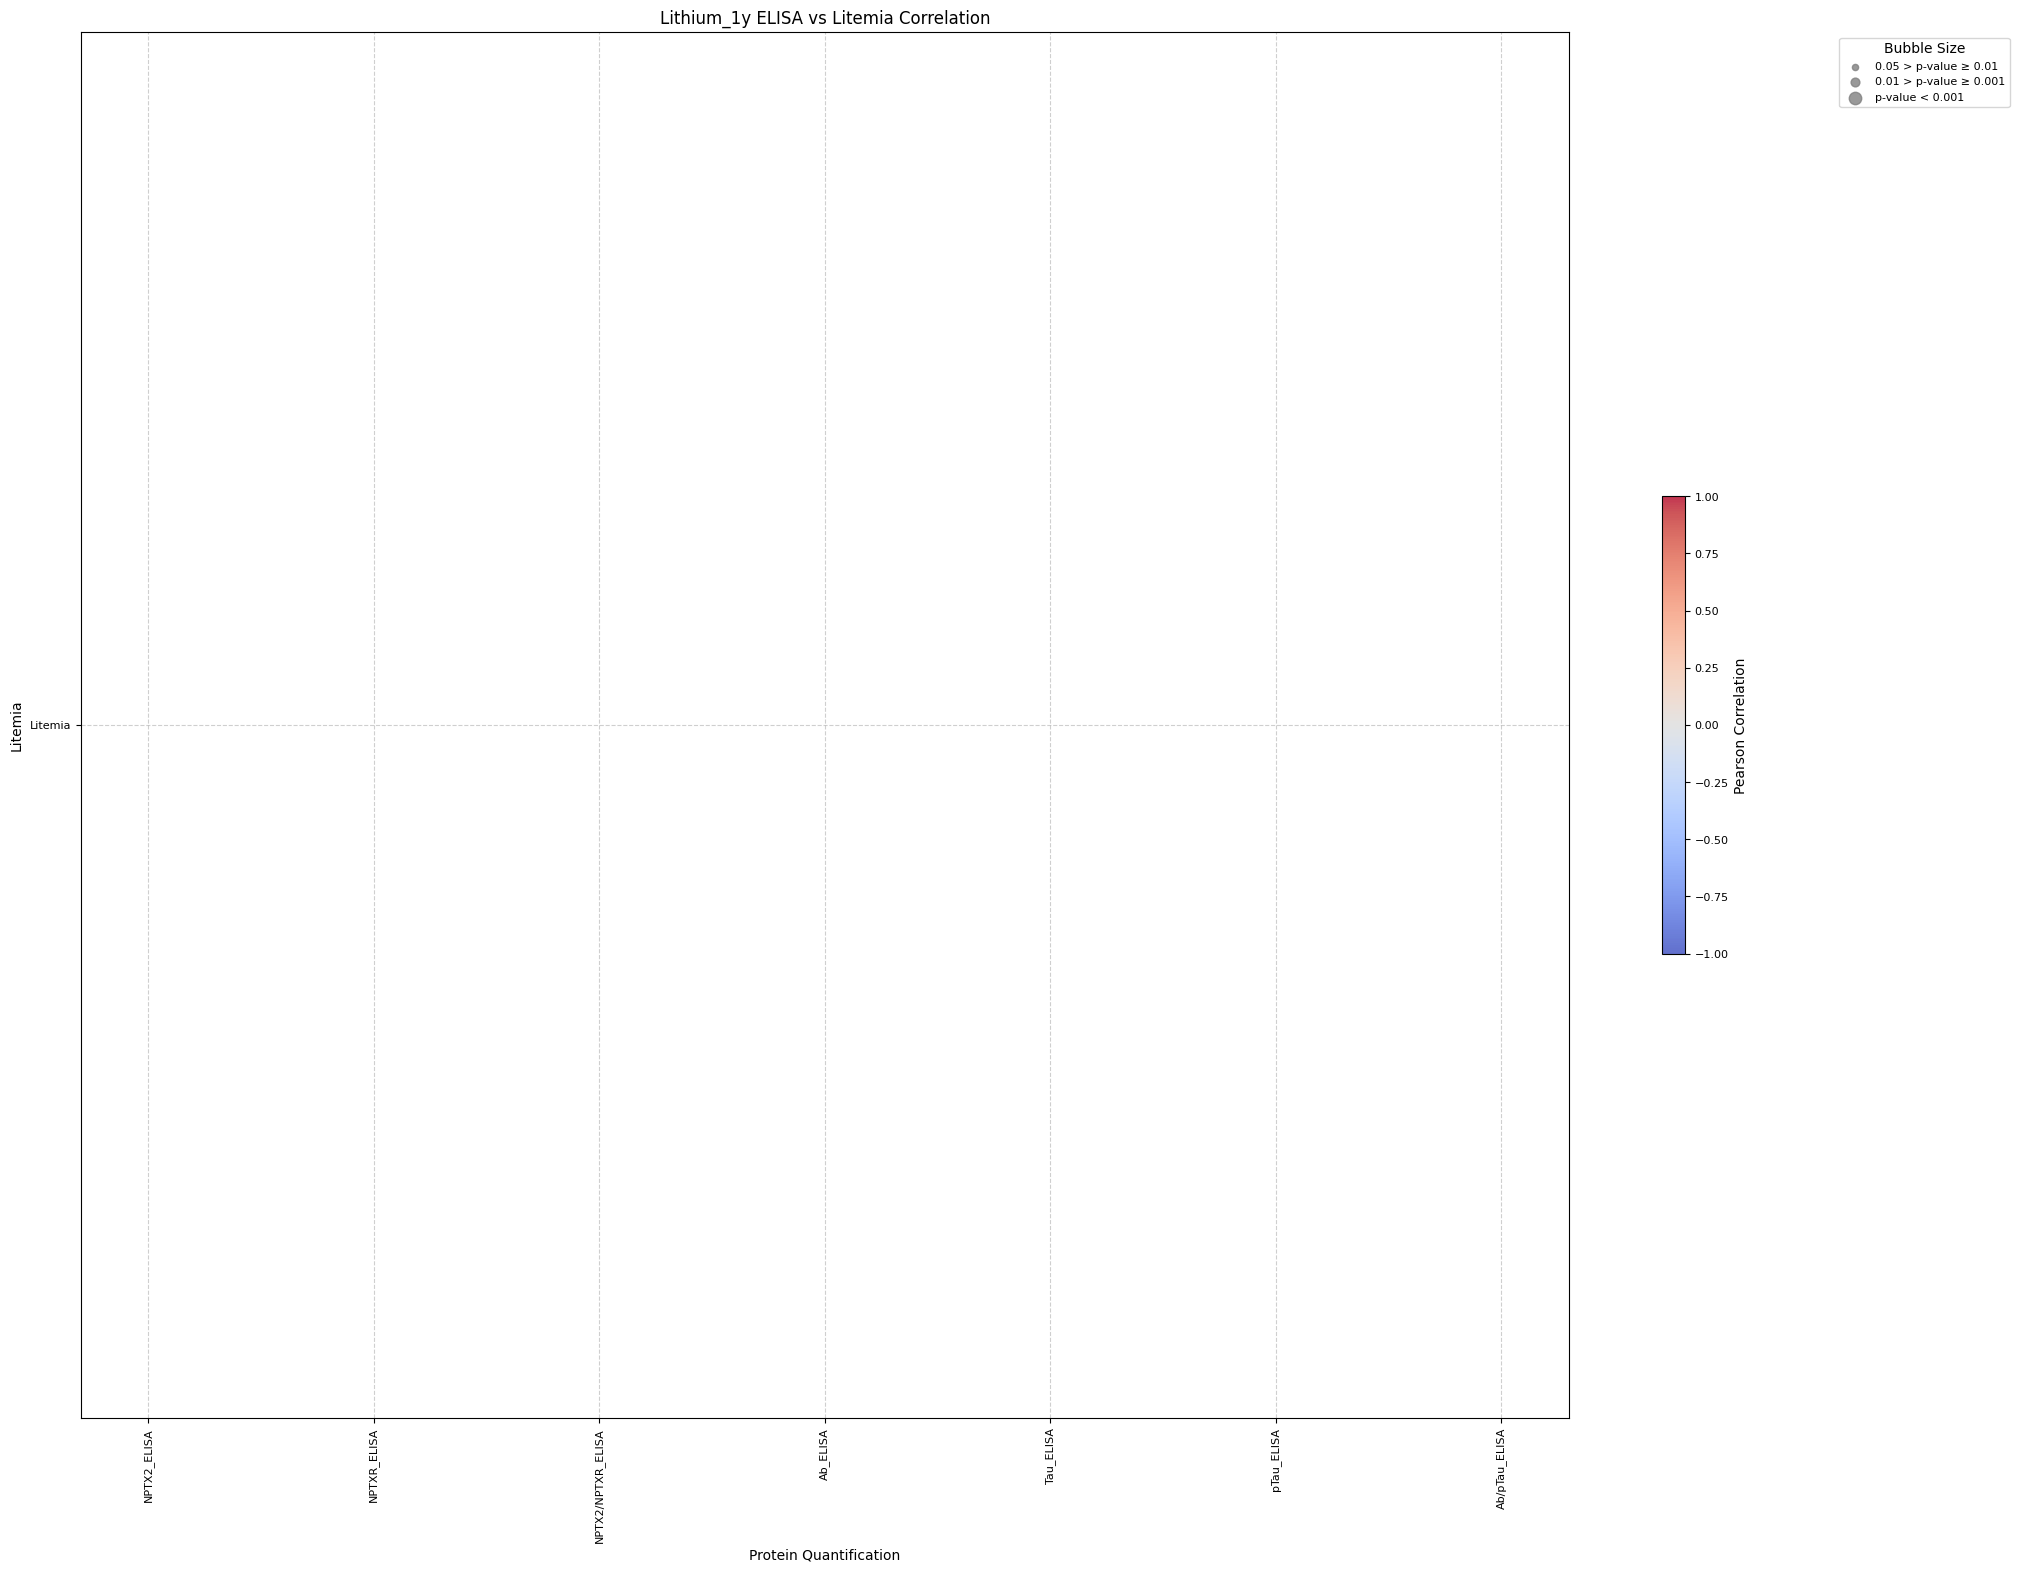

Overall Correlation and p-value Table:
              Variable 1 Variable 2  Correlation   P-value
0          ACHE_NULISA      Litemia     0.084693  0.730300
1          AGRN_NULISA      Litemia     0.315426  0.188358
2         ANXA5_NULISA      Litemia    -0.024439  0.920893
3          APOE_NULISA      Litemia     0.203438  0.403519
4         APOE4_NULISA      Litemia    -0.036287  0.882751
..                   ...        ...          ...       ...
109       YWHAZ_NULISA      Litemia     0.045992  0.851689
110  pTDP43-409_NULISA      Litemia     0.305422  0.203526
111    pTau-181_NULISA      Litemia     0.128849  0.599091
112    pTau-217_NULISA      Litemia     0.135288  0.580796
113    pTau-231_NULISA      Litemia     0.129099  0.598375

[114 rows x 4 columns] 



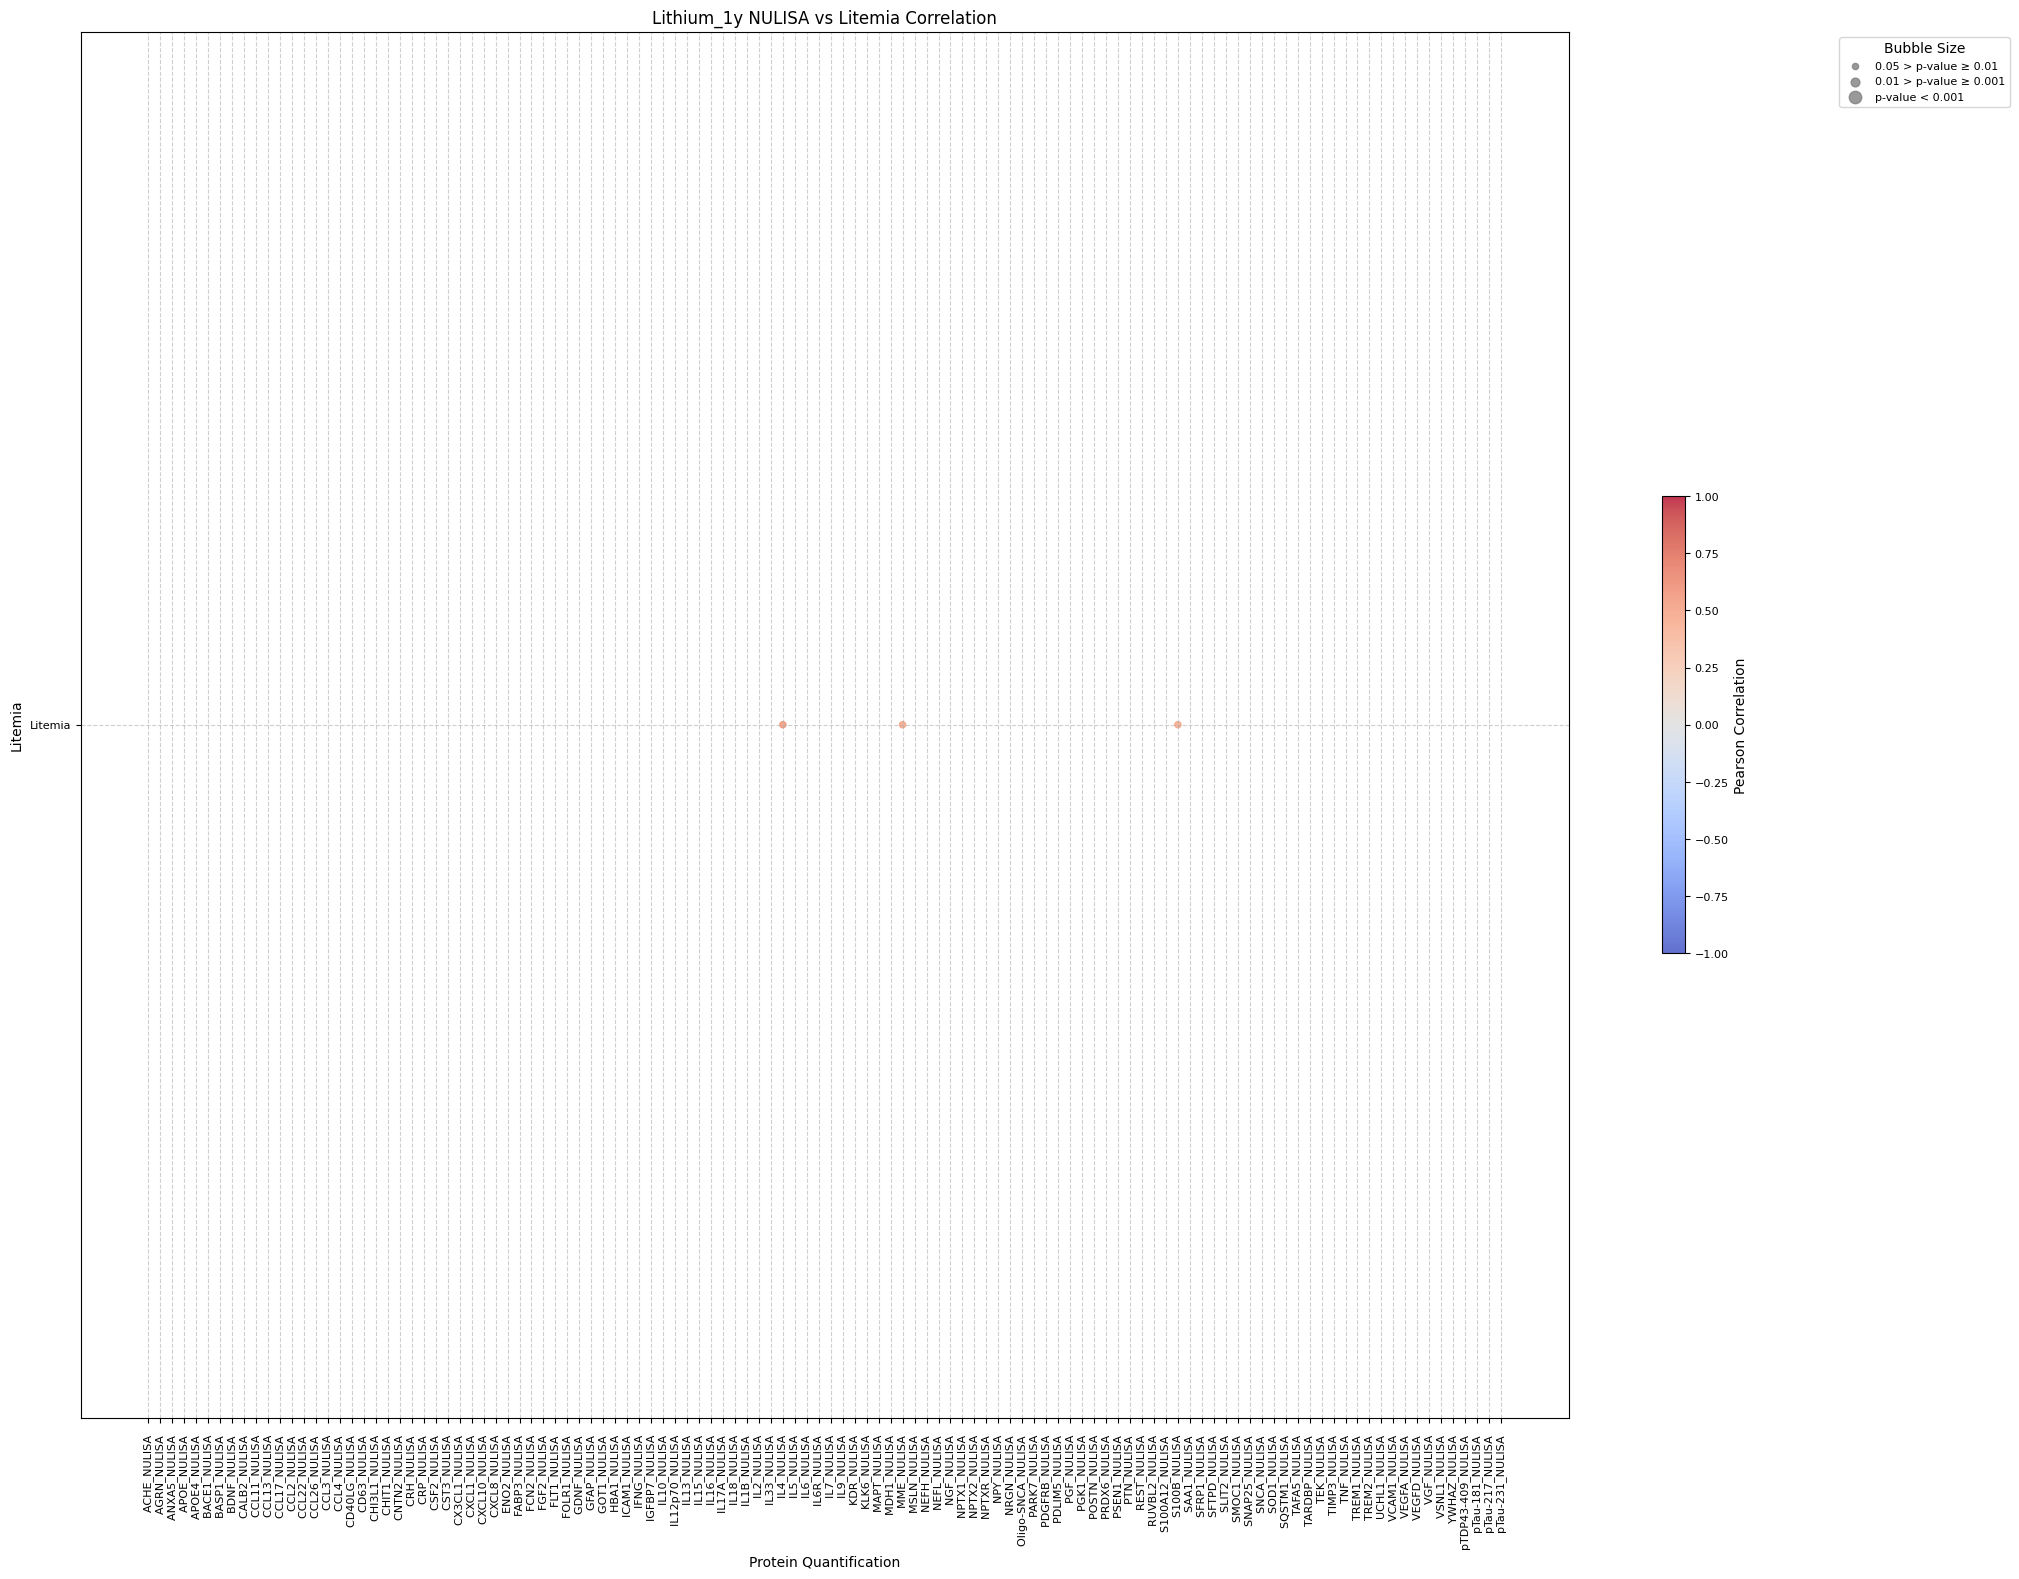

Overall Correlation and p-value Table:
       Variable 1 Variable 2  Correlation   P-value
0     GFRA3_PRM      Litemia     0.240740  0.320795
1      GPC1_PRM      Litemia     0.179860  0.461240
2     NEGR1_PRM      Litemia     0.389685  0.099100
3   RTN4RL2_PRM      Litemia     0.350009  0.141829
4     GRIA4_PRM      Litemia     0.349534  0.142407
5    CARTPT_PRM      Litemia     0.195209  0.423201
6      ACHE_PRM      Litemia     0.414301  0.077809
7      LY6H_PRM      Litemia     0.183246  0.452702
8     NCAM1_PRM      Litemia     0.368982  0.120038
9     NPTX1_PRM      Litemia     0.395339  0.093874
10    NPTX2_PRM      Litemia     0.255482  0.291122
11    NPTXR_PRM      Litemia     0.286786  0.233883
12     DPP6_PRM      Litemia     0.375614  0.113016
13    SCRN1_PRM      Litemia     0.245830  0.310353
14     C1QA_PRM      Litemia     0.247370  0.307235
15    CNTFR_PRM      Litemia     0.305750  0.203016
16      VGF_PRM      Litemia     0.265608  0.271747
17    TREM2_PRM      Lite

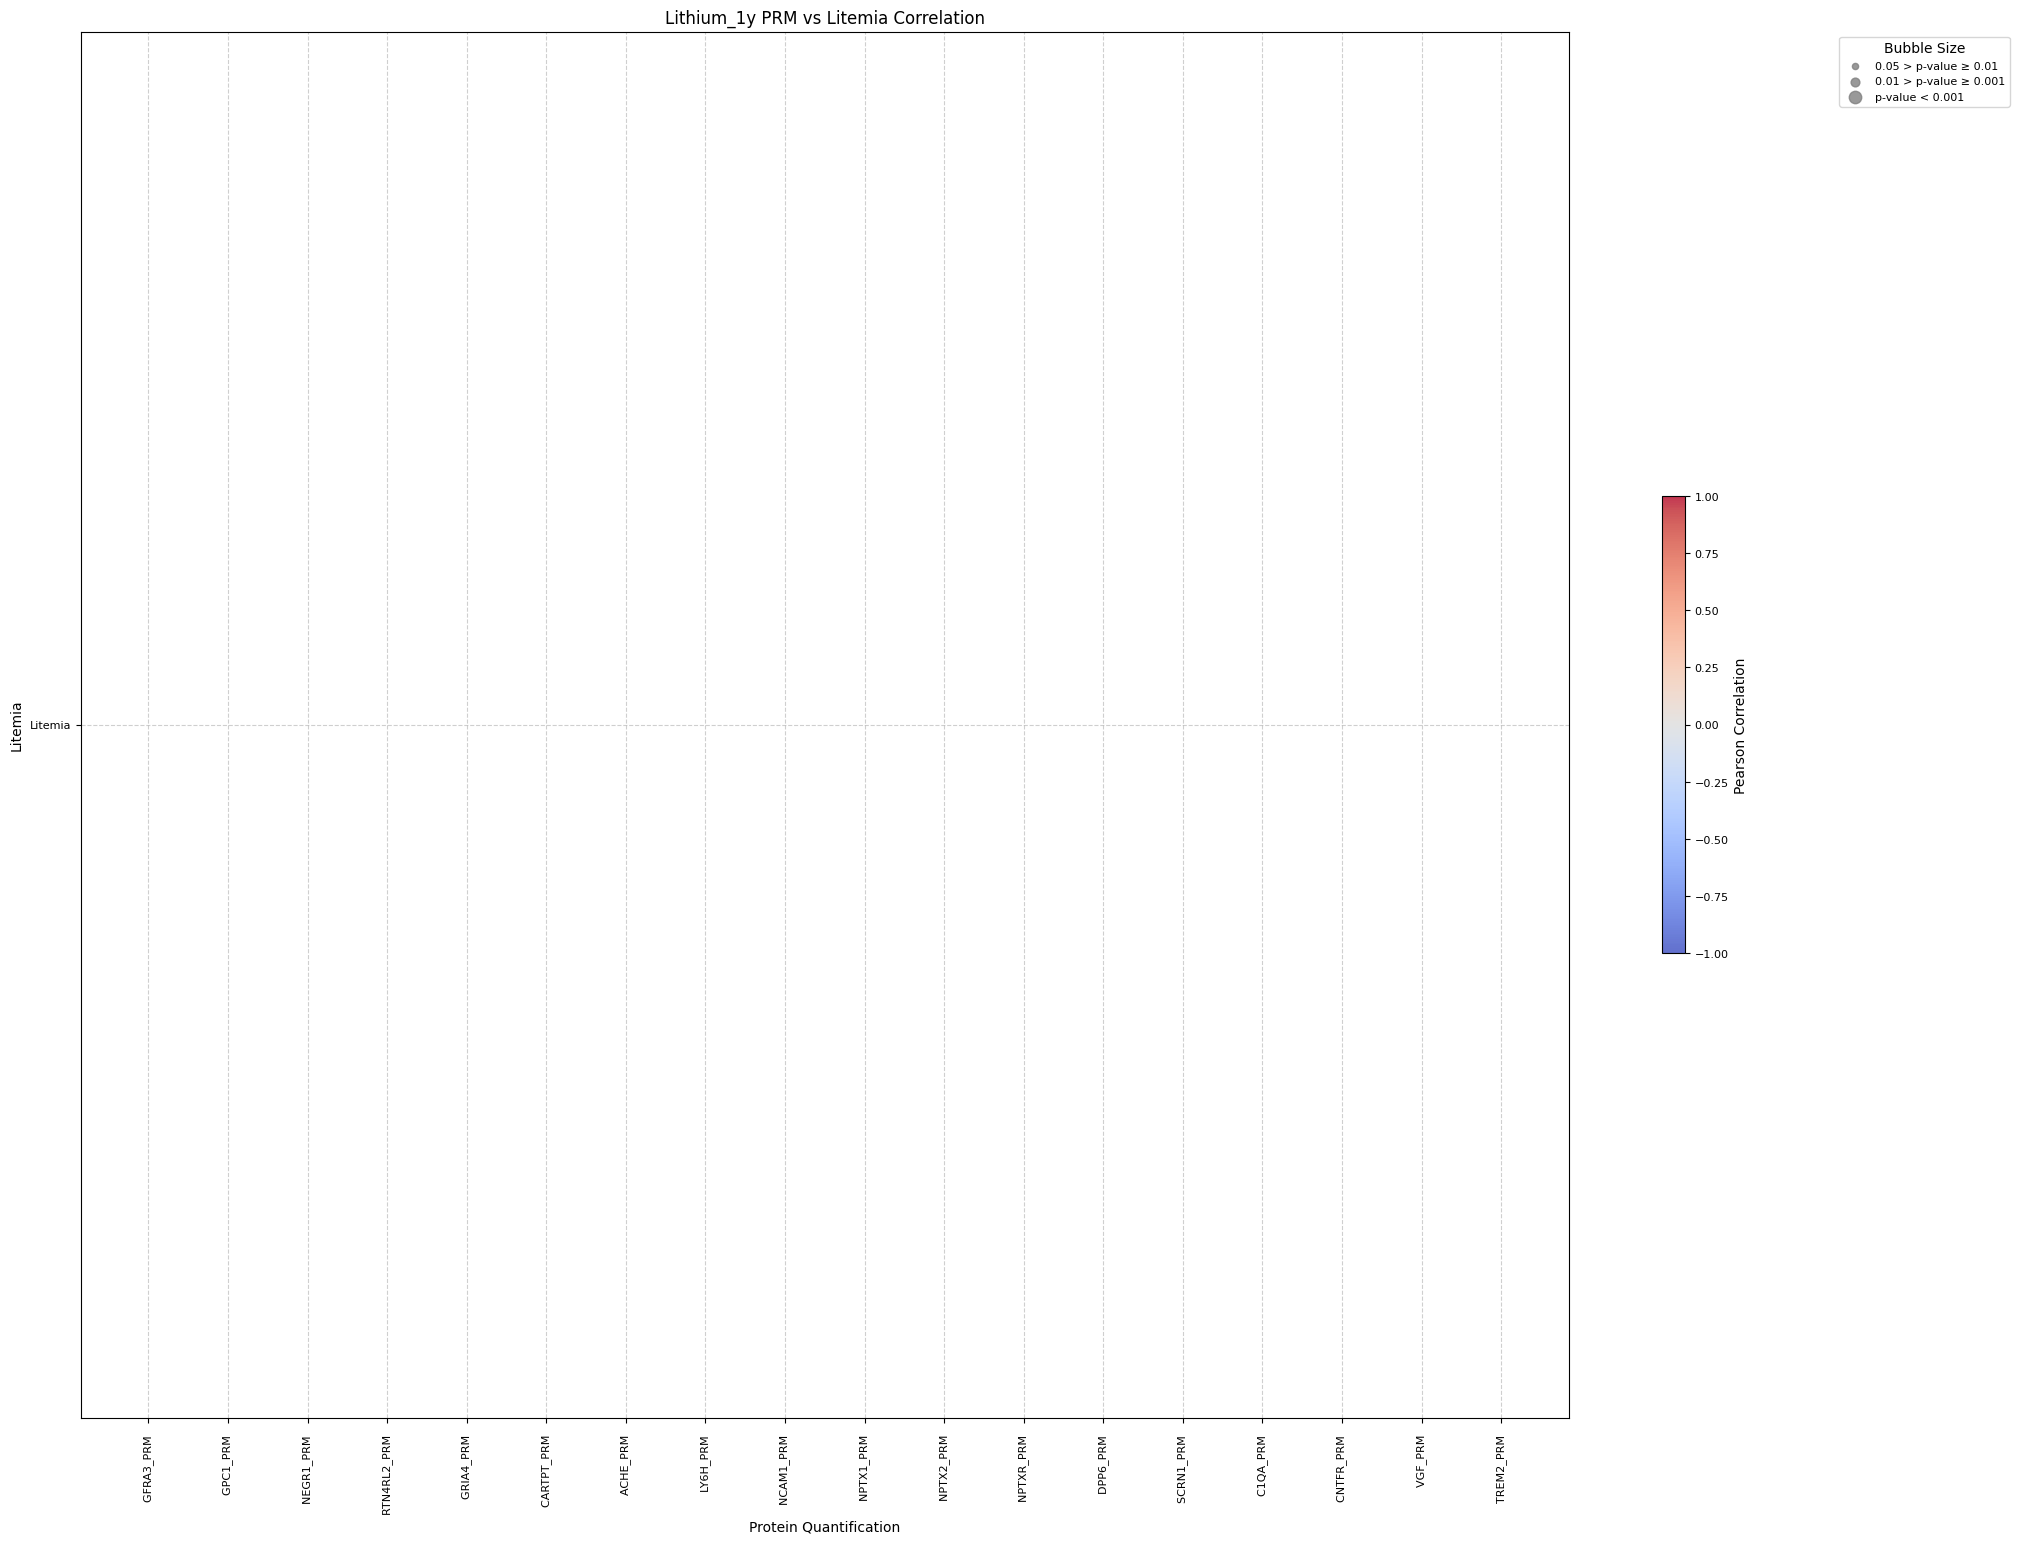

Analyzing group: Lithium_3y
Overall Correlation and p-value Table:
Empty DataFrame
Columns: [Variable 1, Variable 2, Correlation, P-value]
Index: [] 



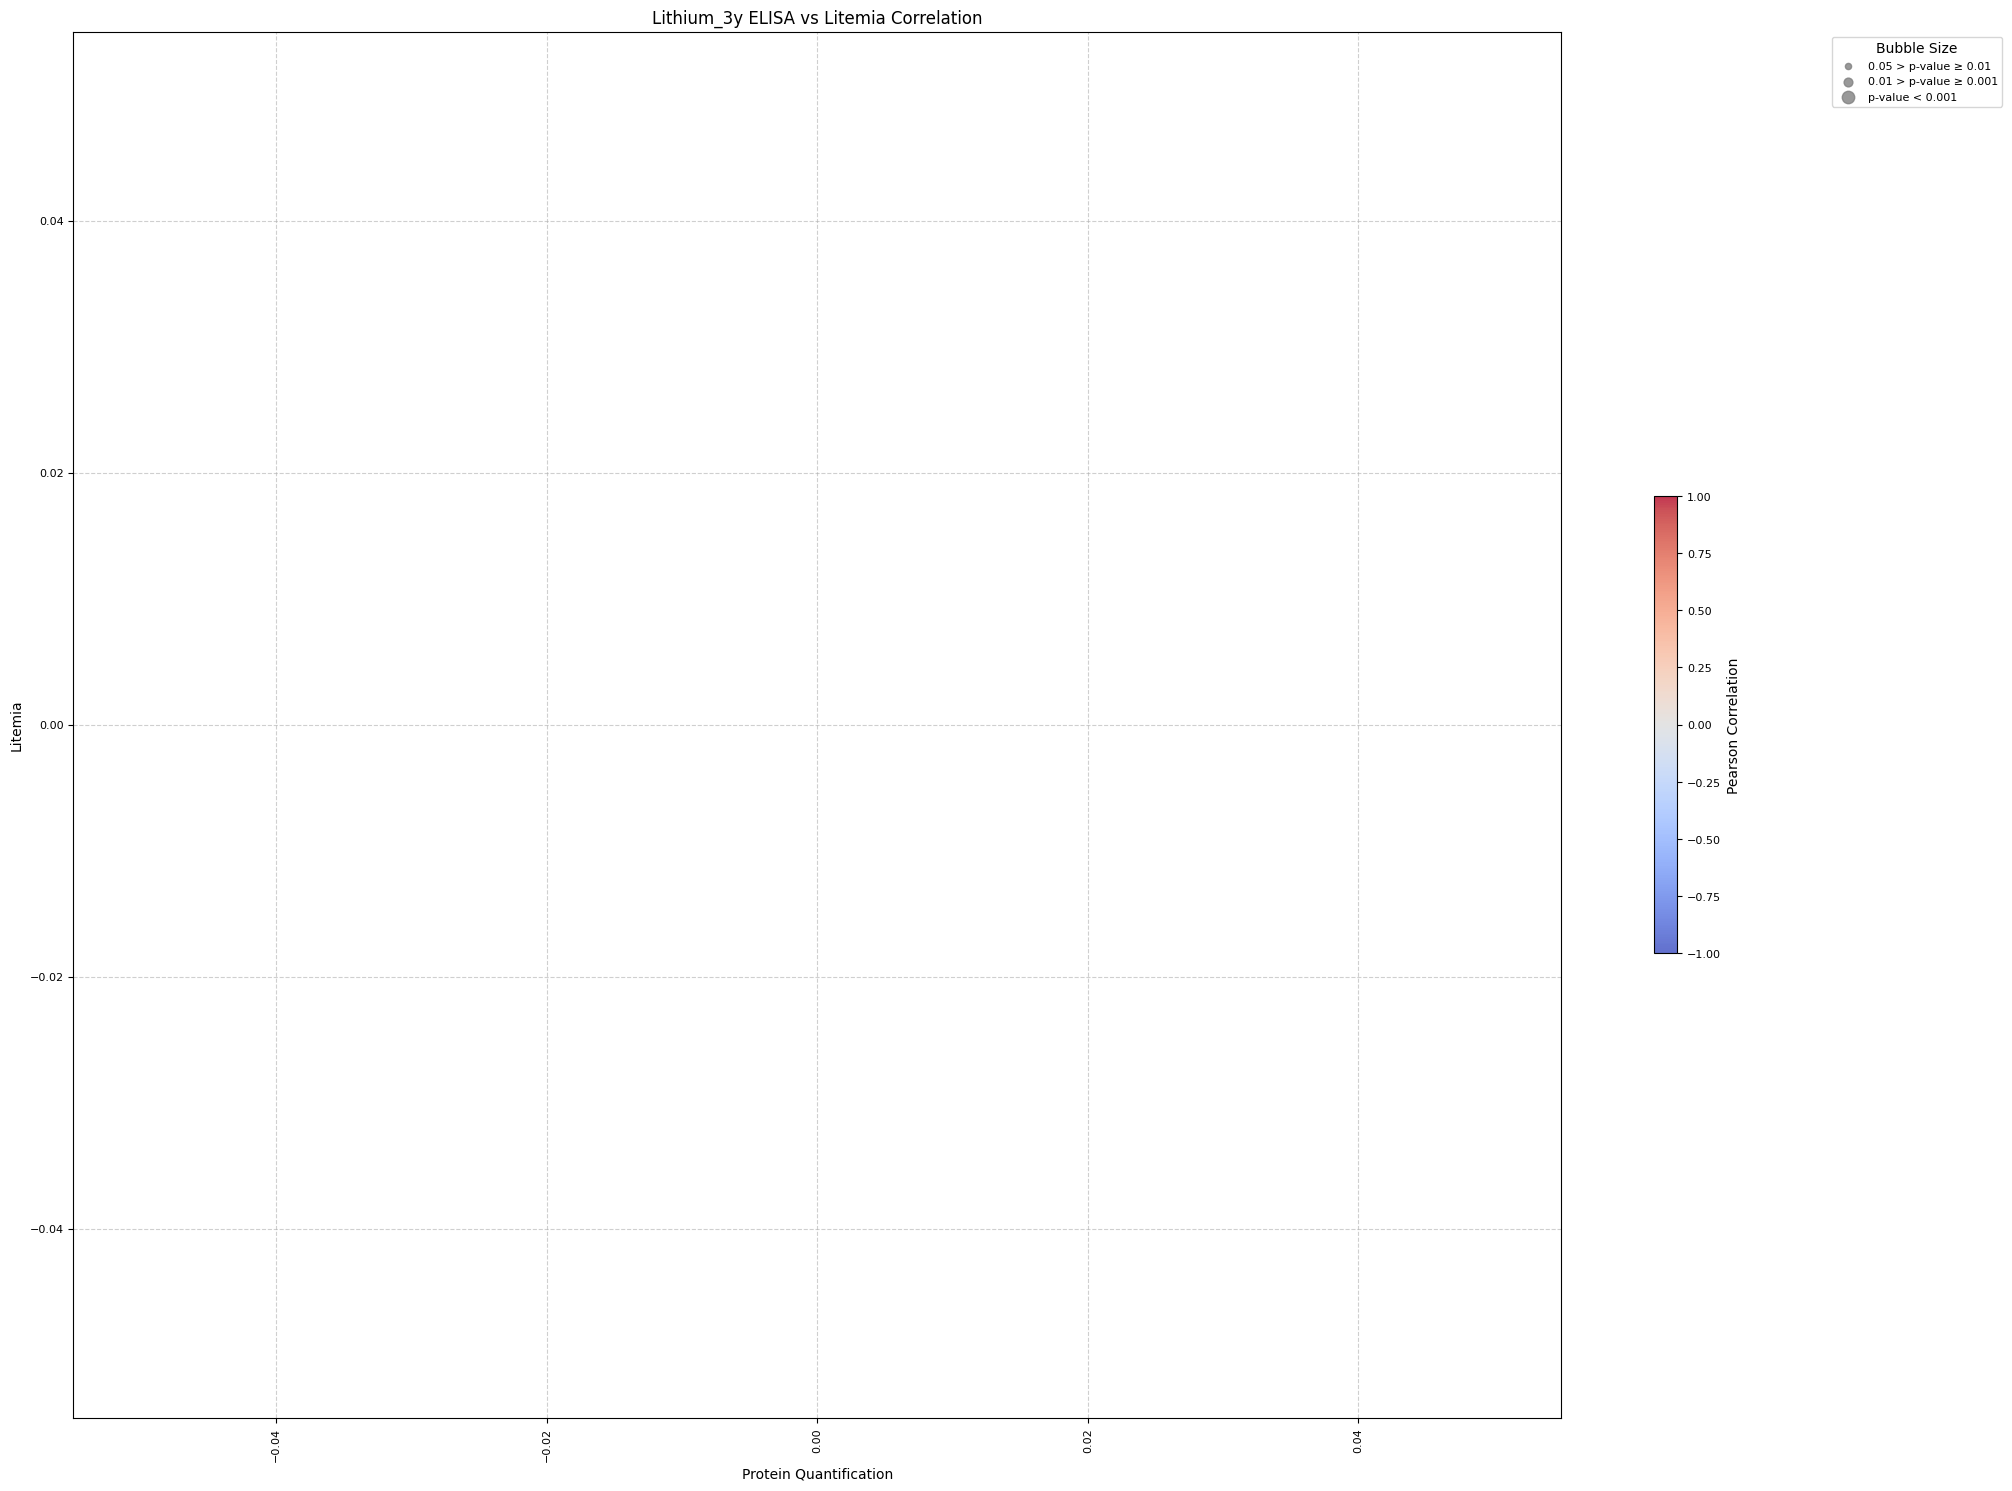

Overall Correlation and p-value Table:
Empty DataFrame
Columns: [Variable 1, Variable 2, Correlation, P-value]
Index: [] 



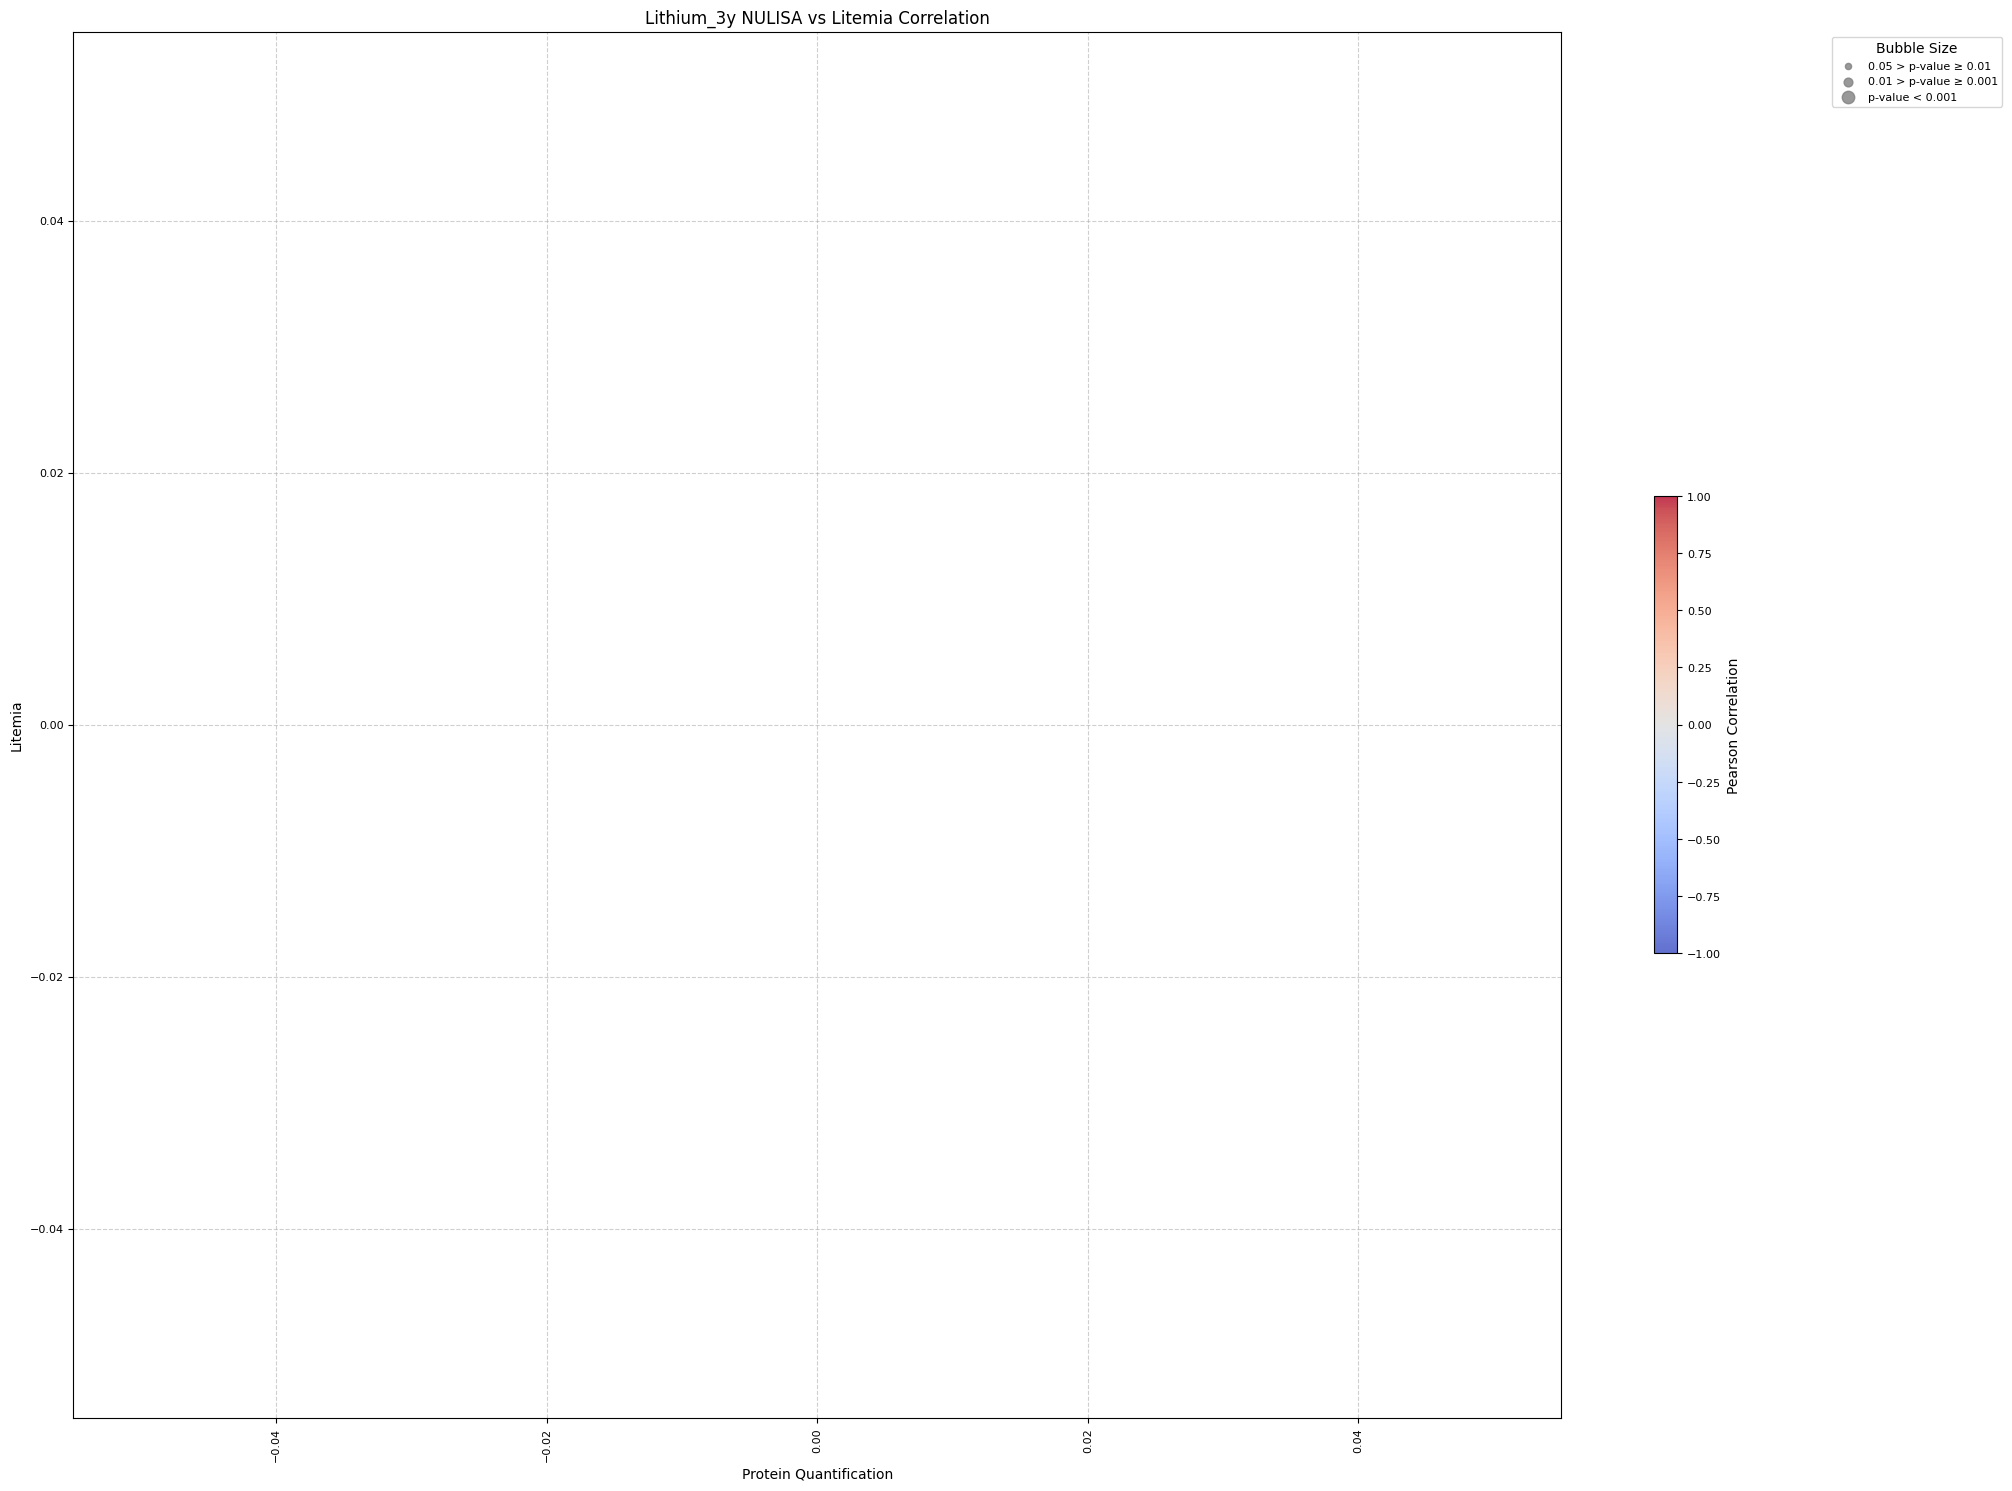

Overall Correlation and p-value Table:
       Variable 1 Variable 2  Correlation   P-value
0     GFRA3_PRM      Litemia     0.447524  0.227091
1      GPC1_PRM      Litemia     0.078946  0.840005
2     NEGR1_PRM      Litemia     0.428644  0.249668
3   RTN4RL2_PRM      Litemia     0.388231  0.301826
4     GRIA4_PRM      Litemia     0.253959  0.509645
5    CARTPT_PRM      Litemia     0.324297  0.394542
6      ACHE_PRM      Litemia     0.464019  0.208317
7      LY6H_PRM      Litemia     0.510322  0.160404
8     NCAM1_PRM      Litemia     0.574281  0.105836
9     NPTX1_PRM      Litemia     0.267933  0.485779
10    NPTX2_PRM      Litemia     0.173246  0.655775
11    NPTXR_PRM      Litemia     0.197709  0.610121
12     DPP6_PRM      Litemia     0.490498  0.180049
13    SCRN1_PRM      Litemia     0.701791  0.035096
14     C1QA_PRM      Litemia     0.695870  0.037355
15    CNTFR_PRM      Litemia     0.747895  0.020490
16      VGF_PRM      Litemia     0.270580  0.481312
17    TREM2_PRM      Lite

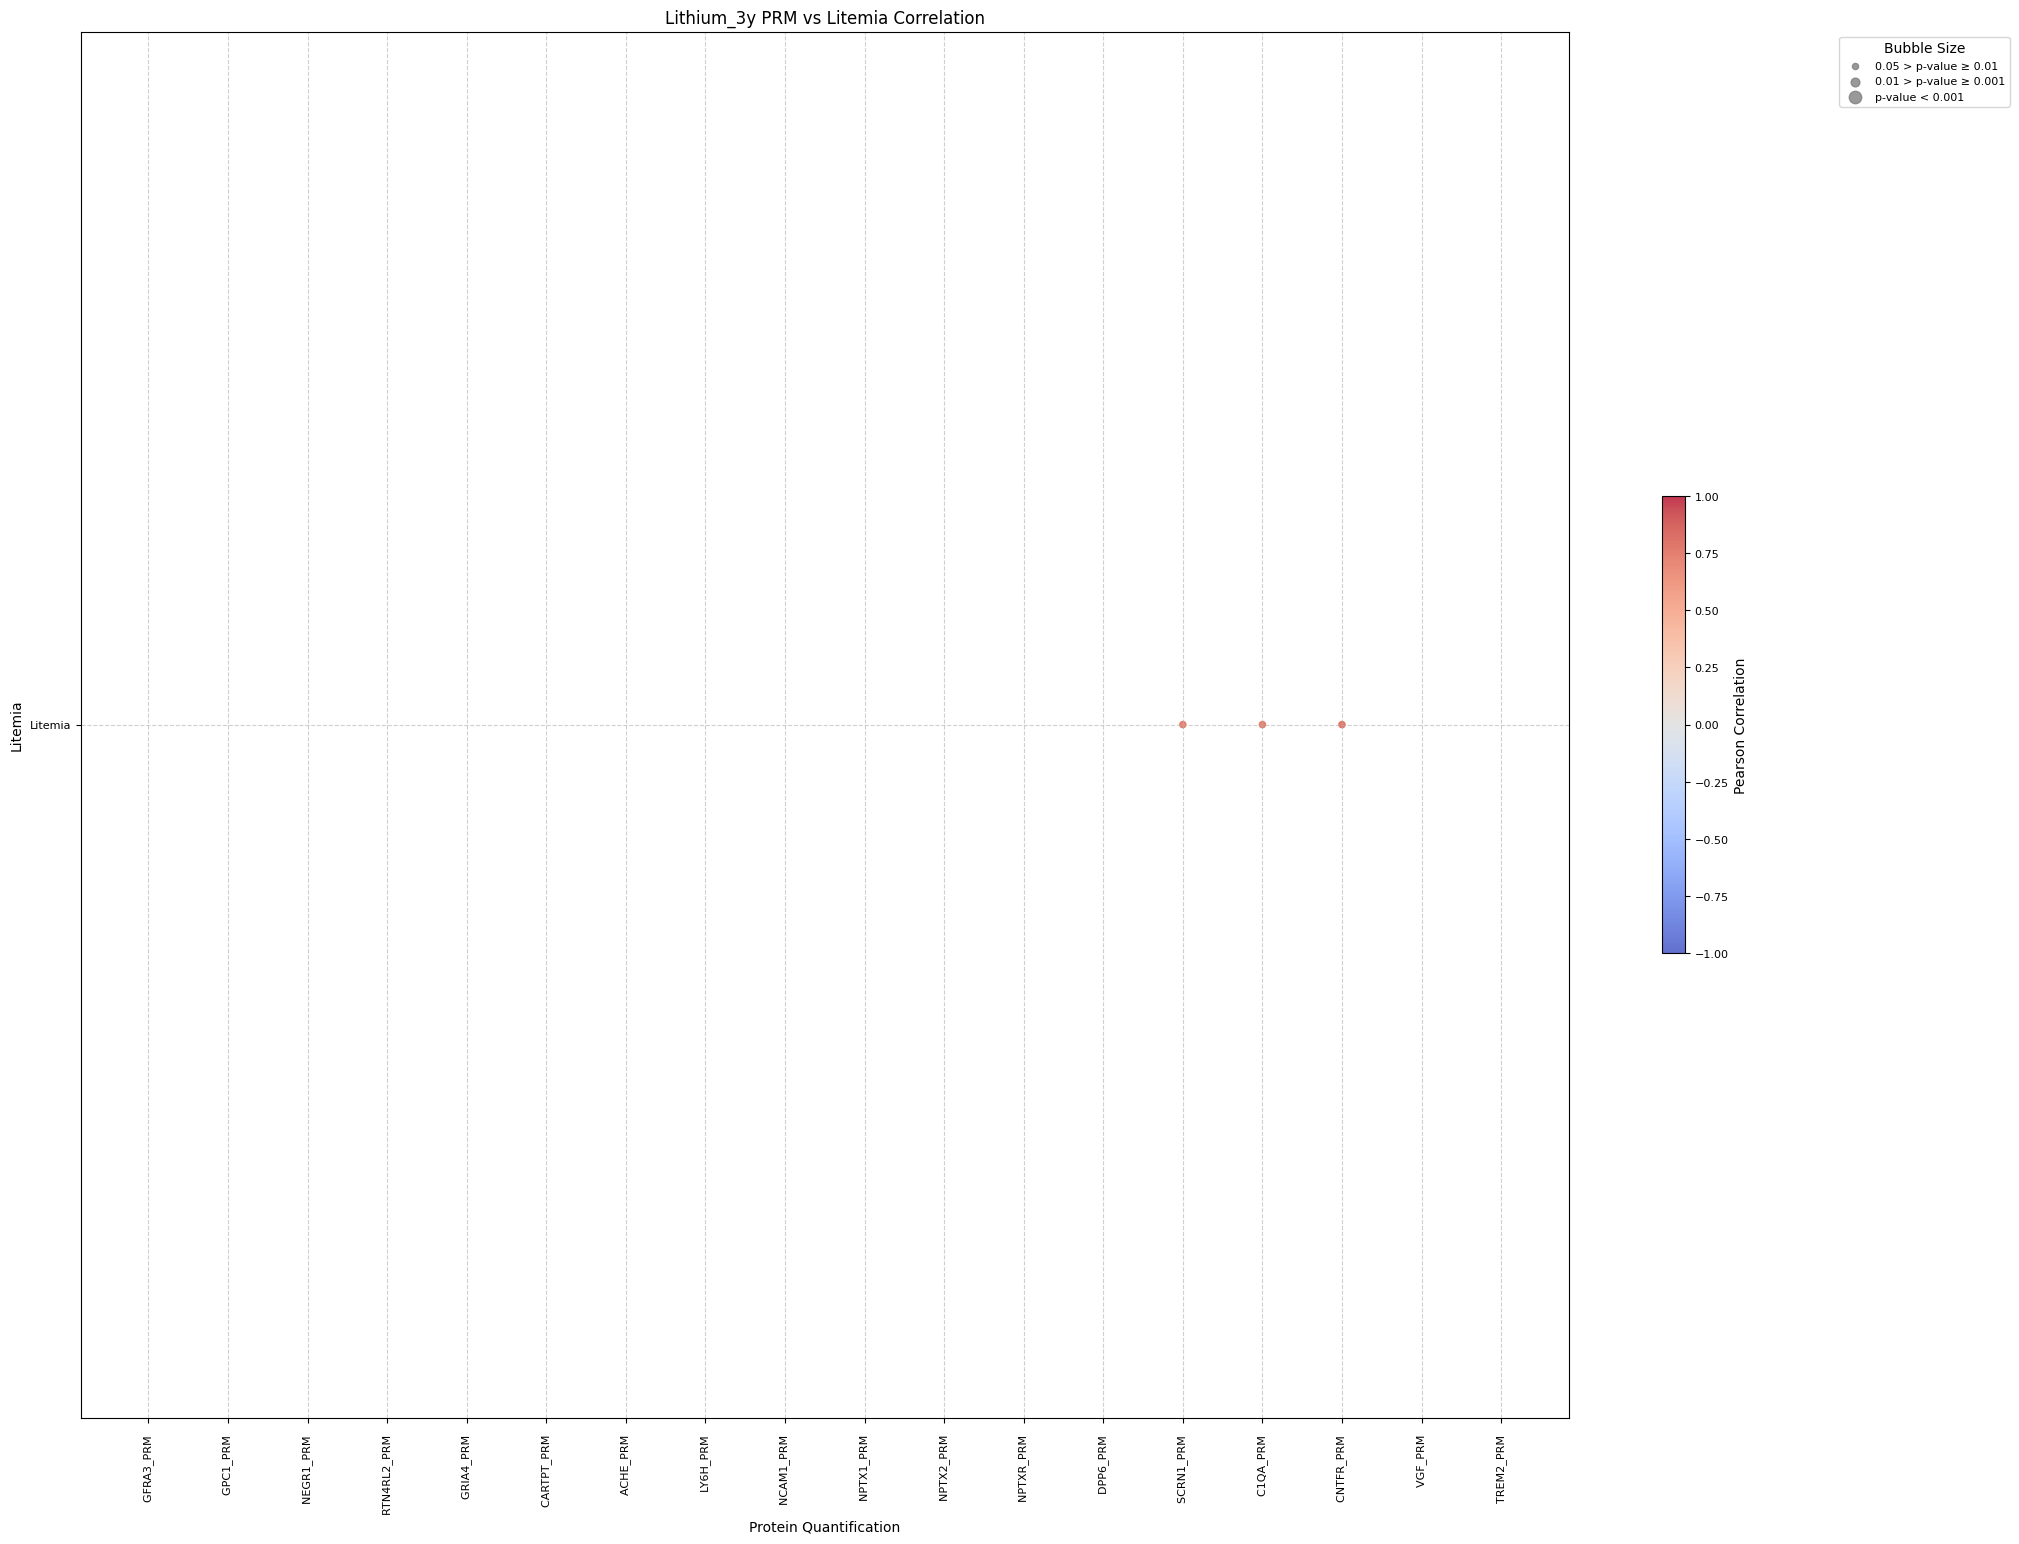

In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import pearsonr
import matplotlib.pyplot as plt

# 데이터프레임(df)이 이미 로드되어 있다고 가정
# Litemia 칼럼과 ELISA, NULISA, PRM 칼럼 분리
litemia_column = 'Litemia'
elisa_columns = [col for col in df.columns if '_ELISA' in col]
nulisa_columns = [col for col in df.columns if '_NULISA' in col]
prm_columns = [col for col in df.columns if '_PRM' in col]

# 그룹 정의 (Lithium_1y와 Lithium_3y만 선택)
groups = {
    'Lithium_1y': df[df['Group'] == 'Lithium_1y'],
    'Lithium_3y': df[df['Group'] == 'Lithium_3y']
}

# 상관관계 계산 함수
def calculate_cross_correlation(df1, df2):
    # 두 데이터프레임의 공통 행만 선택
    common_index = df1.index.intersection(df2.index)
    df1_common = df1.loc[common_index]
    df2_common = df2.loc[common_index]

    # Ensure all columns are numeric
    df1_common = df1_common.apply(pd.to_numeric, errors='coerce')
    df2_common = df2_common.apply(pd.to_numeric, errors='coerce')

    corr_matrix = np.zeros((len(df1_common.columns), len(df2_common.columns)))
    p_matrix = np.zeros((len(df1_common.columns), len(df2_common.columns)))

    for i in range(len(df1_common.columns)):
        for j in range(len(df2_common.columns)):
            # Drop NA values for the current pair of columns
            valid_indices = df1_common.iloc[:, i].notna() & df2_common.iloc[:, j].notna()
            if valid_indices.sum() > 1:  # Ensure there are enough valid pairs
                corr, p_value = pearsonr(df1_common.iloc[:, i][valid_indices], df2_common.iloc[:, j][valid_indices])
                corr_matrix[i, j] = corr
                p_matrix[i, j] = p_value
            else:
                corr_matrix[i, j] = np.nan
                p_matrix[i, j] = np.nan

    return corr_matrix, p_matrix, df1_common.columns, df2_common.columns

# 시각화 함수 정의 (Bubble Chart)
def plot_bubble_correlation(corr_matrix, p_matrix, x_labels, y_labels, title):
    # 상관계수와 p-value를 하나의 데이터프레임으로 병합
    corr_df = pd.DataFrame(corr_matrix, index=x_labels, columns=y_labels)
    p_df = pd.DataFrame(p_matrix, index=x_labels, columns=y_labels)

    # 상관계수와 p-value를 하나의 데이터프레임으로 병합
    corr_df = corr_df.stack().reset_index()
    corr_df.columns = ['Variable 1', 'Variable 2', 'Correlation']

    p_df = p_df.stack().reset_index()
    p_df.columns = ['Variable 1', 'Variable 2', 'P-value']

    merged_df = pd.merge(corr_df, p_df, on=['Variable 1', 'Variable 2'])

    # p-value에 따라 원의 크기 설정 (3단계로 나눔)
    def get_bubble_size(p_value):
        if p_value < 0.001:
            return 80  # 가장 큰 원
        elif 0.001 <= p_value < 0.01:
            return 40  # 중간 원
        elif 0.01 <= p_value < 0.05:
            return 20  # 가장 작은 원
        else:
            return 0  # 0.05 이상인 경우 표시하지 않음

    # 원의 크기 계산
    merged_df['Bubble Size'] = merged_df['P-value'].apply(get_bubble_size)

    # 그림 크기 설정 (크게 조정)
    plt.figure(figsize=(24, 18))  # 그림 크기를 24x18로 늘림

    # 폰트 설정 (Arial과 비슷한 sans-serif 폰트 사용)
    plt.rcParams['font.family'] = 'sans-serif'
    plt.rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans', 'Helvetica', 'Lucida Grande', 'Verdana']
    plt.rcParams['font.size'] = 10  # 기본 폰트 크기 줄임
    plt.rcParams['axes.titlesize'] = 12  # 제목 폰트 크기 줄임
    plt.rcParams['axes.labelsize'] = 10  # 축 레이블 폰트 크기 줄임
    plt.rcParams['xtick.labelsize'] = 8  # x축 틱 폰트 크기 줄임
    plt.rcParams['ytick.labelsize'] = 8  # y축 틱 폰트 크기 줄임

    # Bubble Chart 그리기
    scatter = plt.scatter(
        x=merged_df['Variable 1'],  # x 좌표 (변수 1)
        y=merged_df['Variable 2'],  # y 좌표 (변수 2)
        s=merged_df['Bubble Size'],  # 원의 크기 (p-value에 따라 3단계로 설정)
        c=merged_df['Correlation'],  # 원의 색상 (상관계수)
        cmap='coolwarm',  # 색상 맵: -1(파란색) ~ 1(빨간색)
        vmin=-1,
        vmax=1,
        alpha=0.8  # 투명도
    )

    # 색상 바 추가 (크기 축소)
    cbar = plt.colorbar(scatter, shrink=0.33)  # 크기 축소
    cbar.set_label('Pearson Correlation', fontsize=10)  # 색상바 레이블 폰트 크기 줄임

    # 축 레이블 및 제목 설정
    plt.xlabel('Protein Quantification', fontsize=10)
    plt.ylabel('Litemia', fontsize=10)
    plt.title(title, fontsize=12)

    # x축과 y축의 라벨 회전
    plt.xticks(rotation=90)
    plt.yticks(rotation=0)

    # 그리드 추가
    plt.grid(True, linestyle='--', alpha=0.6)

    # 범례 추가 (원의 크기 설명)
    for pvalue_range, size in zip(
        ['0.05 > p-value ≥ 0.01', '0.01 > p-value ≥ 0.001', 'p-value < 0.001'],  # 범례 설명 수정
        [20, 40, 80]  # 원의 크기
    ):
        plt.scatter([], [], s=size, c='gray', alpha=0.8, label=pvalue_range)  # 범례 설명 적용
    plt.legend(title='Bubble Size', loc='upper right', bbox_to_anchor=(1.3, 1), fontsize=8)  # 범례 폰트 크기 줄임

    # Pearson 상관계수와 p-value 테이블 출력
    print(f"Overall Correlation and p-value Table:")
    print(merged_df[['Variable 1', 'Variable 2', 'Correlation', 'P-value']].dropna(), "\n")

    # Excel로 테이블 저장
    merged_df[['Variable 1', 'Variable 2', 'Correlation', 'P-value']].dropna().to_excel(
        f"../data/output/{title}_correlation_table.xlsx", index=False)

    # PDF로 저장
    plt.savefig(f'{title}_bubble_chart.pdf', format='pdf', bbox_inches='tight')
    plt.show()

# 각 그룹별로 Litemia와 ELISA, NULISA, PRM 간의 상관관계 분석
for group_name, group_data in groups.items():
    print(f"Analyzing group: {group_name}")

    # 데이터 정제
    group_elisa = group_data[elisa_columns].dropna()
    group_nulisa = group_data[nulisa_columns].dropna()
    group_prm = group_data[prm_columns].dropna()
    group_litemia = group_data[[litemia_column]].dropna()

    # ELISA vs Litemia
    elisa_litemia_corr, elisa_litemia_p, elisa_labels, _ = calculate_cross_correlation(group_elisa, group_litemia)
    plot_bubble_correlation(elisa_litemia_corr, elisa_litemia_p, elisa_labels, [litemia_column], title=f'{group_name} ELISA vs Litemia Correlation')

    # NULISA vs Litemia
    nulisa_litemia_corr, nulisa_litemia_p, nulisa_labels, _ = calculate_cross_correlation(group_nulisa, group_litemia)
    plot_bubble_correlation(nulisa_litemia_corr, nulisa_litemia_p, nulisa_labels, [litemia_column], title=f'{group_name} NULISA vs Litemia Correlation')

    # PRM vs Litemia
    prm_litemia_corr, prm_litemia_p, prm_labels, _ = calculate_cross_correlation(group_prm, group_litemia)
    plot_bubble_correlation(prm_litemia_corr, prm_litemia_p, prm_labels, [litemia_column], title=f'{group_name} PRM vs Litemia Correlation')

Analyzing group: Placebo_1y
Overall Correlation and p-value Table:
Empty DataFrame
Columns: [Variable 1, Variable 2, Correlation, P-value]
Index: [] 



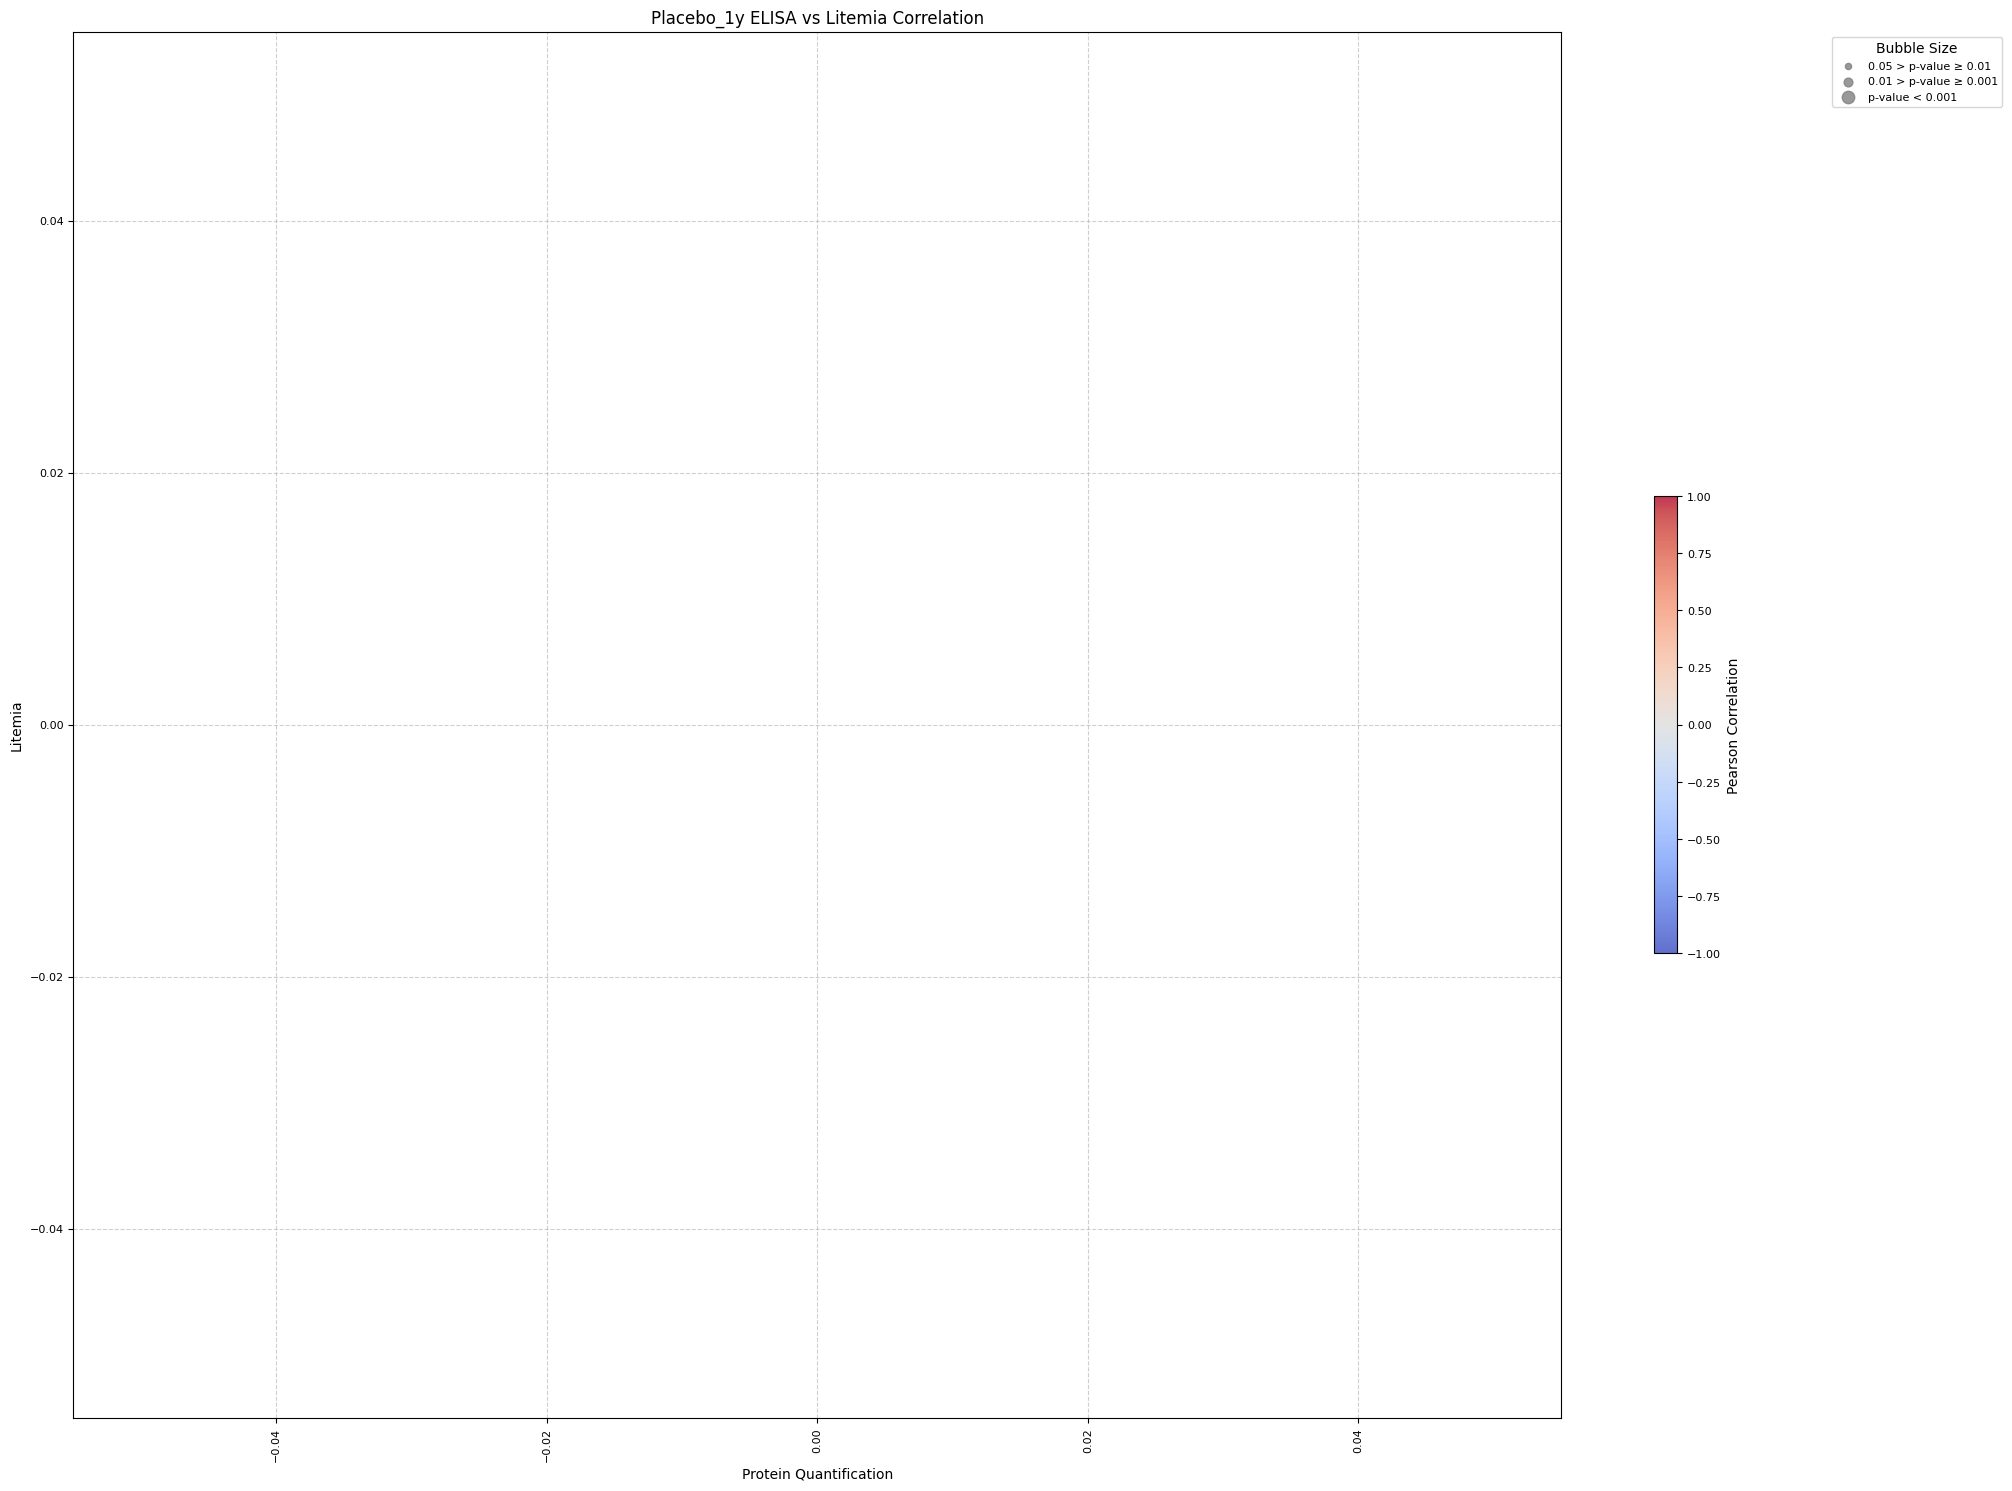

Overall Correlation and p-value Table:
Empty DataFrame
Columns: [Variable 1, Variable 2, Correlation, P-value]
Index: [] 



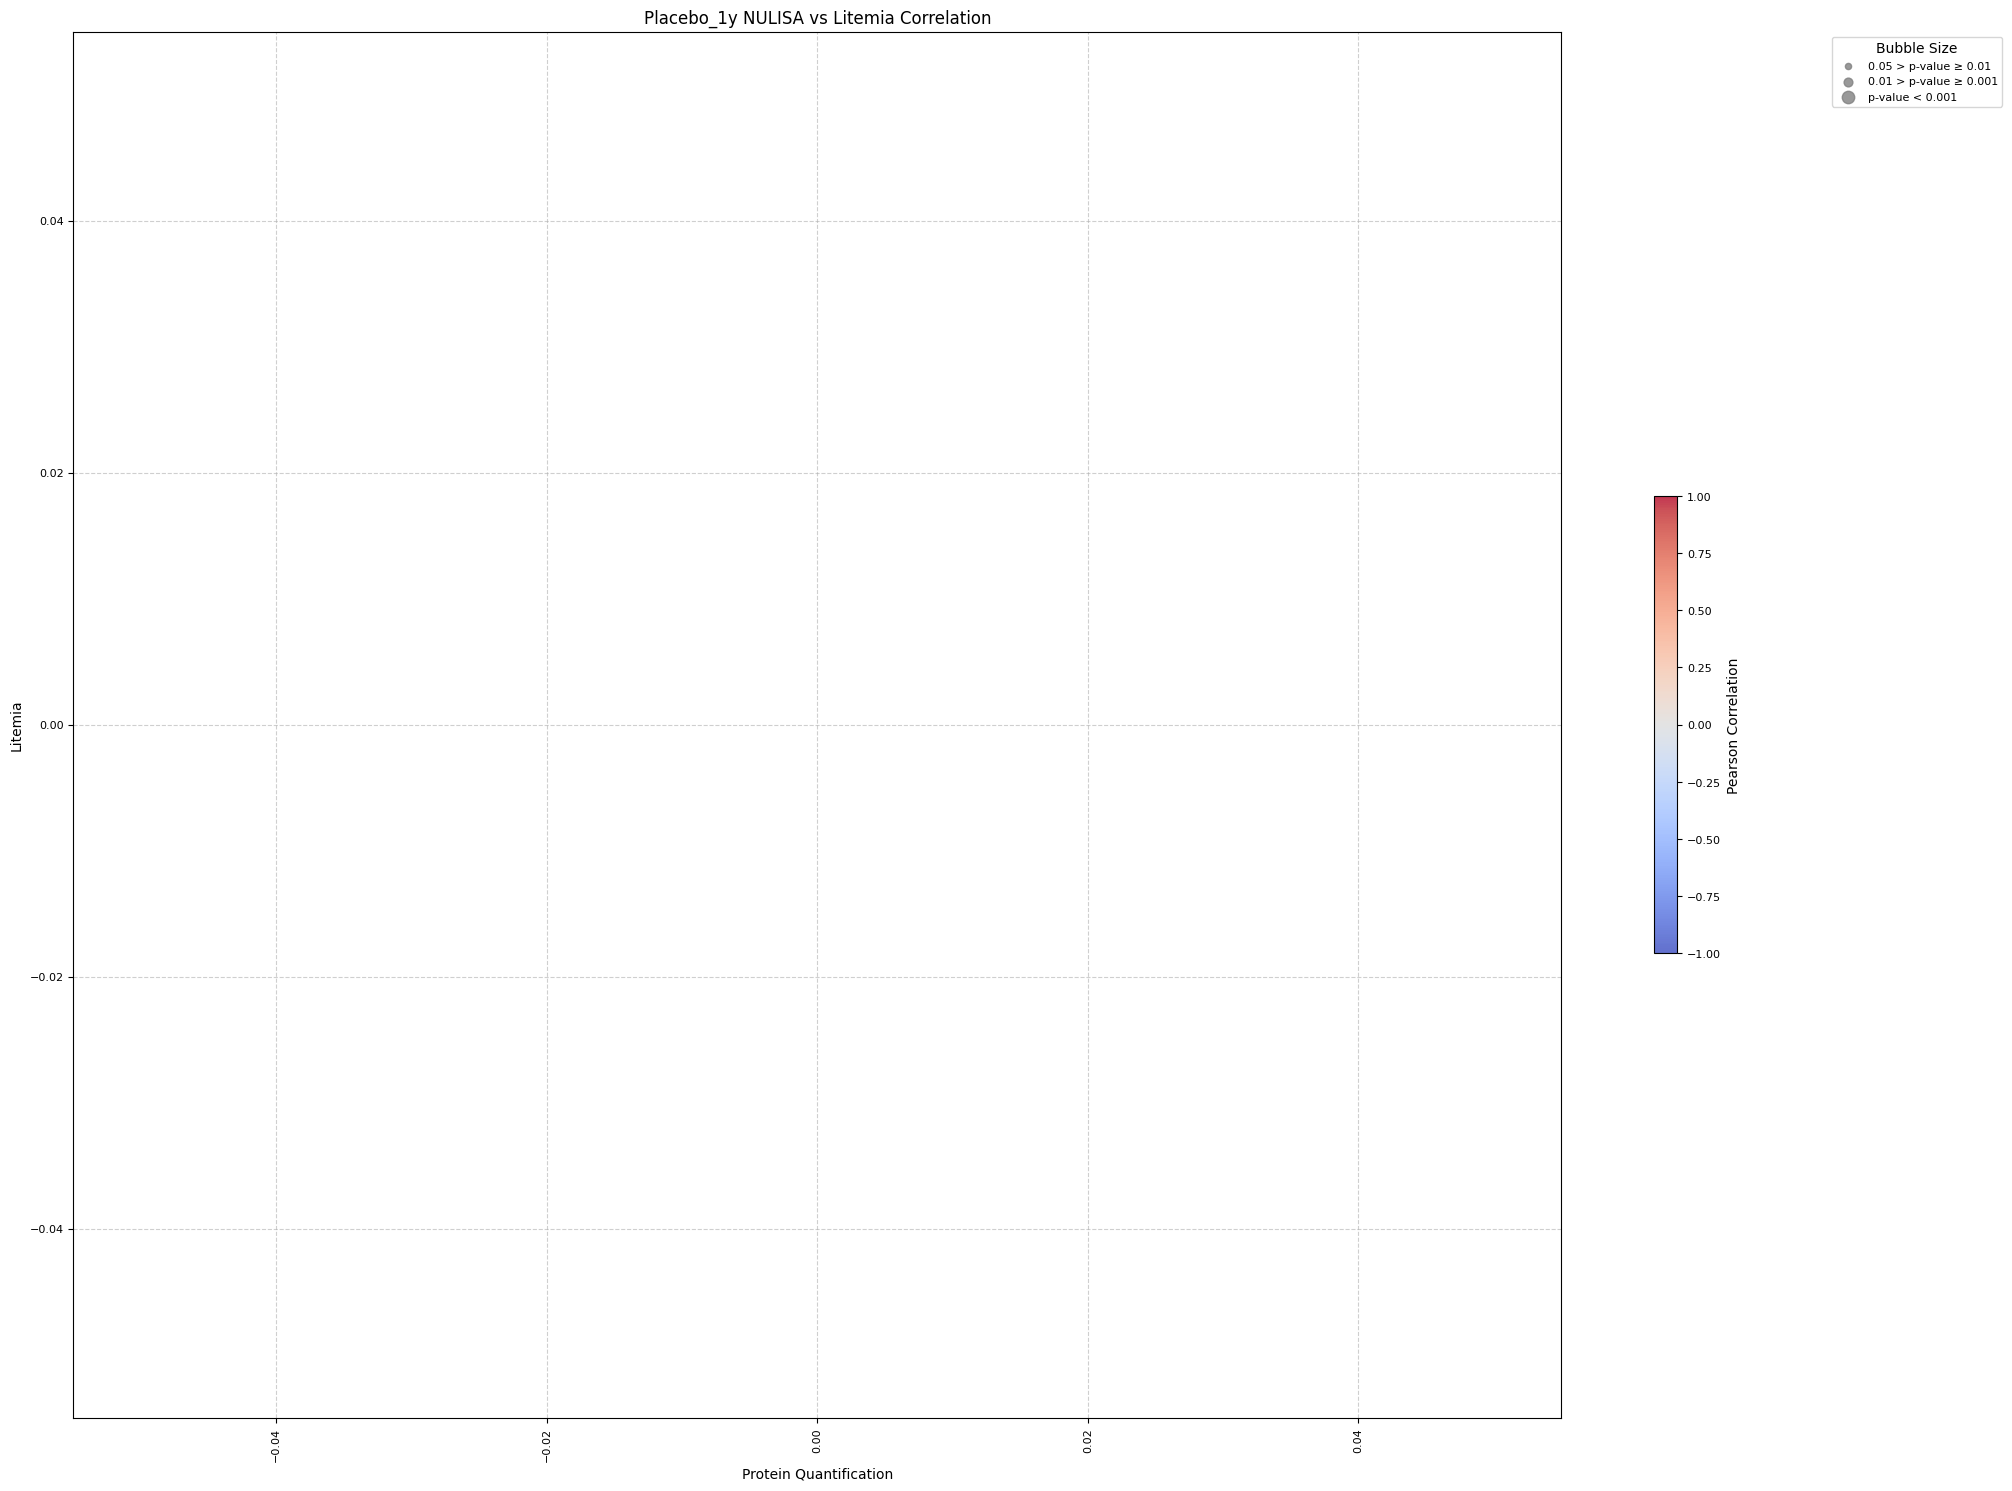

Overall Correlation and p-value Table:
Empty DataFrame
Columns: [Variable 1, Variable 2, Correlation, P-value]
Index: [] 



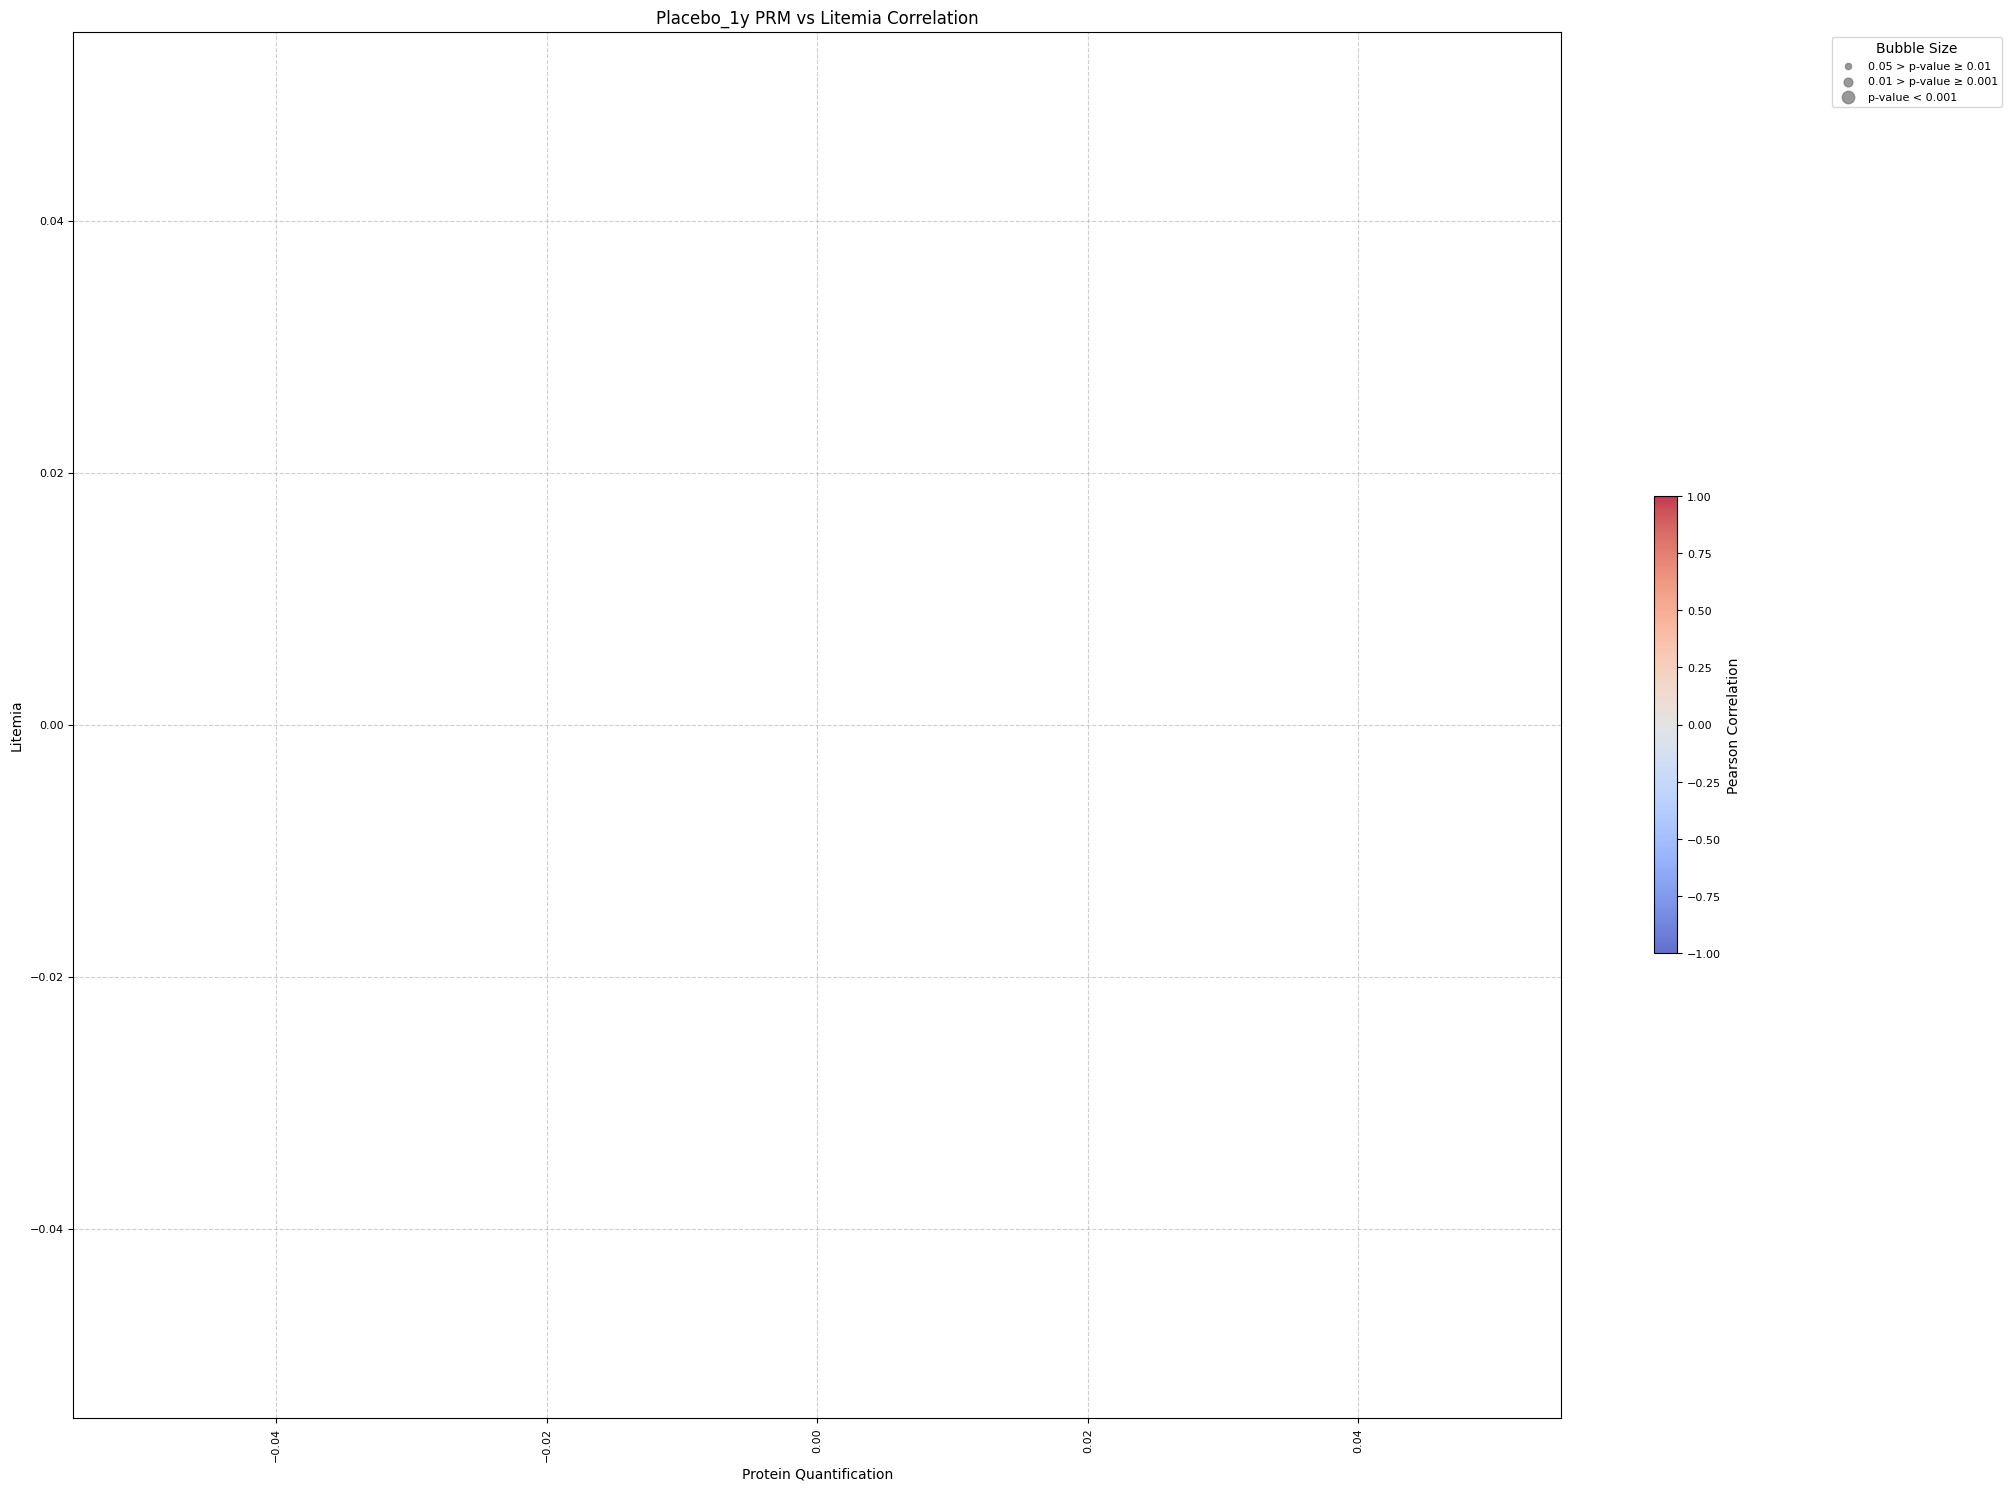

Analyzing group: Placebo_3y
Overall Correlation and p-value Table:
Empty DataFrame
Columns: [Variable 1, Variable 2, Correlation, P-value]
Index: [] 



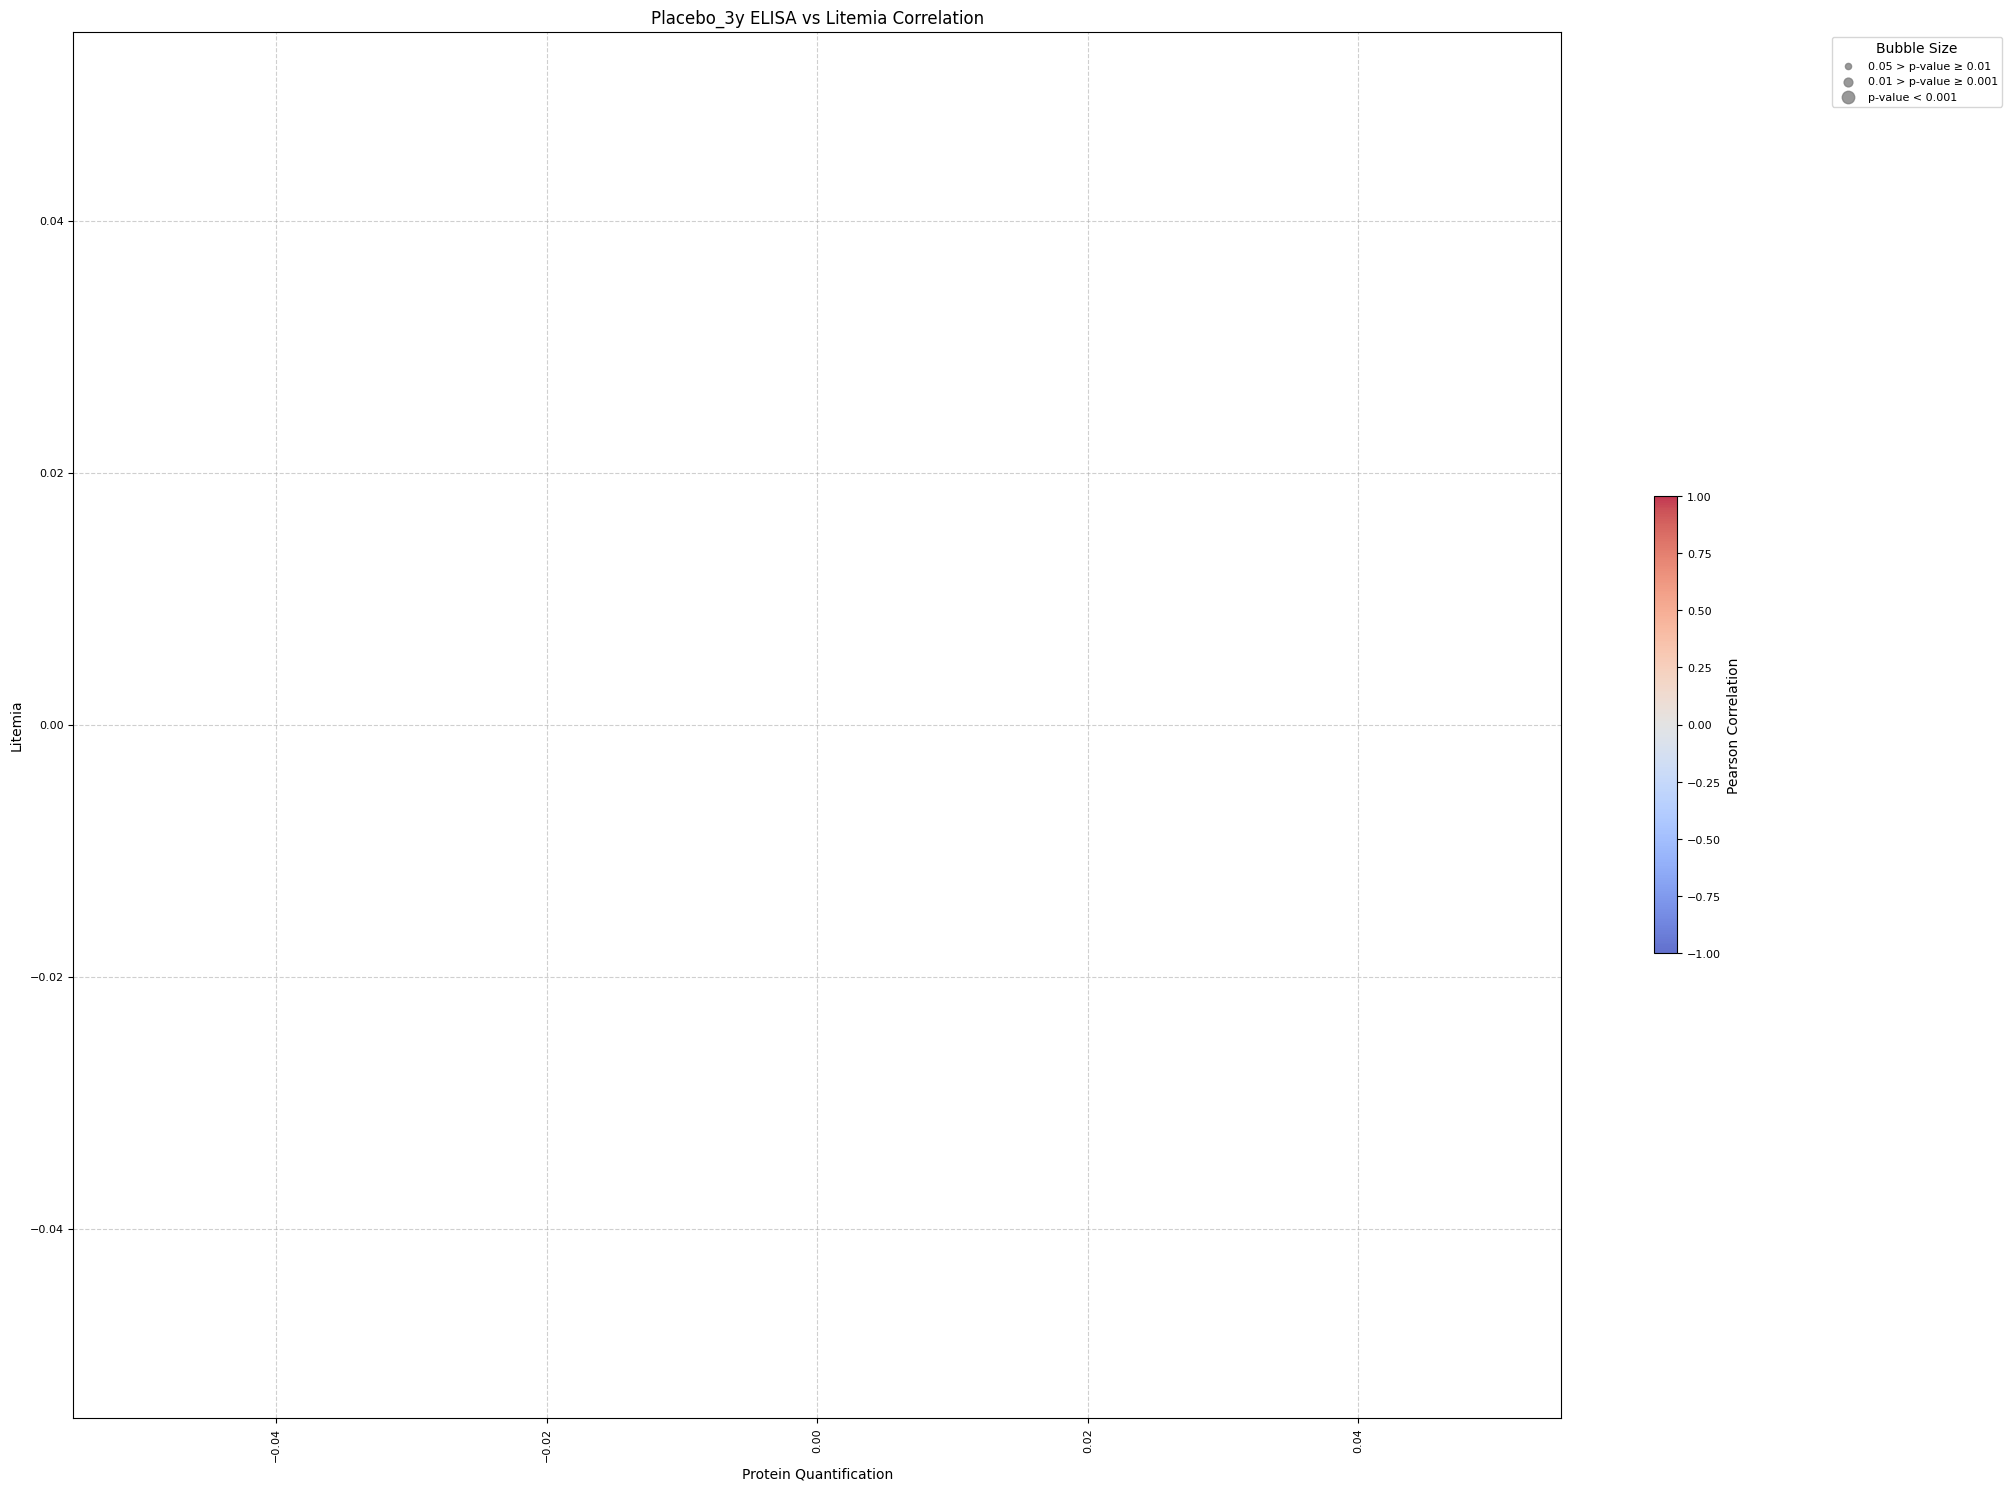

Overall Correlation and p-value Table:
Empty DataFrame
Columns: [Variable 1, Variable 2, Correlation, P-value]
Index: [] 



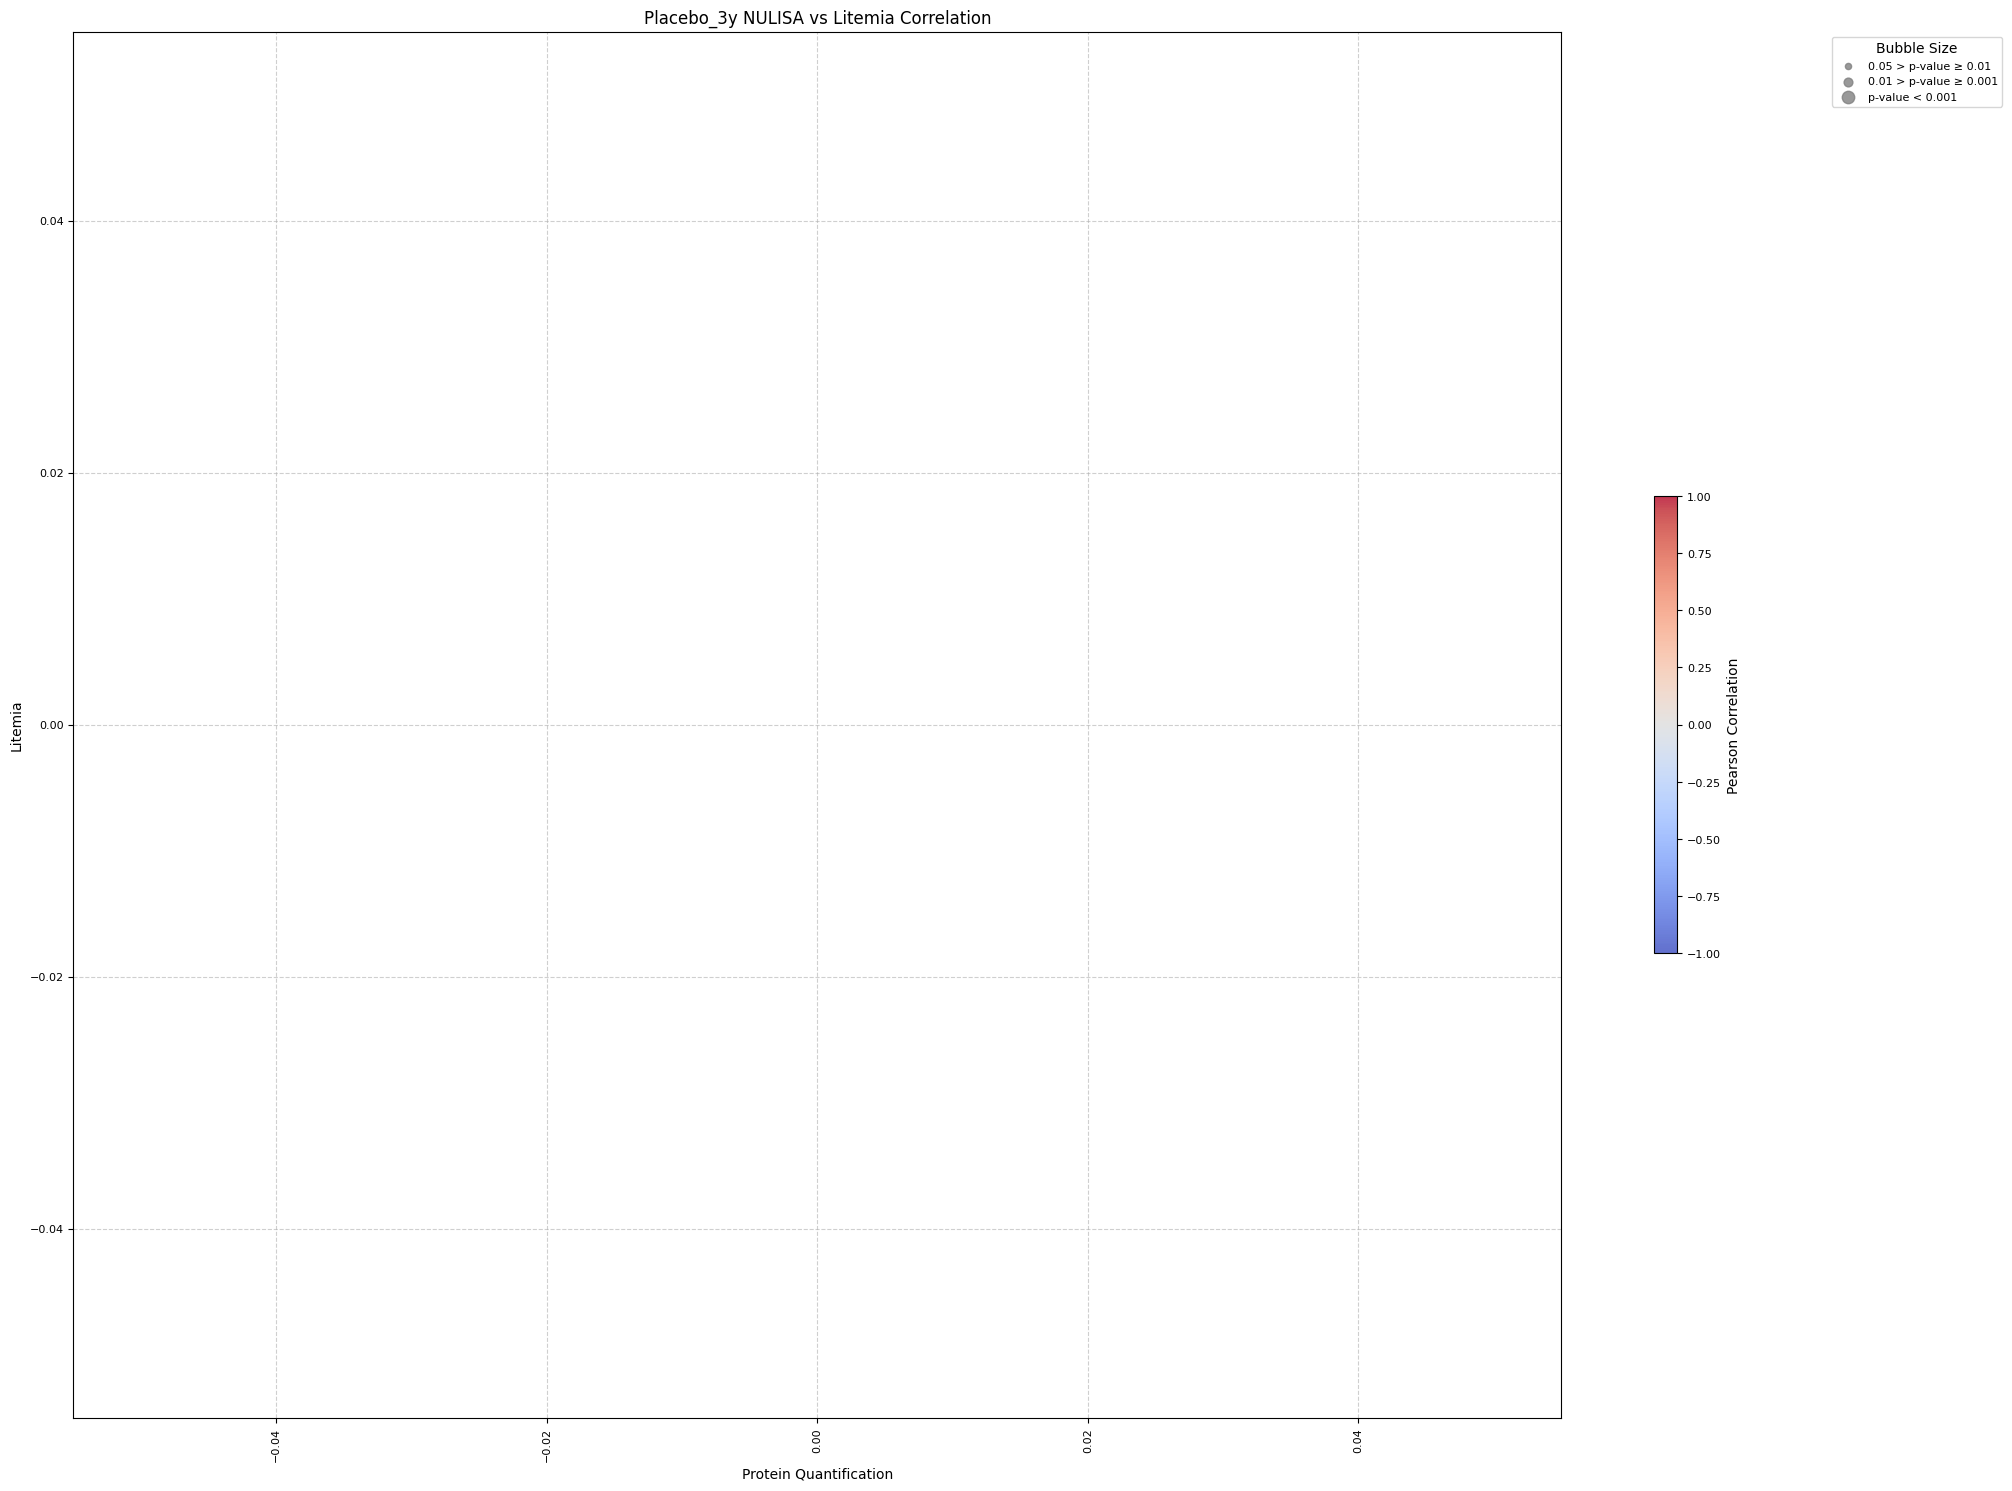

Overall Correlation and p-value Table:
       Variable 1 Variable 2  Correlation   P-value
0     GFRA3_PRM      Litemia     0.704844  0.502034
1      GPC1_PRM      Litemia     0.093995  0.940072
2     NEGR1_PRM      Litemia     0.477623  0.682997
3   RTN4RL2_PRM      Litemia     0.556121  0.624579
4     GRIA4_PRM      Litemia     0.548472  0.630420
5    CARTPT_PRM      Litemia     0.748539  0.461511
6      ACHE_PRM      Litemia     0.322069  0.791243
7      LY6H_PRM      Litemia     0.710501  0.496937
8     NCAM1_PRM      Litemia     0.420633  0.723616
9     NPTX1_PRM      Litemia     0.411646  0.729908
10    NPTX2_PRM      Litemia     0.813005  0.395661
11    NPTXR_PRM      Litemia     0.712585  0.495049
12     DPP6_PRM      Litemia     0.091775  0.941492
13    SCRN1_PRM      Litemia    -0.738210  0.471342
14     C1QA_PRM      Litemia     0.499386  0.667118
15    CNTFR_PRM      Litemia     0.529855  0.644493
16      VGF_PRM      Litemia     0.924124  0.249593
17    TREM2_PRM      Lite

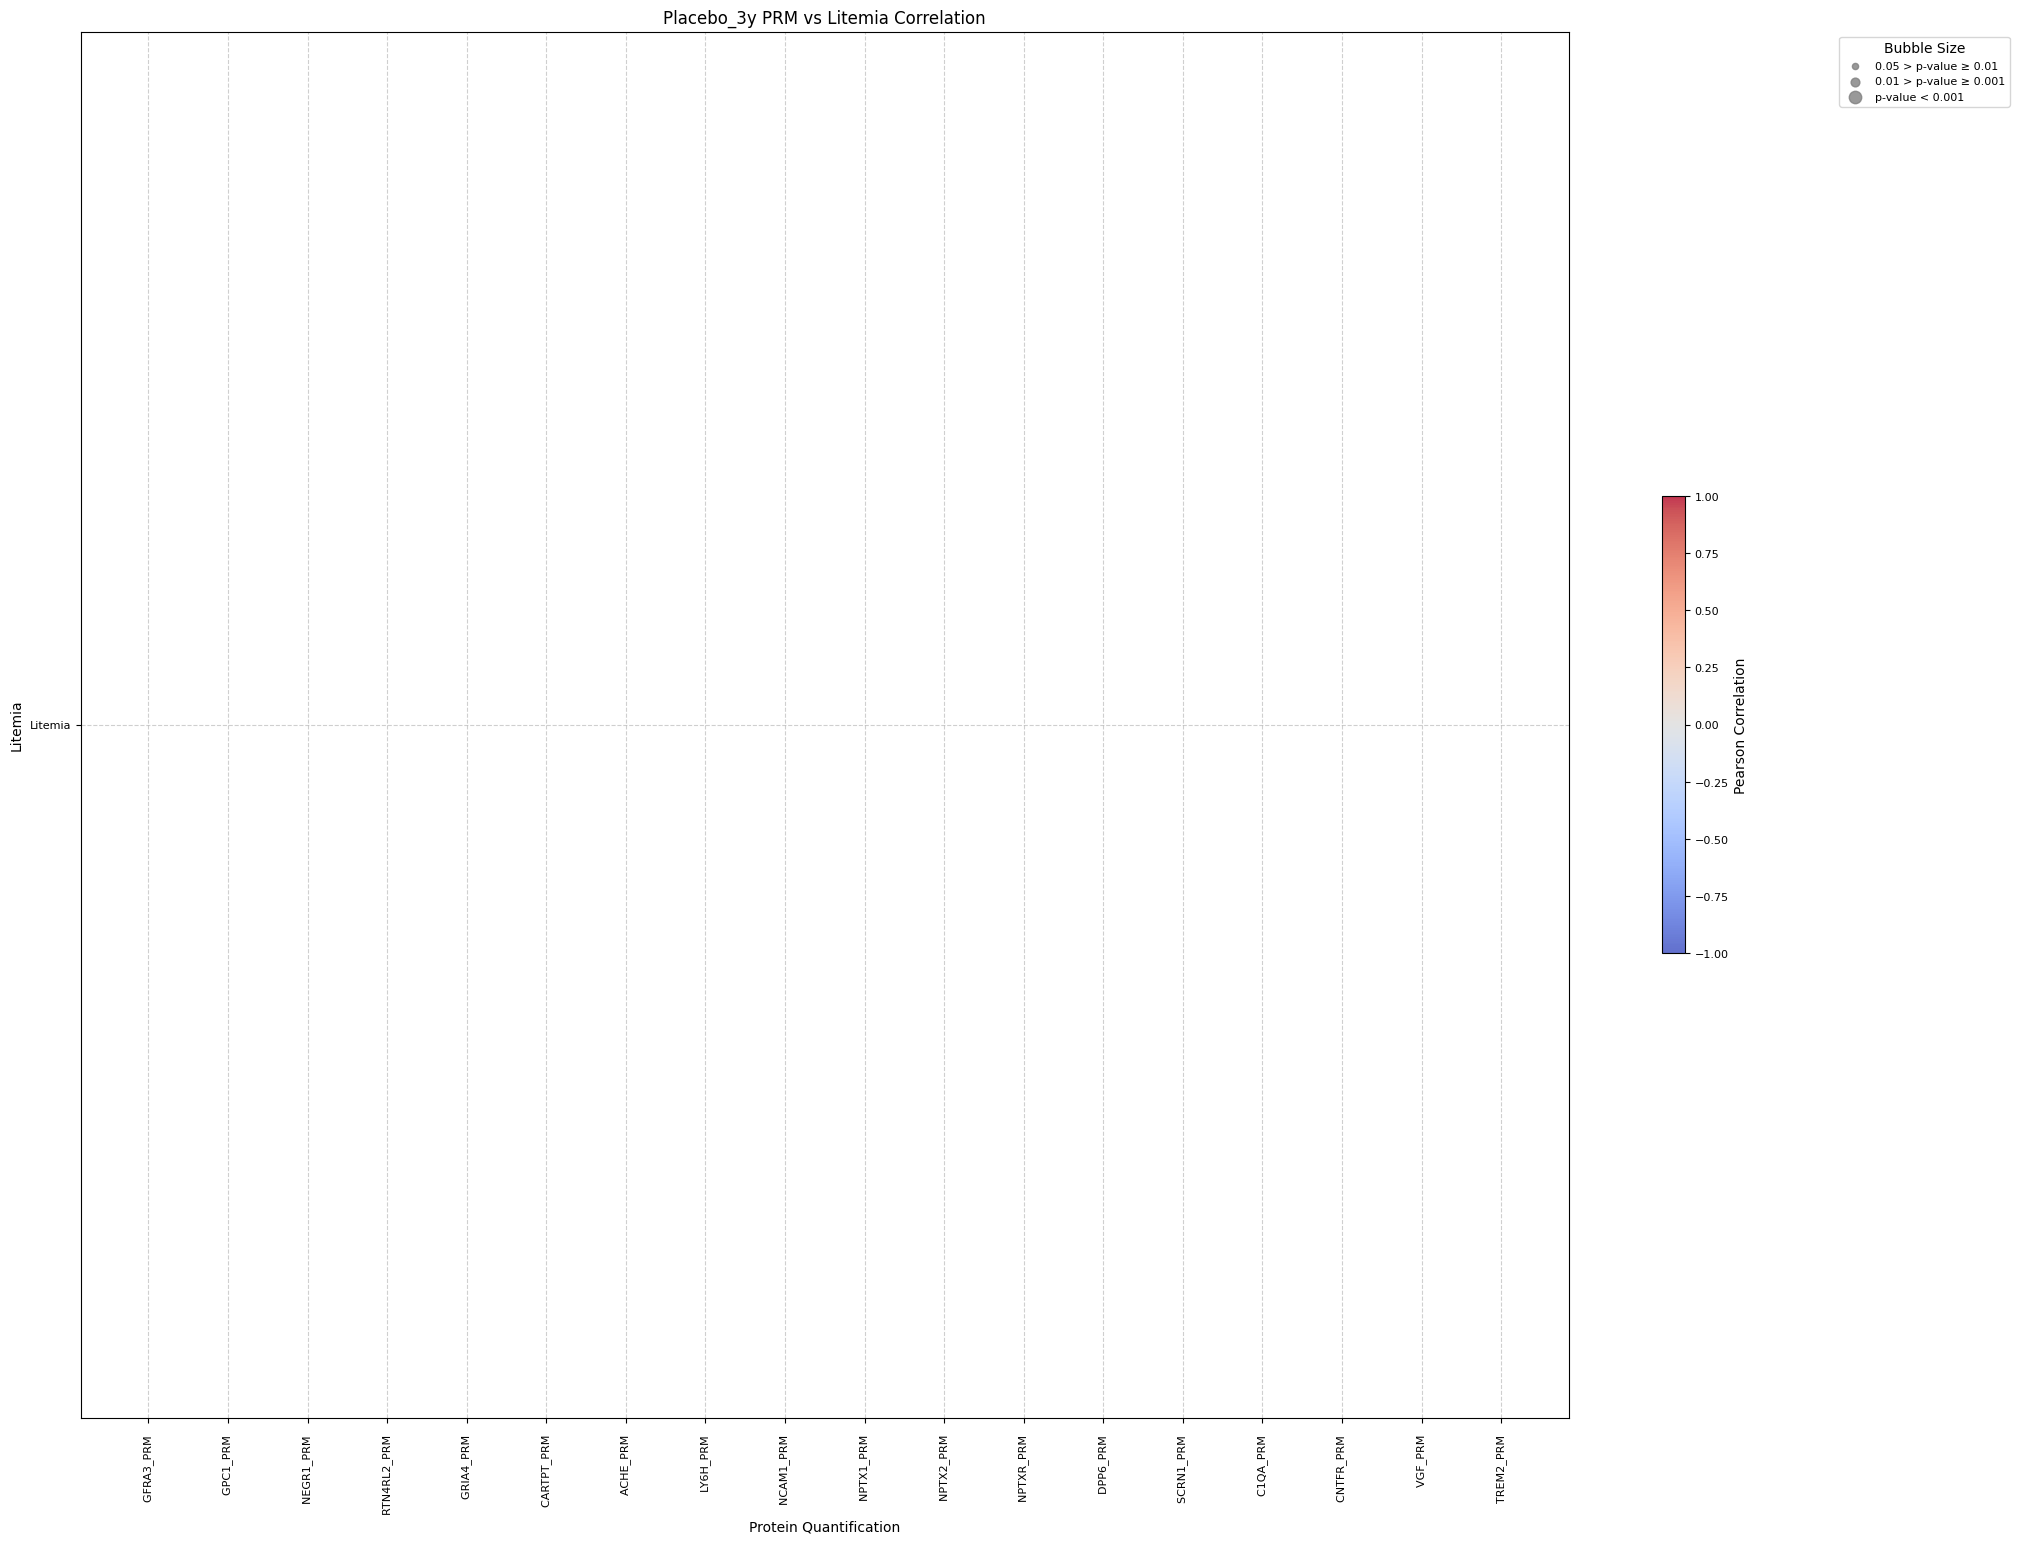

In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import pearsonr
import matplotlib.pyplot as plt

# 데이터프레임(df)이 이미 로드되어 있다고 가정
# Placebo 칼럼과 ELISA, NULISA, PRM 칼럼 분리
placebo_column = 'Placebo'
elisa_columns = [col for col in df.columns if '_ELISA' in col]
nulisa_columns = [col for col in df.columns if '_NULISA' in col]
prm_columns = [col for col in df.columns if '_PRM' in col]

# 그룹 정의 (Placebo_1y와 Placebo_3y만 선택)
groups = {
    'Placebo_1y': df[df['Group'] == 'Placebo_1y'],
    'Placebo_3y': df[df['Group'] == 'Placebo_3y']
}

# 상관관계 계산 함수
def calculate_cross_correlation(df1, df2):
    # 두 데이터프레임의 공통 행만 선택
    common_index = df1.index.intersection(df2.index)
    df1_common = df1.loc[common_index]
    df2_common = df2.loc[common_index]

    # Ensure all columns are numeric
    df1_common = df1_common.apply(pd.to_numeric, errors='coerce')
    df2_common = df2_common.apply(pd.to_numeric, errors='coerce')

    corr_matrix = np.zeros((len(df1_common.columns), len(df2_common.columns)))
    p_matrix = np.zeros((len(df1_common.columns), len(df2_common.columns)))

    for i in range(len(df1_common.columns)):
        for j in range(len(df2_common.columns)):
            # Drop NA values for the current pair of columns
            valid_indices = df1_common.iloc[:, i].notna() & df2_common.iloc[:, j].notna()
            if valid_indices.sum() > 1:  # Ensure there are enough valid pairs
                corr, p_value = pearsonr(df1_common.iloc[:, i][valid_indices], df2_common.iloc[:, j][valid_indices])
                corr_matrix[i, j] = corr
                p_matrix[i, j] = p_value
            else:
                corr_matrix[i, j] = np.nan
                p_matrix[i, j] = np.nan

    return corr_matrix, p_matrix, df1_common.columns, df2_common.columns

# 시각화 함수 정의 (Bubble Chart)
def plot_bubble_correlation(corr_matrix, p_matrix, x_labels, y_labels, title):
    # 상관계수와 p-value를 하나의 데이터프레임으로 병합
    corr_df = pd.DataFrame(corr_matrix, index=x_labels, columns=y_labels)
    p_df = pd.DataFrame(p_matrix, index=x_labels, columns=y_labels)

    # 상관계수와 p-value를 하나의 데이터프레임으로 병합
    corr_df = corr_df.stack().reset_index()
    corr_df.columns = ['Variable 1', 'Variable 2', 'Correlation']

    p_df = p_df.stack().reset_index()
    p_df.columns = ['Variable 1', 'Variable 2', 'P-value']

    merged_df = pd.merge(corr_df, p_df, on=['Variable 1', 'Variable 2'])

    # p-value에 따라 원의 크기 설정 (3단계로 나눔)
    def get_bubble_size(p_value):
        if p_value < 0.001:
            return 80  # 가장 큰 원
        elif 0.001 <= p_value < 0.01:
            return 40  # 중간 원
        elif 0.01 <= p_value < 0.05:
            return 20  # 가장 작은 원
        else:
            return 0  # 0.05 이상인 경우 표시하지 않음

    # 원의 크기 계산
    merged_df['Bubble Size'] = merged_df['P-value'].apply(get_bubble_size)

    # 그림 크기 설정 (크게 조정)
    plt.figure(figsize=(24, 18))  # 그림 크기를 24x18로 늘림

    # 폰트 설정 (Arial과 비슷한 sans-serif 폰트 사용)
    plt.rcParams['font.family'] = 'sans-serif'
    plt.rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans', 'Helvetica', 'Lucida Grande', 'Verdana']
    plt.rcParams['font.size'] = 10  # 기본 폰트 크기 줄임
    plt.rcParams['axes.titlesize'] = 12  # 제목 폰트 크기 줄임
    plt.rcParams['axes.labelsize'] = 10  # 축 레이블 폰트 크기 줄임
    plt.rcParams['xtick.labelsize'] = 8  # x축 틱 폰트 크기 줄임
    plt.rcParams['ytick.labelsize'] = 8  # y축 틱 폰트 크기 줄임

    # Bubble Chart 그리기
    scatter = plt.scatter(
        x=merged_df['Variable 1'],  # x 좌표 (변수 1)
        y=merged_df['Variable 2'],  # y 좌표 (변수 2)
        s=merged_df['Bubble Size'],  # 원의 크기 (p-value에 따라 3단계로 설정)
        c=merged_df['Correlation'],  # 원의 색상 (상관계수)
        cmap='coolwarm',  # 색상 맵: -1(파란색) ~ 1(빨간색)
        vmin=-1,
        vmax=1,
        alpha=0.8  # 투명도
    )

    # 색상 바 추가 (크기 축소)
    cbar = plt.colorbar(scatter, shrink=0.33)  # 크기 축소
    cbar.set_label('Pearson Correlation', fontsize=10)  # 색상바 레이블 폰트 크기 줄임

    # 축 레이블 및 제목 설정
    plt.xlabel('Protein Quantification', fontsize=10)
    plt.ylabel('Litemia', fontsize=10)
    plt.title(title, fontsize=12)

    # x축과 y축의 라벨 회전
    plt.xticks(rotation=90)
    plt.yticks(rotation=0)

    # 그리드 추가
    plt.grid(True, linestyle='--', alpha=0.6)

    # 범례 추가 (원의 크기 설명)
    for pvalue_range, size in zip(
        ['0.05 > p-value ≥ 0.01', '0.01 > p-value ≥ 0.001', 'p-value < 0.001'],  # 범례 설명 수정
        [20, 40, 80]  # 원의 크기
    ):
        plt.scatter([], [], s=size, c='gray', alpha=0.8, label=pvalue_range)  # 범례 설명 적용
    plt.legend(title='Bubble Size', loc='upper right', bbox_to_anchor=(1.3, 1), fontsize=8)  # 범례 폰트 크기 줄임

    # Pearson 상관계수와 p-value 테이블 출력
    print(f"Overall Correlation and p-value Table:")
    print(merged_df[['Variable 1', 'Variable 2', 'Correlation', 'P-value']].dropna(), "\n")

    # Excel로 테이블 저장
    merged_df[['Variable 1', 'Variable 2', 'Correlation', 'P-value']].dropna().to_excel(
        f"../data/output/{title}_correlation_table.xlsx", index=False)

    # PDF로 저장
    plt.savefig(f'{title}_bubble_chart.pdf', format='pdf', bbox_inches='tight')
    plt.show()

# 각 그룹별로 Placebo와 ELISA, NULISA, PRM 간의 상관관계 분석
for group_name, group_data in groups.items():
    print(f"Analyzing group: {group_name}")

    # 데이터 정제
    group_elisa = group_data[elisa_columns].dropna()
    group_nulisa = group_data[nulisa_columns].dropna()
    group_prm = group_data[prm_columns].dropna()
    group_litemia = group_data[[litemia_column]].dropna()

    # ELISA vs Litemia
    elisa_litemia_corr, elisa_litemia_p, elisa_labels, _ = calculate_cross_correlation(group_elisa, group_litemia)
    plot_bubble_correlation(elisa_litemia_corr, elisa_litemia_p, elisa_labels, [litemia_column], title=f'{group_name} ELISA vs Litemia Correlation')

    # NULISA vs Litemia
    nulisa_litemia_corr, nulisa_litemia_p, nulisa_labels, _ = calculate_cross_correlation(group_nulisa, group_litemia)
    plot_bubble_correlation(nulisa_litemia_corr, nulisa_litemia_p, nulisa_labels, [litemia_column], title=f'{group_name} NULISA vs Litemia Correlation')

    # PRM vs Litemia
    prm_litemia_corr, prm_litemia_p, prm_labels, _ = calculate_cross_correlation(group_prm, group_litemia)
    plot_bubble_correlation(prm_litemia_corr, prm_litemia_p, prm_labels, [litemia_column], title=f'{group_name} PRM vs Litemia Correlation')

In [ ]:
# Group 칼럼에 결측값이 있는지 확인
print(df['Group'].isnull().sum())

# 결측값이 있는 행 제거 (또는 다른 방식으로 처리 가능)
df_cleaned = df.dropna(subset=['Group'])

# Lithium 그룹과 Placebo 그룹 분류
lithium_group = df_cleaned[df_cleaned['Group'].str.startswith('Lithium')]
placebo_group = df_cleaned[df_cleaned['Group'].str.startswith('Placebo')]

# 분류된 그룹 확인
print("Lithium Group:")
print(lithium_group.head())
print("\nPlacebo Group:")
print(placebo_group.head())

3
Lithium Group:
    Sample Number Sample number by KD         Group Sex  CDR  CDR_SB   ADAS  \
0             907             907_0    Lithium_base   F  1.0     4.5  11.66   
4             917             917_0    Lithium_base   F  0.0     0.0   2.00   
5             919             919_0    Lithium_base   F  0.5     1.0  10.32   
6             925             925_0    Lithium_base   M  0.5     1.5  11.30   
12            944             944_0    Lithium_base   M  0.5     1.0   9.30   

    SLN   TMTA   TMTB  ...  NCAM1_PRM    NPTX1_PRM    NPTX2_PRM    \
0   3.0  119.0  300.0  ...     0.242552     0.589056     0.412637   
4   9.0   58.0  127.0  ...    -0.123221    -0.303194     0.125567   
5   4.0   43.0  183.0  ...     0.362944     0.073400     0.219681   
6   7.0   40.0   70.0  ...     0.222489     0.394319     0.135947   
12  7.0   78.0  161.0  ...    -0.006484     0.199696     0.284467   

    NPTXR_PRM    DPP6_PRM    SCRN1_PRM    C1QA_PRM    CNTFR_PRM    VGF_PRM    \
0      0.2895

In [ ]:
# Lithium 그룹에서 환자별 방문 기록 정리
lithium_patient_records = {}
for name, group in lithium_group.groupby('Sample number by KD'):
    patient_id = name.split('_')[0]  # 환자 ID 추출 (예: 907_0 -> 907)
    visit_number = name.split('_')[1]  # 방문 번호 추출 (예: 907_0 -> 0)

    if patient_id not in lithium_patient_records:
        lithium_patient_records[patient_id] = {}

    lithium_patient_records[patient_id][visit_number] = group

# Lithium 그룹 환자별 방문 기록 확인
print("Lithium Group Patient Records:")
for patient_id, visits in lithium_patient_records.items():
    print(f"Patient ID: {patient_id}")
    for visit_number, data in visits.items():
        print(f"Visit {visit_number}:")
        print(data)
        print("\n")

Lithium Group Patient Records:
Patient ID: 1013
Visit 0  :
    Sample Number Sample number by KD         Group Sex  CDR  CDR_SB  ADAS  \
24           1013            1013_0    Lithium_base   F  0.5     0.5   4.3   

    SLN  TMTA   TMTB  ...  NCAM1_PRM    NPTX1_PRM    NPTX2_PRM    NPTXR_PRM    \
24  7.0  46.0  166.0  ...      0.09784     0.018886     0.401226     0.251002   

    DPP6_PRM    SCRN1_PRM    C1QA_PRM    CNTFR_PRM    VGF_PRM    TREM2_PRM    
24     0.23167    -0.870232     -0.1433    -0.134999   0.188373    -0.529639  

[1 rows x 151 columns]


Visit 1:
    Sample Number Sample number by KD       Group Sex  CDR  CDR_SB  ADAS  SLN  \
67           1548              1013_1  Lithium_1y   F  0.5     2.0  9.33  6.0   

    TMTA   TMTB  ...  NCAM1_PRM    NPTX1_PRM    NPTX2_PRM    NPTXR_PRM    \
67  56.0  177.0  ...    -0.076559    -0.327577    -0.053199    -0.005555   

    DPP6_PRM    SCRN1_PRM    C1QA_PRM    CNTFR_PRM    VGF_PRM    TREM2_PRM    
67   -0.614346     0.190522   -0.

In [ ]:
# Placebo 그룹에서 환자별 방문 기록 정리
placebo_patient_records = {}
for name, group in placebo_group.groupby('Sample number by KD'):
    patient_id = name.split('_')[0]  # 환자 ID 추출 (예: 907_0 -> 907)
    visit_number = name.split('_')[1]  # 방문 번호 추출 (예: 907_0 -> 0)

    if patient_id not in placebo_patient_records:
        placebo_patient_records[patient_id] = {}

    placebo_patient_records[patient_id][visit_number] = group

# Placebo 그룹 환자별 방문 기록 확인
print("Placebo Group Patient Records:")
for patient_id, visits in placebo_patient_records.items():
    print(f"Patient ID: {patient_id}")
    for visit_number, data in visits.items():
        print(f"Visit {visit_number}:")
        print(data)
        print("\n")

Placebo Group Patient Records:
Patient ID: 1012
Visit 0  :
    Sample Number Sample number by KD         Group Sex  CDR  CDR_SB  ADAS  \
23           1012            1012_0    Placebo_base   M  0.5     2.0  13.6   

    SLN   TMTA   TMTB  ...  NCAM1_PRM    NPTX1_PRM    NPTX2_PRM    \
23  4.0  110.0  223.0  ...     0.654248     0.437037     0.680101   

    NPTXR_PRM    DPP6_PRM    SCRN1_PRM    C1QA_PRM    CNTFR_PRM    VGF_PRM    \
23     0.628222    0.746706     0.311708    0.611384     0.503999   0.390795   

    TREM2_PRM    
23      0.39673  

[1 rows x 151 columns]


Visit 1:
    Sample Number Sample number by KD       Group Sex  CDR  CDR_SB   ADAS  \
61           1436              1012_1  Placebo_1y   M  0.5     2.0  11.96   

    SLN  TMTA   TMTB  ...  NCAM1_PRM    NPTX1_PRM    NPTX2_PRM    NPTXR_PRM    \
61  5.0  67.0  205.0  ...     0.644426     0.447599     0.489557     0.569995   

    DPP6_PRM    SCRN1_PRM    C1QA_PRM    CNTFR_PRM    VGF_PRM    TREM2_PRM    
61     0.53284  

In [ ]:
# _ELISA로 끝나는 칼럼 선택
elisa_columns = [col for col in df.columns if col.endswith('_ELISA')]

# 선택된 칼럼 확인
print("ELISA Columns:")
print(elisa_columns)

ELISA Columns:
['NPTX2_ELISA', 'NPTXR_ELISA', 'NPTX2/NPTXR_ELISA', 'Ab_ELISA', 'Tau_ELISA', 'pTau_ELISA', 'Ab/pTau_ELISA']


In [ ]:
import numpy as np

# log2 변환 함수 정의
def log2_transform(x):
    return np.log2(x + 1)  # 0 또는 음수 값을 방지하기 위해 1을 더함

In [ ]:
# Lithium 그룹에서 _ELISA 칼럼 log2 변환
for patient_id, visits in lithium_patient_records.items():
    for visit_number, data in visits.items():
        data[elisa_columns] = data[elisa_columns].apply(log2_transform)

# 변환된 데이터 확인
print("Lithium Group After Log2 Transformation:")
for patient_id, visits in lithium_patient_records.items():
    print(f"Patient ID: {patient_id}")
    for visit_number, data in visits.items():
        print(f"Visit {visit_number}:")
        print(data[elisa_columns].head())
        print("\n")

Lithium Group After Log2 Transformation:
Patient ID: 1013
Visit 0  :
    NPTX2_ELISA  NPTXR_ELISA  NPTX2/NPTXR_ELISA  Ab_ELISA  Tau_ELISA  \
24    10.499916     4.590003           0.087717  8.934929   6.541716   

    pTau_ELISA  Ab/pTau_ELISA  
24     5.66775       3.433059  


Visit 1:
    NPTX2_ELISA  NPTXR_ELISA  NPTX2/NPTXR_ELISA  Ab_ELISA  Tau_ELISA  \
67    10.094236     4.024852           0.099609  8.601046    5.98288   

    pTau_ELISA  Ab/pTau_ELISA  
67    5.249066       3.518437  


Patient ID: 1021
Visit 0  :
    NPTX2_ELISA  NPTXR_ELISA  NPTX2/NPTXR_ELISA  Ab_ELISA  Tau_ELISA  \
25    11.666335     5.488226           0.103043  8.199574   8.156665   

    pTau_ELISA  Ab/pTau_ELISA  
25    7.391115       1.462494  


Visit 1:
    NPTX2_ELISA  NPTXR_ELISA  NPTX2/NPTXR_ELISA  Ab_ELISA  Tau_ELISA  \
90    11.488141     4.419876           0.189958  7.658497   7.854744   

    pTau_ELISA  Ab/pTau_ELISA  
90    7.009773       1.363015  


Visit 2:
     NPTX2_ELISA  NPTXR_ELISA  N

In [ ]:
# Placebo 그룹에서 _ELISA 칼럼 log2 변환
for patient_id, visits in placebo_patient_records.items():
    for visit_number, data in visits.items():
        data[elisa_columns] = data[elisa_columns].apply(log2_transform)

# 변환된 데이터 확인
print("Placebo Group After Log2 Transformation:")
for patient_id, visits in placebo_patient_records.items():
    print(f"Patient ID: {patient_id}")
    for visit_number, data in visits.items():
        print(f"Visit {visit_number}:")
        print(data[elisa_columns].head())
        print("\n")

Placebo Group After Log2 Transformation:
Patient ID: 1012
Visit 0  :
    NPTX2_ELISA  NPTXR_ELISA  NPTX2/NPTXR_ELISA  Ab_ELISA  Tau_ELISA  \
23    10.636887     4.670784           0.090891  8.494216    7.61934   

    pTau_ELISA  Ab/pTau_ELISA  
23    6.537917       2.296307  


Visit 1:
    NPTX2_ELISA  NPTXR_ELISA  NPTX2/NPTXR_ELISA  Ab_ELISA  Tau_ELISA  \
61    10.663189     4.802969           0.084352  8.548148   7.496614   

    pTau_ELISA  Ab/pTau_ELISA  
61    6.166414       2.648716  


Visit 2:
    NPTX2_ELISA  NPTXR_ELISA  NPTX2/NPTXR_ELISA  Ab_ELISA  Tau_ELISA  \
92     10.80401     4.828327            0.09111       NaN        NaN   

    pTau_ELISA  Ab/pTau_ELISA  
92         NaN            NaN  


Patient ID: 1022
Visit 0  :
    NPTX2_ELISA  NPTXR_ELISA  NPTX2/NPTXR_ELISA  Ab_ELISA  Tau_ELISA  \
26    10.013937     4.321856           0.076379  9.445036   5.581954   

    pTau_ELISA  Ab/pTau_ELISA  
26    4.813012       4.737338  


Visit 1:
    NPTX2_ELISA  NPTXR_ELISA  NP

In [ ]:
# Lithium 그룹 데이터 통합
lithium_combined = pd.concat(
    [data for patient_id, visits in lithium_patient_records.items() for visit_number, data in visits.items()],
    ignore_index=True
)

# 통합된 데이터 확인
print("Combined Lithium Group Data:")
print(lithium_combined.head())

Combined Lithium Group Data:
   Sample Number Sample number by KD         Group Sex  CDR  CDR_SB  ADAS  \
0           1013            1013_0    Lithium_base   F  0.5     0.5  4.30   
1           1548              1013_1    Lithium_1y   F  0.5     2.0  9.33   
2           1021            1021_0    Lithium_base   F  0.5     NaN   NaN   
3           2050              1021_1    Lithium_1y   F  0.5     0.5  7.30   
4           2191              1021_2    Lithium_3y   F  NaN     NaN   NaN   

   SLN  TMTA   TMTB  ...  NCAM1_PRM  NPTX1_PRM  NPTX2_PRM  NPTXR_PRM  \
0  7.0  46.0  166.0  ...   0.097840   0.018886   0.401226   0.251002   
1  6.0  56.0  177.0  ...  -0.076559  -0.327577  -0.053199  -0.005555   
2  NaN   NaN    NaN  ...   1.378701   1.253392   1.224283   1.318482   
3  7.0  45.0  114.0  ...   1.324345   1.165860   1.011856   1.288084   
4  NaN   NaN    NaN  ...   1.214958   0.890140   1.381644   1.367631   

   DPP6_PRM  SCRN1_PRM  C1QA_PRM  CNTFR_PRM   VGF_PRM  TREM2_PRM  
0  0.231

In [ ]:
# Placebo 그룹 데이터 통합
placebo_combined = pd.concat(
    [data for patient_id, visits in placebo_patient_records.items() for visit_number, data in visits.items()],
    ignore_index=True
)

# 통합된 데이터 확인
print("Combined Placebo Group Data:")
print(placebo_combined.head())

Combined Placebo Group Data:
   Sample Number Sample number by KD         Group Sex  CDR  CDR_SB   ADAS  \
0           1012            1012_0    Placebo_base   M  0.5     2.0  13.60   
1           1436              1012_1    Placebo_1y   M  0.5     2.0  11.96   
2           2086              1012_2    Placebo_3y   M  0.5     1.0  10.30   
3           1022            1022_0    Placebo_base   F  0.0     0.0   5.00   
4           1457              1022_1    Placebo_1y   F  0.0     0.0   6.30   

    SLN   TMTA   TMTB  ...  NCAM1_PRM    NPTX1_PRM    NPTX2_PRM    \
0   4.0  110.0  223.0  ...     0.654248     0.437037     0.680101   
1   5.0   67.0  205.0  ...     0.644426     0.447599     0.489557   
2   4.0   75.0  233.0  ...     0.420645     0.203738     0.307086   
3   8.0   55.0  100.0  ...    -0.389075    -0.236106    -0.349854   
4  10.0   44.0   89.0  ...    -0.273386    -0.040405    -0.208081   

   NPTXR_PRM    DPP6_PRM    SCRN1_PRM    C1QA_PRM    CNTFR_PRM    VGF_PRM    \
0     0.

In [ ]:
# Lithium 그룹 데이터 저장
lithium_combined.to_csv('../data/output/lithium_group_log2.csv', index=False)

# Placebo 그룹 데이터 저장
placebo_combined.to_csv('../data/output/placebo_group_log2.csv', index=False)

In [ ]:
# 파일 경로 설정 (업로드한 파일 경로를 여기에 넣으세요)
file_path_lithium = '../data/input/Separated_Lithium_Group_Visit_Differences.csv'
file_path_placebo = '../data/input/Separated_Placebo_Group_Visit_Differences.csv'

# 파일 불러오기
lithium_group_data = pd.read_csv(file_path_lithium)
placebo_group_data = pd.read_csv(file_path_placebo)

In [ ]:
# 데이터 확인
print("Lithium Group Data:")
print(lithium_group_data.head())

print("\nPlacebo Group Data:")
print(placebo_group_data.head())

Lithium Group Data:
   Patient ID  CDR_diff_visit_0_vs_1  CDR_SB_diff_visit_0_vs_1  \
0        1013                    0.0                       1.5   
1        1021                    0.0                       NaN   
2        1036                   -0.5                       0.0   
3        1041                    0.0                       0.0   
4        1105                    0.0                      -0.5   

   ADAS_diff_visit_0_vs_1  SLN_diff_visit_0_vs_1  TMTA_diff_visit_0_vs_1  \
0                    5.03                   -1.0                    10.0   
1                     NaN                    NaN                     NaN   
2                    3.70                    1.0                    16.0   
3                    6.36                   -4.0                   -10.0   
4                   -1.33                    0.0                   -10.0   

   TMTB_diff_visit_0_vs_1  NPTX2_ELISA_diff_visit_0_vs_1  \
0                    11.0                      -0.405680   
1     

In [ ]:
# 각 그룹 데이터에 대해 _ELISA, _PRM, _NULISA, demographic 칼럼을 분리하는 함수 정의
def split_columns_by_type(data):
    # _ELISA, _PRM, _NULISA를 포함하는 칼럼 분리
    elisa_columns = [col for col in data.columns if '_ELISA' in col]
    prm_columns = [col for col in data.columns if '_PRM' in col]
    nulisa_columns = [col for col in data.columns if '_NULISA' in col]

    # demographic 칼럼은 나머지 칼럼으로 설정
    demographic_columns = [col for col in data.columns if col not in elisa_columns + prm_columns + nulisa_columns]

    # 각각의 칼럼 그룹을 데이터프레임으로 반환
    elisa_data = data[elisa_columns]
    prm_data = data[prm_columns]
    nulisa_data = data[nulisa_columns]
    demographic_data = data[demographic_columns]

    return elisa_data, prm_data, nulisa_data, demographic_data

# Lithium 그룹 데이터에 대해 칼럼 분리
lithium_elisa, lithium_prm, lithium_nulisa, lithium_demographic = split_columns_by_type(lithium_group_data)

# Placebo 그룹 데이터에 대해 칼럼 분리
placebo_elisa, placebo_prm, placebo_nulisa, placebo_demographic = split_columns_by_type(placebo_group_data)

# 결과 확인 (상위 5개 행)
print("Lithium Group - ELISA columns:")
print(lithium_elisa.head())

print("\nLithium Group - PRM columns:")
print(lithium_prm.head())

print("\nLithium Group - NULISA columns:")
print(lithium_nulisa.head())

print("\nLithium Group - Demographic columns:")
print(lithium_demographic.head())

print("\nPlacebo Group - ELISA columns:")
print(placebo_elisa.head())

print("\nPlacebo Group - PRM columns:")
print(placebo_prm.head())

print("\nPlacebo Group - NULISA columns:")
print(placebo_nulisa.head())

print("\nPlacebo Group - Demographic columns:")
print(placebo_demographic.head())

Lithium Group - ELISA columns:
   NPTX2_ELISA_diff_visit_0_vs_1  NPTXR_ELISA_diff_visit_0_vs_1  \
0                      -0.405680                      -0.565152   
1                      -0.178194                      -1.068350   
2                      -0.181694                      -0.022009   
3                       0.083613                       0.167062   
4                      -0.273435                      -0.286011   

   NPTX2/NPTXR_ELISA_diff_visit_0_vs_1  Ab_ELISA_diff_visit_0_vs_1  \
0                             0.011892                   -0.333883   
1                             0.086914                   -0.541077   
2                            -0.013740                   -0.046160   
3                            -0.005715                   -0.146260   
4                             0.001551                   -0.315854   

   Tau_ELISA_diff_visit_0_vs_1  pTau_ELISA_diff_visit_0_vs_1  \
0                    -0.558837                     -0.418684   
1                

In [ ]:
# demographic 칼럼에서 'Number of APOE ?4_diff_visit_0_vs_2' 칼럼 제외하기
def remove_specific_column_from_demographic(demographic_data):
    # 'Number of APOE ?4_diff_visit_0_vs_2' 칼럼 제거
    demographic_data = demographic_data.drop(columns=['Number of APOE ?4_diff_visit_0_vs_2'], errors='ignore')
    return demographic_data

# Lithium 그룹에서 demographic 칼럼 수정
lithium_demographic_cleaned = remove_specific_column_from_demographic(lithium_demographic)

# Placebo 그룹에서 demographic 칼럼 수정
placebo_demographic_cleaned = remove_specific_column_from_demographic(placebo_demographic)

# 결과 확인
print("Lithium Group - Cleaned Demographic columns:")
print(lithium_demographic_cleaned.head())

print("\nPlacebo Group - Cleaned Demographic columns:")
print(placebo_demographic_cleaned.head())

Lithium Group - Cleaned Demographic columns:
   Patient ID  CDR_diff_visit_0_vs_1  CDR_SB_diff_visit_0_vs_1  \
0        1013                    0.0                       1.5   
1        1021                    0.0                       NaN   
2        1036                   -0.5                       0.0   
3        1041                    0.0                       0.0   
4        1105                    0.0                      -0.5   

   ADAS_diff_visit_0_vs_1  SLN_diff_visit_0_vs_1  TMTA_diff_visit_0_vs_1  \
0                    5.03                   -1.0                    10.0   
1                     NaN                    NaN                     NaN   
2                    3.70                    1.0                    16.0   
3                    6.36                   -4.0                   -10.0   
4                   -1.33                    0.0                   -10.0   

   TMTB_diff_visit_0_vs_1  Litemia_diff_visit_0_vs_1  CDR_diff_visit_0_vs_2  \
0                    1

In [ ]:
from scipy.stats import pearsonr
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 상관 관계와 p-value 계산 함수 정의
def calculate_correlation_with_pvalue(data, columns):
    corr_matrix = data[columns].corr(method='pearson')
    p_values = pd.DataFrame(index=corr_matrix.columns, columns=corr_matrix.columns)

    for i in corr_matrix.columns:
        for j in corr_matrix.columns:
            if i != j:
                _, p_value = pearsonr(data[i], data[j])
                p_values.loc[i, j] = p_value
            else:
                p_values.loc[i, j] = 0  # 자기 자신과의 p-value는 0으로 설정

    return corr_matrix, p_values

# 시각화 함수 정의 (Bubble chart + Heatmap)
def plot_bubble_correlation(corr_matrix, p_matrix, title):
    # 상관계수와 p-value를 하나의 데이터프레임으로 병합
    corr_df = corr_matrix.stack().reset_index()
    corr_df.columns = ['Variable 1', 'Variable 2', 'Correlation']
    p_df = p_matrix.stack().reset_index()
    p_df.columns = ['Variable 1', 'Variable 2', 'P-value']

    merged_df = pd.merge(corr_df, p_df, on=['Variable 1', 'Variable 2'])

    # p-value에 따라 원의 크기 설정
    def get_bubble_size(p_value):
        if p_value < 0.001:
            return 80  # 가장 큰 원
        elif 0.001 <= p_value < 0.01:
            return 40  # 중간 원
        elif 0.01 <= p_value < 0.05:
            return 20  # 가장 작은 원
        else:
            return 0  # 0.05 이상인 경우 표시하지 않음

    # 원의 크기 계산
    merged_df['Bubble Size'] = merged_df['P-value'].apply(get_bubble_size)

    # 그림 크기 설정
    plt.figure(figsize=(24, 18))

    # Bubble Chart 그리기
    scatter = plt.scatter(
        x=merged_df['Variable 1'],  # x 좌표 (변수 1)
        y=merged_df['Variable 2'],  # y 좌표 (변수 2)
        s=merged_df['Bubble Size'],  # 원의 크기 (p-value에 따라 3단계로 설정)
        c=merged_df['Correlation'],  # 원의 색상 (상관계수)
        cmap='coolwarm',  # 색상 맵: -1(파란색) ~ 1(빨간색)
        vmin=-1,
        vmax=1,
        alpha=0.8
    )

    # 색상 바 추가
    cbar = plt.colorbar(scatter, shrink=0.33)
    cbar.set_label('Pearson Correlation', fontsize=10)

    # 축 레이블 및 제목 설정
    plt.xlabel('Variable 1', fontsize=10)
    plt.ylabel('Variable 2', fontsize=10)
    plt.title(title, fontsize=12)

    # x축과 y축의 라벨 회전
    plt.xticks(rotation=90)
    plt.yticks(rotation=0)

    # 그리드 추가
    plt.grid(True, linestyle='--', alpha=0.6)

    # 범례 추가
    for pvalue_range, size in zip(
        ['0.05 > p-value ≥ 0.01', '0.01 > p-value ≥ 0.001', 'p-value < 0.001'],
        [20, 40, 80]
    ):
        plt.scatter([], [], s=size, c='gray', alpha=0.8, label=pvalue_range)
    plt.legend(title='Bubble Size', loc='upper right', bbox_to_anchor=(1.3, 1), fontsize=8)

    # Pearson 상관계수와 p-value 테이블 출력
    print(f"Correlation and p-value Table for {title}:")
    print(merged_df[['Variable 1', 'Variable 2', 'Correlation', 'P-value']].dropna(), "\n")

    # Excel로 테이블 저장
    output_file = f"../data/output/{title}_correlation_table.xlsx"
    merged_df[['Variable 1', 'Variable 2', 'Correlation', 'P-value']].dropna().to_excel(output_file, index=False)
    print(f"Table saved to: {output_file}")

    # PDF로 저장
    plt.savefig(f'{title}_bubble_chart.pdf', format='pdf', bbox_inches='tight')
    plt.show()

Correlation and p-value Table for Lithium Group: ELISA Correlation with p-value:
                             Variable 1                           Variable 2  \
0         NPTX2_ELISA_diff_visit_0_vs_1        NPTX2_ELISA_diff_visit_0_vs_1   
1         NPTX2_ELISA_diff_visit_0_vs_1        NPTXR_ELISA_diff_visit_0_vs_1   
2         NPTX2_ELISA_diff_visit_0_vs_1  NPTX2/NPTXR_ELISA_diff_visit_0_vs_1   
3         NPTX2_ELISA_diff_visit_0_vs_1           Ab_ELISA_diff_visit_0_vs_1   
4         NPTX2_ELISA_diff_visit_0_vs_1          Tau_ELISA_diff_visit_0_vs_1   
5         NPTX2_ELISA_diff_visit_0_vs_1         pTau_ELISA_diff_visit_0_vs_1   
6         NPTX2_ELISA_diff_visit_0_vs_1      Ab/pTau_ELISA_diff_visit_0_vs_1   
7         NPTXR_ELISA_diff_visit_0_vs_1        NPTX2_ELISA_diff_visit_0_vs_1   
8         NPTXR_ELISA_diff_visit_0_vs_1        NPTXR_ELISA_diff_visit_0_vs_1   
9         NPTXR_ELISA_diff_visit_0_vs_1  NPTX2/NPTXR_ELISA_diff_visit_0_vs_1   
10        NPTXR_ELISA_diff_visit_0_vs_1

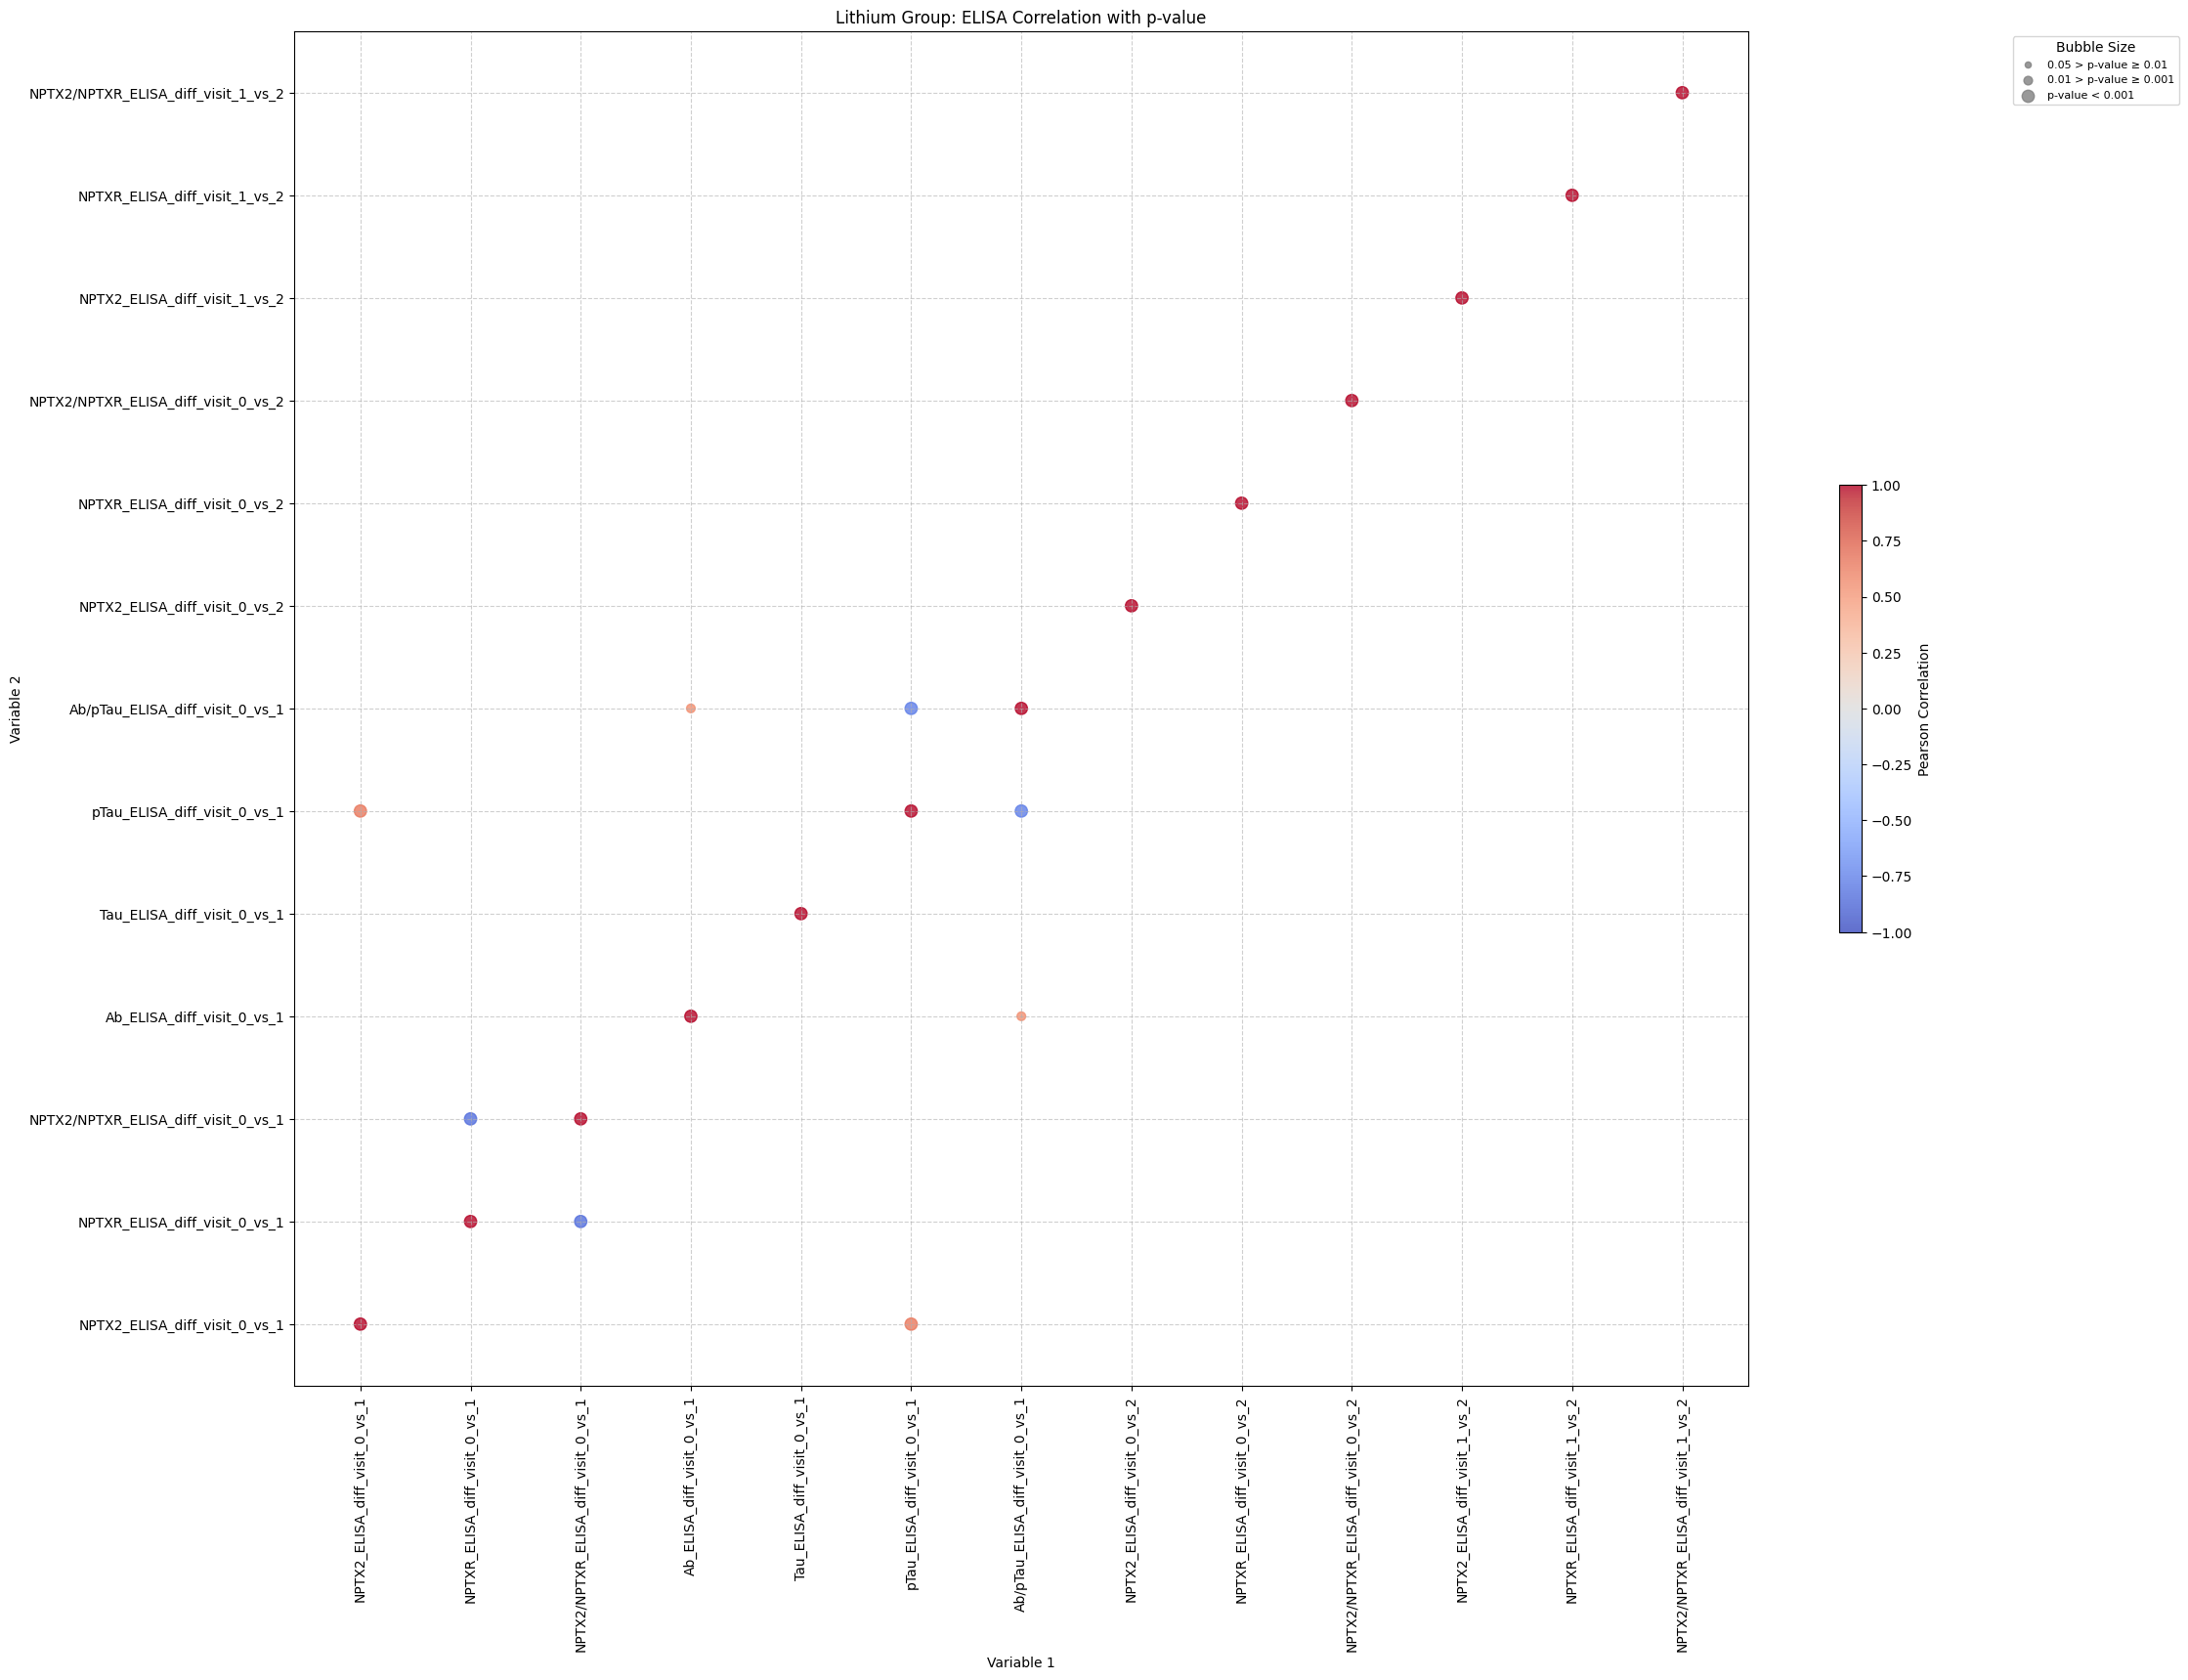

Correlation and p-value Table for Placebo Group: ELISA Correlation with p-value:
                             Variable 1                           Variable 2  \
0         NPTX2_ELISA_diff_visit_0_vs_1        NPTX2_ELISA_diff_visit_0_vs_1   
1         NPTXR_ELISA_diff_visit_0_vs_1        NPTXR_ELISA_diff_visit_0_vs_1   
2   NPTX2/NPTXR_ELISA_diff_visit_0_vs_1  NPTX2/NPTXR_ELISA_diff_visit_0_vs_1   
3            Ab_ELISA_diff_visit_0_vs_1           Ab_ELISA_diff_visit_0_vs_1   
4           Tau_ELISA_diff_visit_0_vs_1          Tau_ELISA_diff_visit_0_vs_1   
5          pTau_ELISA_diff_visit_0_vs_1         pTau_ELISA_diff_visit_0_vs_1   
6       Ab/pTau_ELISA_diff_visit_0_vs_1      Ab/pTau_ELISA_diff_visit_0_vs_1   
7         NPTX2_ELISA_diff_visit_0_vs_2        NPTX2_ELISA_diff_visit_0_vs_2   
8         NPTXR_ELISA_diff_visit_0_vs_2        NPTXR_ELISA_diff_visit_0_vs_2   
9   NPTX2/NPTXR_ELISA_diff_visit_0_vs_2  NPTX2/NPTXR_ELISA_diff_visit_0_vs_2   
10        NPTX2_ELISA_diff_visit_1_vs_2

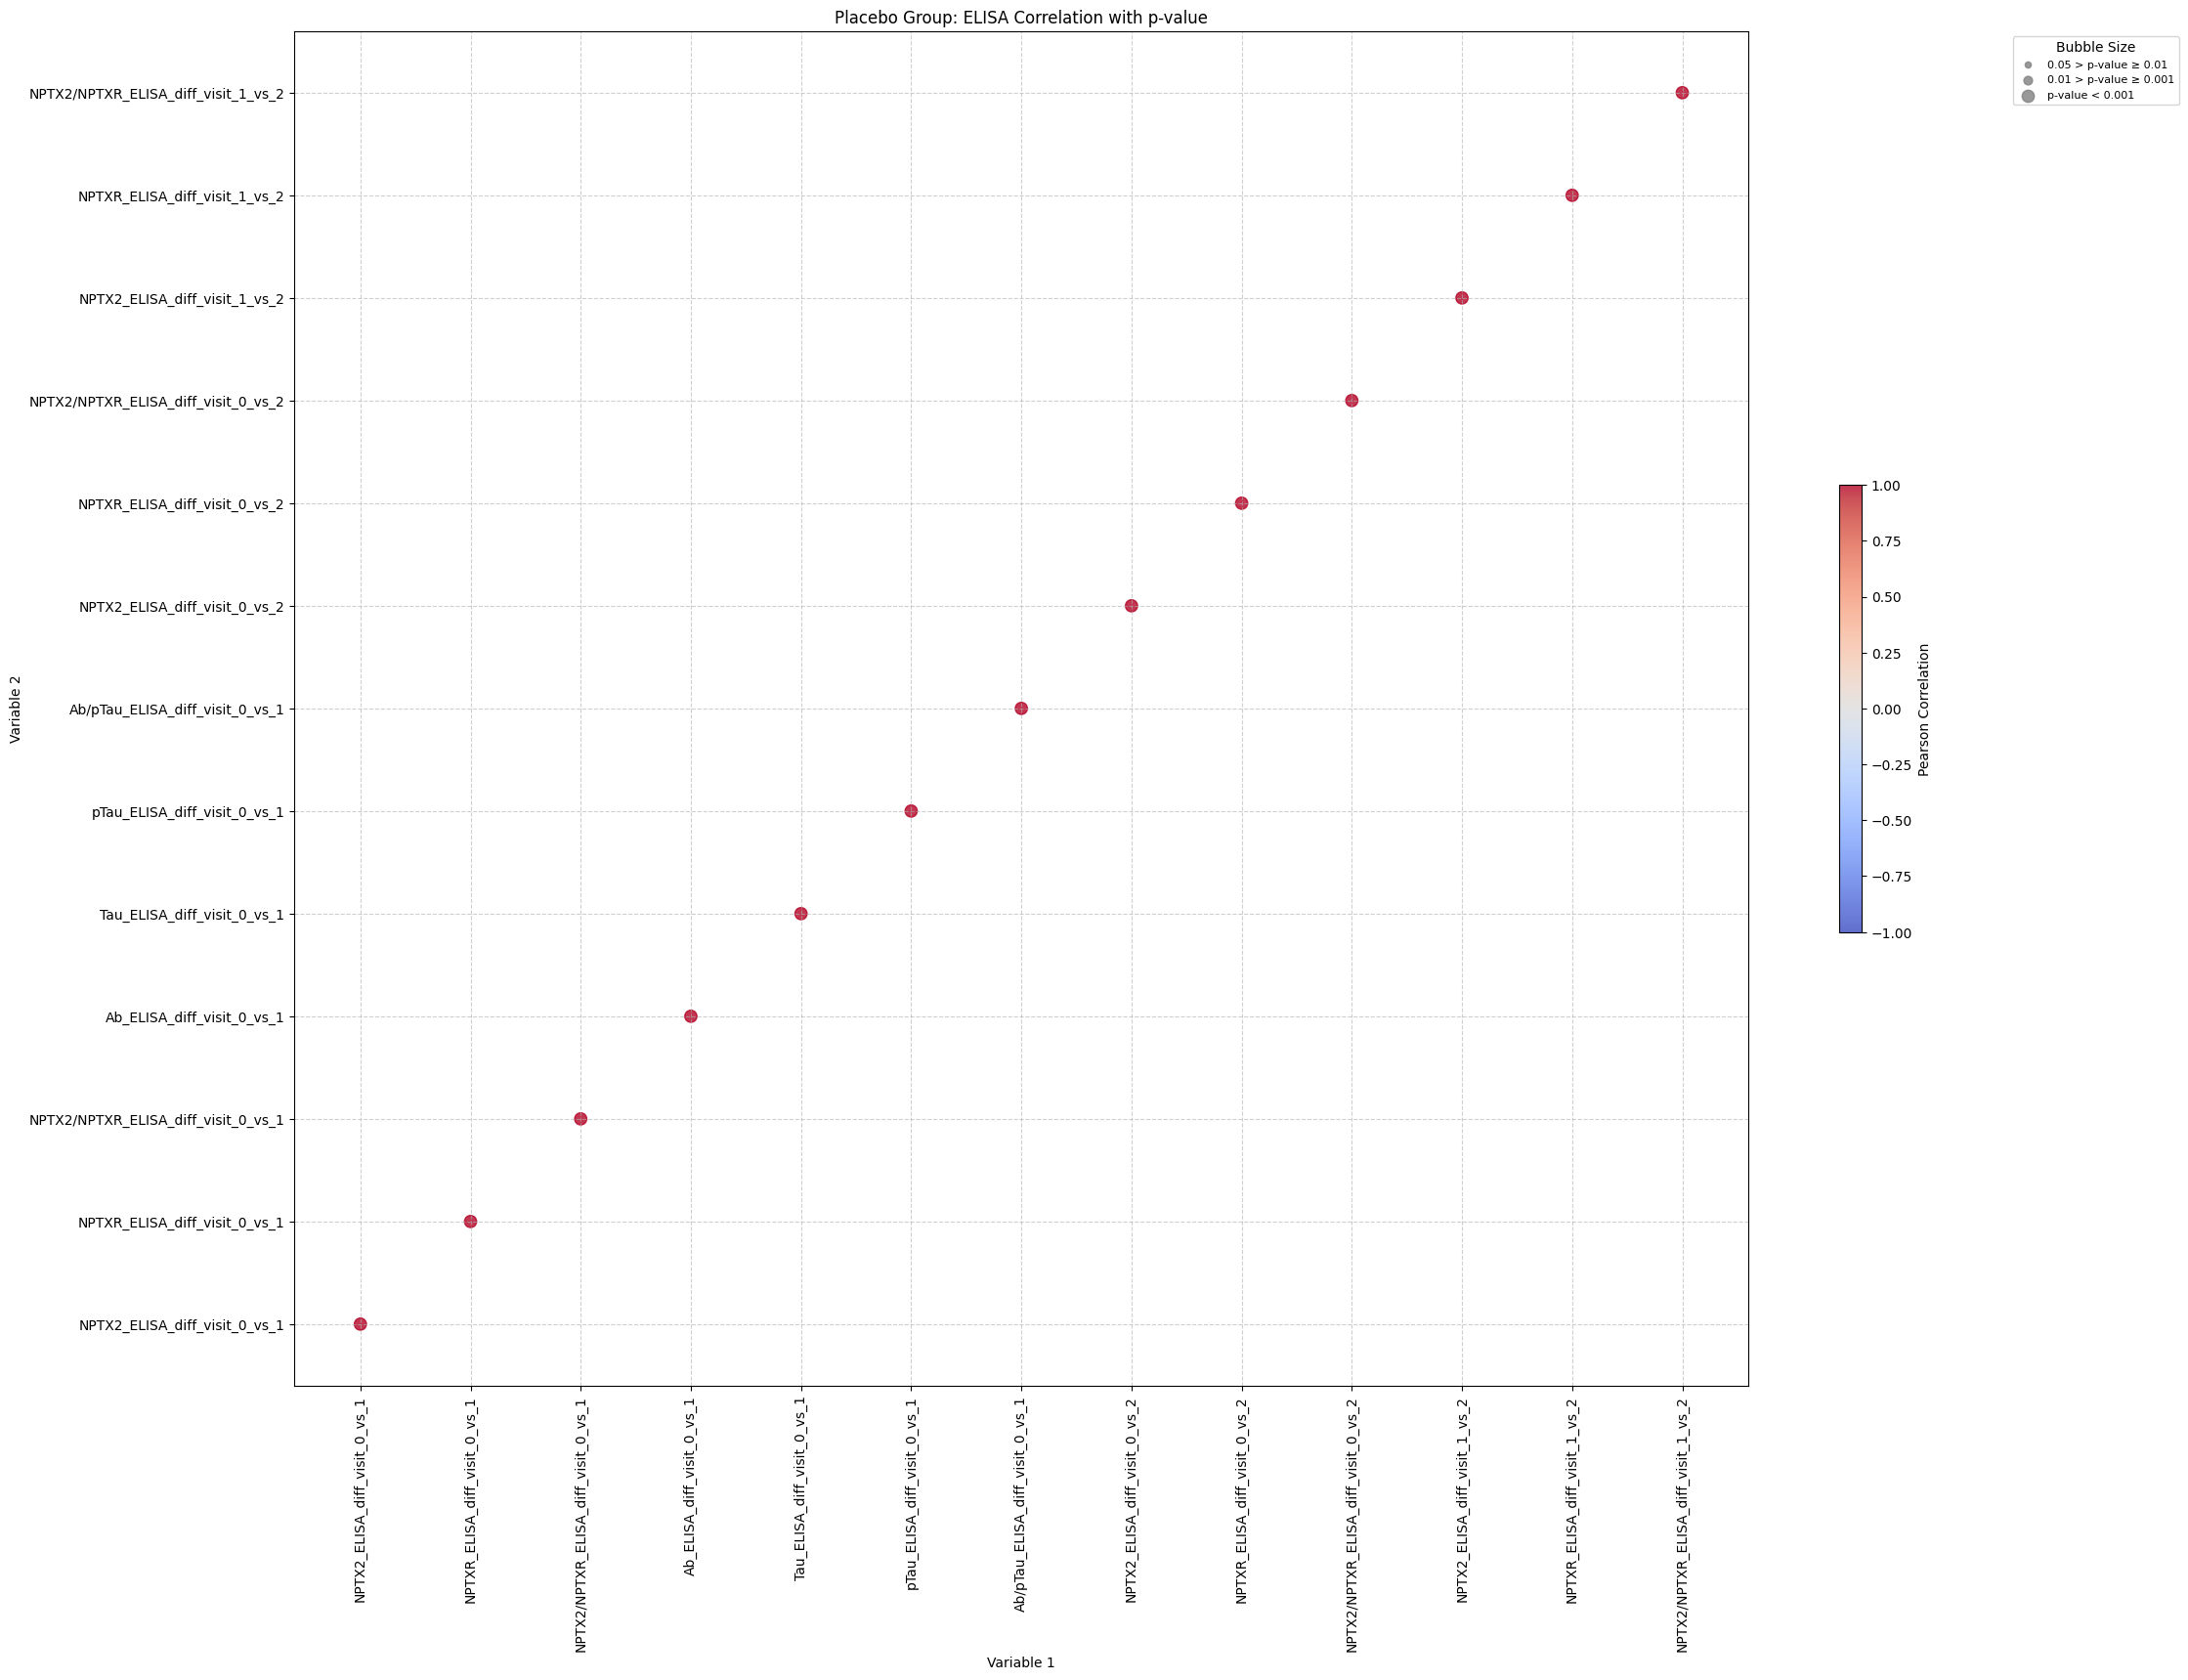

In [ ]:
# Lithium 그룹에서 ELISA 칼럼 간 상관 관계 계산
lithium_elisa_corr, lithium_elisa_pvalue = calculate_correlation_with_pvalue(lithium_elisa, lithium_elisa.columns)

# Placebo 그룹에서 ELISA 칼럼 간 상관 관계 계산
placebo_elisa_corr, placebo_elisa_pvalue = calculate_correlation_with_pvalue(placebo_elisa, placebo_elisa.columns)

# 시각화 (Bubble chart + Heatmap)
plot_bubble_correlation(lithium_elisa_corr, lithium_elisa_pvalue, "Lithium Group: ELISA Correlation with p-value")
plot_bubble_correlation(placebo_elisa_corr, placebo_elisa_pvalue, "Placebo Group: ELISA Correlation with p-value")


In [ ]:
# Lithium 그룹의 NULISA 칼럼들끼리 상관 관계 계산
lithium_nulisa_corr, lithium_nulisa_pvalue = calculate_correlation_with_pvalue(lithium_nulisa, lithium_nulisa.columns)

# Placebo 그룹의 NULISA 칼럼들끼리 상관 관계 계산
placebo_nulisa_corr, placebo_nulisa_pvalue = calculate_correlation_with_pvalue(placebo_nulisa, placebo_nulisa.columns)

# 시각화 (Bubble chart + Heatmap)
plot_bubble_correlation(lithium_nulisa_corr, lithium_nulisa_pvalue, "Lithium Group: NULISA Correlation with p-value")
plot_bubble_correlation(placebo_nulisa_corr, placebo_nulisa_pvalue, "Placebo Group: NULISA Correlation with p-value")

Output hidden; open in https://colab.research.google.com to view.